<a href="https://colab.research.google.com/github/AnanyaSinghal7/MLPMolecularScreening/blob/update/mlp_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 75.6 MB/s eta 0:00:00


In [ ]:
import os, random, warnings, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, regularizers, callbacks, Model, Input, backend as K
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import class_weight
from sklearn.metrics import (accuracy_score, f1_score, recall_score,
                             precision_score, matthews_corrcoef,
                             roc_curve, auc, roc_auc_score,
                             classification_report, confusion_matrix)
from concurrent.futures import ThreadPoolExecutor
import shap
from rdkit import Chem
from rdkit.Chem import Draw, AllChem
from rdkit.Chem.Draw import rdMolDraw2D
from PIL import Image
from io import BytesIO
warnings.filterwarnings('ignore')

#reproducibility and gpu
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(f"GPU config error: {e}")

try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    COLAB = True
except:
    COLAB = False

if COLAB:
    DESC_PATH = "/content/drive/MyDrive/descriptors-final.csv"
    FP_PATH   = "/content/drive/MyDrive/fingerprints-final.csv"
    SAVE_DIR  = "/content/drive/MyDrive/models_new/"
else:
    DESC_PATH = "descriptors-final.csv"
    FP_PATH   = "fingerprints-final.csv"
    SAVE_DIR  = "./models/"

os.makedirs(SAVE_DIR, exist_ok=True)

Mounted at /content/drive


In [ ]:
# ================================================================
# 1. DATA LOADING
# ================================================================
print("\n" + "="*60)
print("LOADING & MERGING DATA")
print("="*60)

desc_orig = pd.read_csv(DESC_PATH)
fp_orig   = pd.read_csv(FP_PATH)

print("Descriptor columns:", list(desc_orig.columns))
print("Fingerprint columns:", list(fp_orig.columns))

#common identifiers
possible_keys = ['Molecule ChEMBL ID', 'Smiles']
merge_key = None
for key in possible_keys:
    if key in desc_orig.columns and key in fp_orig.columns:
        merge_key = key
        break

if merge_key is None:
    print("\n WARNING: No common ID column found. Merging on index, assuming identical row order.")
    if len(desc_orig) != len(fp_orig):
        raise ValueError("Descriptor and fingerprint files have different numbers of rows. "
                         "Cannot merge without a common ID column.")
    df = desc_orig.copy()
    fp_copy = fp_orig.copy()
    fp_cols = {c: f"{c}_fp" for c in fp_orig.columns}
    fp_copy.rename(columns=fp_cols, inplace=True)
    df = pd.concat([df.reset_index(drop=True), fp_copy.reset_index(drop=True)], axis=1)
else:
    print(f"Merging on common column: '{merge_key}'")
    df = desc_orig.merge(fp_orig, on=merge_key, how='inner', suffixes=('', '_fp'))

non_desc_cols = ['Molecule ChEMBL ID', 'Smiles', 'Standard value in uM', 'Activity']
desc_feat_cols = [c for c in desc_orig.columns if c not in non_desc_cols]

if merge_key:
    fp_feat_cols = [c for c in fp_orig.columns if c != merge_key]
else:
    fp_feat_cols = [c for c in df.columns if c.endswith('_fp') and c[:-3] in fp_orig.columns]

df.dropna(subset=desc_feat_cols + fp_feat_cols, inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Merged dataset size: {len(df)}")

X_desc_raw = df[desc_feat_cols].values.astype(np.float64)
X_fp_raw   = df[fp_feat_cols].values.astype(np.float64)

X_desc_raw = np.where(np.isfinite(X_desc_raw), X_desc_raw, np.nan)
X_fp_raw   = np.where(np.isfinite(X_fp_raw), X_fp_raw, np.nan)
mask = ~np.isnan(X_desc_raw).any(axis=1) & ~np.isnan(X_fp_raw).any(axis=1)
if not mask.all():
    print(f"⚠ Dropping {(~mask).sum()} rows with NaN/Inf after merge")
    X_desc_raw = X_desc_raw[mask]
    X_fp_raw   = X_fp_raw[mask]
    df = df[mask].reset_index(drop=True)

y_raw = df['Activity'].values
if y_raw.dtype == object:
    le = LabelEncoder()
    y = le.fit_transform(y_raw)
else:
    y = y_raw.astype(int)

print(f"Final shape: X_desc={X_desc_raw.shape}, X_fp={X_fp_raw.shape}, y={y.shape}")
print(f"Class distribution: {dict(zip(*np.unique(y, return_counts=True)))}")


LOADING & MERGING DATA
Descriptor columns: ['Molecule ChEMBL ID', 'Smiles', 'Standard value in uM', 'Activity', 'MaxAbsEStateIndex', 'MaxEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'qed', 'SPS', 'MolWt', 'HeavyAtomMolWt', 'ExactMolWt', 'NumValenceElectrons', 'NumRadicalElectrons', 'MaxPartialCharge', 'MinPartialCharge', 'MaxAbsPartialCharge', 'MinAbsPartialCharge', 'FpDensityMorgan1', 'FpDensityMorgan2', 'FpDensityMorgan3', 'BCUT2D_MWHI', 'BCUT2D_MWLOW', 'BCUT2D_CHGHI', 'BCUT2D_CHGLO', 'BCUT2D_LOGPHI', 'BCUT2D_LOGPLOW', 'BCUT2D_MRHI', 'BCUT2D_MRLOW', 'AvgIpc', 'BalabanJ', 'BertzCT', 'Chi0', 'Chi0n', 'Chi0v', 'Chi1', 'Chi1n', 'Chi1v', 'Chi2n', 'Chi2v', 'Chi3n', 'Chi3v', 'Chi4n', 'Chi4v', 'HallKierAlpha', 'Ipc', 'Kappa1', 'Kappa2', 'Kappa3', 'LabuteASA', 'PEOE_VSA1', 'PEOE_VSA10', 'PEOE_VSA11', 'PEOE_VSA12', 'PEOE_VSA13', 'PEOE_VSA14', 'PEOE_VSA2', 'PEOE_VSA3', 'PEOE_VSA4', 'PEOE_VSA5', 'PEOE_VSA6', 'PEOE_VSA7', 'PEOE_VSA8', 'PEOE_VSA9', 'SMR_VSA1', 'SMR_VSA10', 'SMR_VSA2', 'SM

In [ ]:
# ================================================================
# 2. TRAIN/VAL/TEST SPLIT
# ================================================================
print("\n" + "="*60)
print("TRAIN/VAL/TEST SPLIT")
print("="*60)

X_desc_trainval, X_desc_test, X_fp_trainval, X_fp_test, y_trainval, y_test = \
    train_test_split(X_desc_raw, X_fp_raw, y,
                     test_size=0.20, random_state=SEED, stratify=y)

print(f"Train+Val: {len(y_trainval)} samples, Test: {len(y_test)} samples")
print(f"Test class distribution: {dict(zip(*np.unique(y_test, return_counts=True)))}")


TRAIN/VAL/TEST SPLIT
Train+Val: 52446 samples, Test: 13112 samples
Test class distribution: {np.int64(0): np.int64(2534), np.int64(1): np.int64(10578)}


In [ ]:
# ================================================================
# 3. HELPERS (IdentityScaler, CosineAnnealing, prep_fold, models)
# ================================================================

class IdentityScaler:
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X
    def fit_transform(self, X, y=None):
        return X

class CosineAnnealingScheduler(tf.keras.callbacks.Callback):
    def __init__(self, T_max, eta_min=1e-6):
        super().__init__()
        self.T_max = T_max
        self.eta_min = eta_min

    def on_train_begin(self, logs=None):
        self.initial_lr = tf.keras.backend.get_value(self.model.optimizer.learning_rate)

    def on_epoch_begin(self, epoch, logs=None):
        if not hasattr(self.model.optimizer, 'learning_rate'):
            return
        lr = self.eta_min + 0.5 * (self.initial_lr - self.eta_min) * \
             (1 + np.cos(np.pi * (epoch % self.T_max) / self.T_max))
        self.model.optimizer.learning_rate.assign(lr)

def prep_fold(train_idx, val_idx, X_desc, X_fp, y):
    Xd_tr, Xd_val = X_desc[train_idx], X_desc[val_idx]
    Xf_tr, Xf_val = X_fp[train_idx],   X_fp[val_idx]
    y_tr,  y_val  = y[train_idx],       y[val_idx]

    d_lo, d_hi = np.percentile(Xd_tr, 1, axis=0), np.percentile(Xd_tr, 99, axis=0)
    f_lo, f_hi = np.percentile(Xf_tr, 1, axis=0), np.percentile(Xf_tr, 99, axis=0)

    Xd_tr = np.clip(Xd_tr, d_lo, d_hi)
    Xd_val = np.clip(Xd_val, d_lo, d_hi)
    Xf_tr = np.clip(Xf_tr, f_lo, f_hi)
    Xf_val = np.clip(Xf_val, f_lo, f_hi)

    scaler_desc = StandardScaler()
    scaler_fp   = IdentityScaler()    # no scaling on binary fingerprints

    Xd_tr = scaler_desc.fit_transform(Xd_tr).astype(np.float32)
    Xd_val = scaler_desc.transform(Xd_val).astype(np.float32)
    Xf_tr = scaler_fp.transform(Xf_tr).astype(np.float32)
    Xf_val = scaler_fp.transform(Xf_val).astype(np.float32)

    cw_arr = class_weight.compute_class_weight('balanced',
                                                classes=np.unique(y_tr), y=y_tr)
    cw_dict = dict(enumerate(cw_arr))
    return (Xd_tr, Xd_val, Xf_tr, Xf_val, y_tr, y_val, cw_dict,
            scaler_desc, scaler_fp, (d_lo, d_hi), (f_lo, f_hi))

L2 = 1e-4
DROPOUT = 0.3

def build_desc_model(input_dim):
    inp = Input(shape=(input_dim,), name='desc_input')
    x = layers.Dense(512, kernel_regularizer=regularizers.l2(L2))(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(DROPOUT)(x)
    x = layers.Dense(256, kernel_regularizer=regularizers.l2(L2))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(DROPOUT)(x)
    x = layers.Dense(128, kernel_regularizer=regularizers.l2(L2))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.25)(x)
    x = layers.Dense(64, activation='relu', name='desc_penultimate')(x)
    out = layers.Dense(1, activation='sigmoid', name='output')(x)
    model = Model(inp, out, name='DescriptorModel')
    model.compile(optimizer=Adam(1e-3),
                  loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return model

def build_fp_model(input_dim):
    """Simplified MLP for binary fingerprints – no convolutions."""
    inp = Input(shape=(input_dim,), name='fp_input')
    x = layers.Dense(512, kernel_regularizer=regularizers.l2(L2))(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, kernel_regularizer=regularizers.l2(L2))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, kernel_regularizer=regularizers.l2(L2))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    out = layers.Dense(1, activation='sigmoid', name='output')(x)
    model = Model(inp, out, name='FingerprintModel')
    model.compile(optimizer=Adam(1e-3),
                  loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return model

def build_combined_model(desc_dim, fp_dim):
    desc_in = Input(shape=(desc_dim,), name='desc_input')
    fp_in   = Input(shape=(fp_dim,),   name='fp_input')

    d = layers.Dense(128, kernel_regularizer=regularizers.l2(L2))(desc_in)
    d = layers.BatchNormalization()(d)
    d = layers.Activation('relu')(d)
    d = layers.Dense(128, kernel_regularizer=regularizers.l2(L2))(d)
    d = layers.BatchNormalization()(d)
    d = layers.Activation('relu')(d)
    d_res = layers.add([d, layers.Dense(128)(desc_in)])
    d = layers.Activation('relu')(d_res)
    d = layers.Dropout(DROPOUT)(d)

    f = layers.Dense(256, kernel_regularizer=regularizers.l2(L2))(fp_in)
    f = layers.BatchNormalization()(f)
    f = layers.Activation('relu')(f)
    f = layers.Dropout(0.5)(f)
    f = layers.Dense(128, kernel_regularizer=regularizers.l2(L2))(f)
    f = layers.BatchNormalization()(f)
    f = layers.Activation('relu')(f)

    gate_input = layers.Concatenate()([d, f])
    gate = layers.Dense(64, activation='relu')(gate_input)
    gate = layers.Dense(2, activation='softmax')(gate)
    d_gated = layers.Multiply()([d, layers.Lambda(lambda g: g[:, 0:1])(gate)])
    f_gated = layers.Multiply()([f, layers.Lambda(lambda g: g[:, 1:2])(gate)])

    concat = layers.Concatenate()([d_gated, f_gated])
    x = layers.Dense(128, kernel_regularizer=regularizers.l2(L2))(concat)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(DROPOUT)(x)
    shortcut = layers.Dense(128)(concat)
    x = layers.add([x, shortcut])
    x = layers.Activation('relu')(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(1, activation='sigmoid', name='output')(x)
    model = Model([desc_in, fp_in], out, name='CombinedModel')
    model.compile(optimizer=Adam(1e-3),
                  loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return model

def get_callbacks(model_name, fold):
    cp = os.path.join(SAVE_DIR, f'{model_name}_fold{fold}_best.keras')
    return [
        callbacks.EarlyStopping(monitor='val_auc', patience=25,
                                mode='max', restore_best_weights=True, verbose=1),
        CosineAnnealingScheduler(T_max=50, eta_min=1e-6),
        callbacks.ModelCheckpoint(cp, monitor='val_auc',
                                  save_best_only=True, verbose=0)
    ]

def evaluate(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob > threshold).astype(int)
    return {
        'acc':  accuracy_score(y_true, y_pred),
        'f1':   f1_score(y_true, y_pred, zero_division=0),
        'rec':  recall_score(y_true, y_pred, zero_division=0),
        'prec': precision_score(y_true, y_pred, zero_division=0),
        'mcc':  matthews_corrcoef(y_true, y_pred),
        'auc':  roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else 0.0
    }

In [ ]:
# ================================================================
# 4. K‑FOLD CV
# ================================================================
K_FOLDS = 10
print("\n" + "="*60)
print(f"STARTING {K_FOLDS}-FOLD CROSS-VALIDATION")
print("="*60)

skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)
splits = list(skf.split(X_desc_trainval, y_trainval))

with ThreadPoolExecutor(max_workers=min(K_FOLDS, 4)) as pool:
    futures = [pool.submit(prep_fold, tr, va, X_desc_trainval, X_fp_trainval, y_trainval)
               for tr, va in splits]
    fold_data = [f.result() for f in futures]

metrics_list = ['acc', 'f1', 'rec', 'prec', 'mcc', 'auc']
results = {m: {met: [] for met in metrics_list} for m in ['desc', 'fp', 'comb']}
best_models = {'desc': [], 'fp': [], 'comb': []}
fold_aucs = {'desc': [], 'fp': [], 'comb': []}
histories = {'desc': [], 'fp': [], 'comb': []}
preprocessing_params = []

BATCH_SIZE, EPOCHS = 256, 100

for fold_num, fold_tuple in enumerate(fold_data, 1):
    (Xd_tr, Xd_val, Xf_tr, Xf_val, y_tr, y_val, cw,
     scaler_desc, scaler_fp, desc_clips, fp_clips) = fold_tuple
    preprocessing_params.append({
        'scaler_desc': scaler_desc,
        'scaler_fp': scaler_fp,
        'desc_clips': desc_clips,
        'fp_clips': fp_clips
    })
    print(f"\n{'='*60}\nFOLD {fold_num}/{K_FOLDS}\n{'='*60}")
    print(f"Train: {len(y_tr)} | Val: {len(y_val)}  Class weights: {cw}")

    #descriptor
    tf.keras.backend.clear_session()
    m_desc = build_desc_model(Xd_tr.shape[1])
    hist_desc = m_desc.fit(Xd_tr, y_tr, validation_data=(Xd_val, y_val),
                           batch_size=BATCH_SIZE, epochs=EPOCHS, class_weight=cw,
                           callbacks=get_callbacks('desc', fold_num), verbose=0)
    prob_desc = m_desc.predict(Xd_val, verbose=0).ravel()
    scores = evaluate(y_val, prob_desc)
    for k, v in scores.items(): results['desc'][k].append(v)
    fold_aucs['desc'].append(scores['auc'])
    best_models['desc'].append(m_desc)
    histories['desc'].append(hist_desc.history)
    print(f"  DESC: AUC={scores['auc']:.4f} MCC={scores['mcc']:.4f} F1={scores['f1']:.4f}")

    #fingerprint
    tf.keras.backend.clear_session()
    m_fp = build_fp_model(Xf_tr.shape[1])
    hist_fp = m_fp.fit(Xf_tr, y_tr, validation_data=(Xf_val, y_val),
                       batch_size=BATCH_SIZE, epochs=EPOCHS, class_weight=cw,
                       callbacks=get_callbacks('fp', fold_num), verbose=0)
    prob_fp = m_fp.predict(Xf_val, verbose=0).ravel()
    scores = evaluate(y_val, prob_fp)
    for k, v in scores.items(): results['fp'][k].append(v)
    fold_aucs['fp'].append(scores['auc'])
    best_models['fp'].append(m_fp)
    histories['fp'].append(hist_fp.history)
    print(f"  FP:   AUC={scores['auc']:.4f} MCC={scores['mcc']:.4f} F1={scores['f1']:.4f}")

    #combined
    tf.keras.backend.clear_session()
    m_comb = build_combined_model(Xd_tr.shape[1], Xf_tr.shape[1])
    hist_comb = m_comb.fit([Xd_tr, Xf_tr], y_tr,
                           validation_data=([Xd_val, Xf_val], y_val),
                           batch_size=BATCH_SIZE, epochs=EPOCHS, class_weight=cw,
                           callbacks=get_callbacks('comb', fold_num), verbose=0)
    prob_comb = m_comb.predict([Xd_val, Xf_val], verbose=0).ravel()
    scores = evaluate(y_val, prob_comb)
    for k, v in scores.items(): results['comb'][k].append(v)
    fold_aucs['comb'].append(scores['auc'])
    best_models['comb'].append(m_comb)
    histories['comb'].append(hist_comb.history)
    print(f"  COMB: AUC={scores['auc']:.4f} MCC={scores['mcc']:.4f} F1={scores['f1']:.4f}")

print("\n" + "="*60)
print("CROSS-VALIDATION RESULTS (Mean ± Std)")
print("="*60)
for model in ['desc', 'fp', 'comb']:
    print(f"\n{model.upper()}:")
    for metric in metrics_list:
        vals = np.array(results[model][metric])
        print(f"  {metric:4s}: {vals.mean():.4f} ± {vals.std():.4f}")


STARTING 10-FOLD CROSS-VALIDATION

FOLD 1/10
Train: 47201 | Val: 5245  Class weights: {0: np.float64(2.5866396317404647), 1: np.float64(0.6198098589699819)}
Epoch 70: early stopping
Restoring model weights from the end of the best epoch: 45.
  DESC: AUC=0.9216 MCC=0.6025 F1=0.8977
Epoch 48: early stopping
Restoring model weights from the end of the best epoch: 23.
  FP:   AUC=0.9242 MCC=0.6027 F1=0.8948
Epoch 47: early stopping
Restoring model weights from the end of the best epoch: 22.
  COMB: AUC=0.9243 MCC=0.6011 F1=0.8973

FOLD 2/10
Train: 47201 | Val: 5245  Class weights: {0: np.float64(2.5866396317404647), 1: np.float64(0.6198098589699819)}
Epoch 72: early stopping
Restoring model weights from the end of the best epoch: 47.
  DESC: AUC=0.9100 MCC=0.5649 F1=0.8839
Epoch 43: early stopping
Restoring model weights from the end of the best epoch: 18.
  FP:   AUC=0.9195 MCC=0.5896 F1=0.8900
Epoch 52: early stopping
Restoring model weights from the end of the best epoch: 27.
  COMB: A

In [ ]:
# ================================================================
# 5. TEST SET EVALUATION (weighted ensemble)
# ================================================================
def ensemble_predict(models, X_desc, X_fp, params, model_type, weights=None):
    preds = []
    for i, (m, p) in enumerate(zip(models, params)):
        d_lo, d_hi = p['desc_clips']
        f_lo, f_hi = p['fp_clips']
        if model_type in ['desc','comb']:
            Xd = np.clip(X_desc, d_lo, d_hi)
            Xd = p['scaler_desc'].transform(Xd).astype(np.float32)
        if model_type in ['fp','comb']:
            Xf = np.clip(X_fp, f_lo, f_hi)
            Xf = p['scaler_fp'].transform(Xf).astype(np.float32)

        if model_type == 'desc':
            pred = m.predict(Xd, verbose=0).ravel()
        elif model_type == 'fp':
            pred = m.predict(Xf, verbose=0).ravel()
        else:
            pred = m.predict([Xd, Xf], verbose=0).ravel()
        preds.append(pred)
    preds = np.stack(preds, axis=0)
    if weights is not None:
        weights = np.array(weights)
        weights /= weights.sum()
        return np.average(preds, axis=0, weights=weights)
    return np.mean(preds, axis=0)

print("\n" + "="*60)
print("TEST SET EVALUATION (WEIGHTED ENSEMBLE)")
print("="*60)

test_results = {}
test_probs = {}
test_preds = {}
for mtype in ['desc', 'fp', 'comb']:
    weights = np.maximum(fold_aucs[mtype], 0.5)
    prob = ensemble_predict(best_models[mtype],
                            X_desc_test, X_fp_test,
                            preprocessing_params, mtype,
                            weights=weights)
    pred = (prob > 0.5).astype(int)
    test_probs[mtype] = prob
    test_preds[mtype] = pred
    metrics = evaluate(y_test, prob)
    test_results[mtype] = metrics
    print(f"\n{mtype.upper()}:")
    for k, v in metrics.items():
        print(f"  {k:4s}: {v:.4f}")

test_df = pd.DataFrame([{**{'Model': k.upper()}, **v} for k,v in test_results.items()])
test_df.to_csv(os.path.join(SAVE_DIR, 'test_results.csv'), index=False)


TEST SET EVALUATION (WEIGHTED ENSEMBLE)

DESC:
  acc : 0.8463
  f1  : 0.8990
  rec : 0.8479
  prec: 0.9567
  mcc : 0.6015
  auc : 0.9248

FP:
  acc : 0.8510
  f1  : 0.9022
  rec : 0.8517
  prec: 0.9590
  mcc : 0.6130
  auc : 0.9327

COMB:
  acc : 0.8533
  f1  : 0.9038
  rec : 0.8544
  prec: 0.9592
  mcc : 0.6172
  auc : 0.9342



GENERATING PLOTS


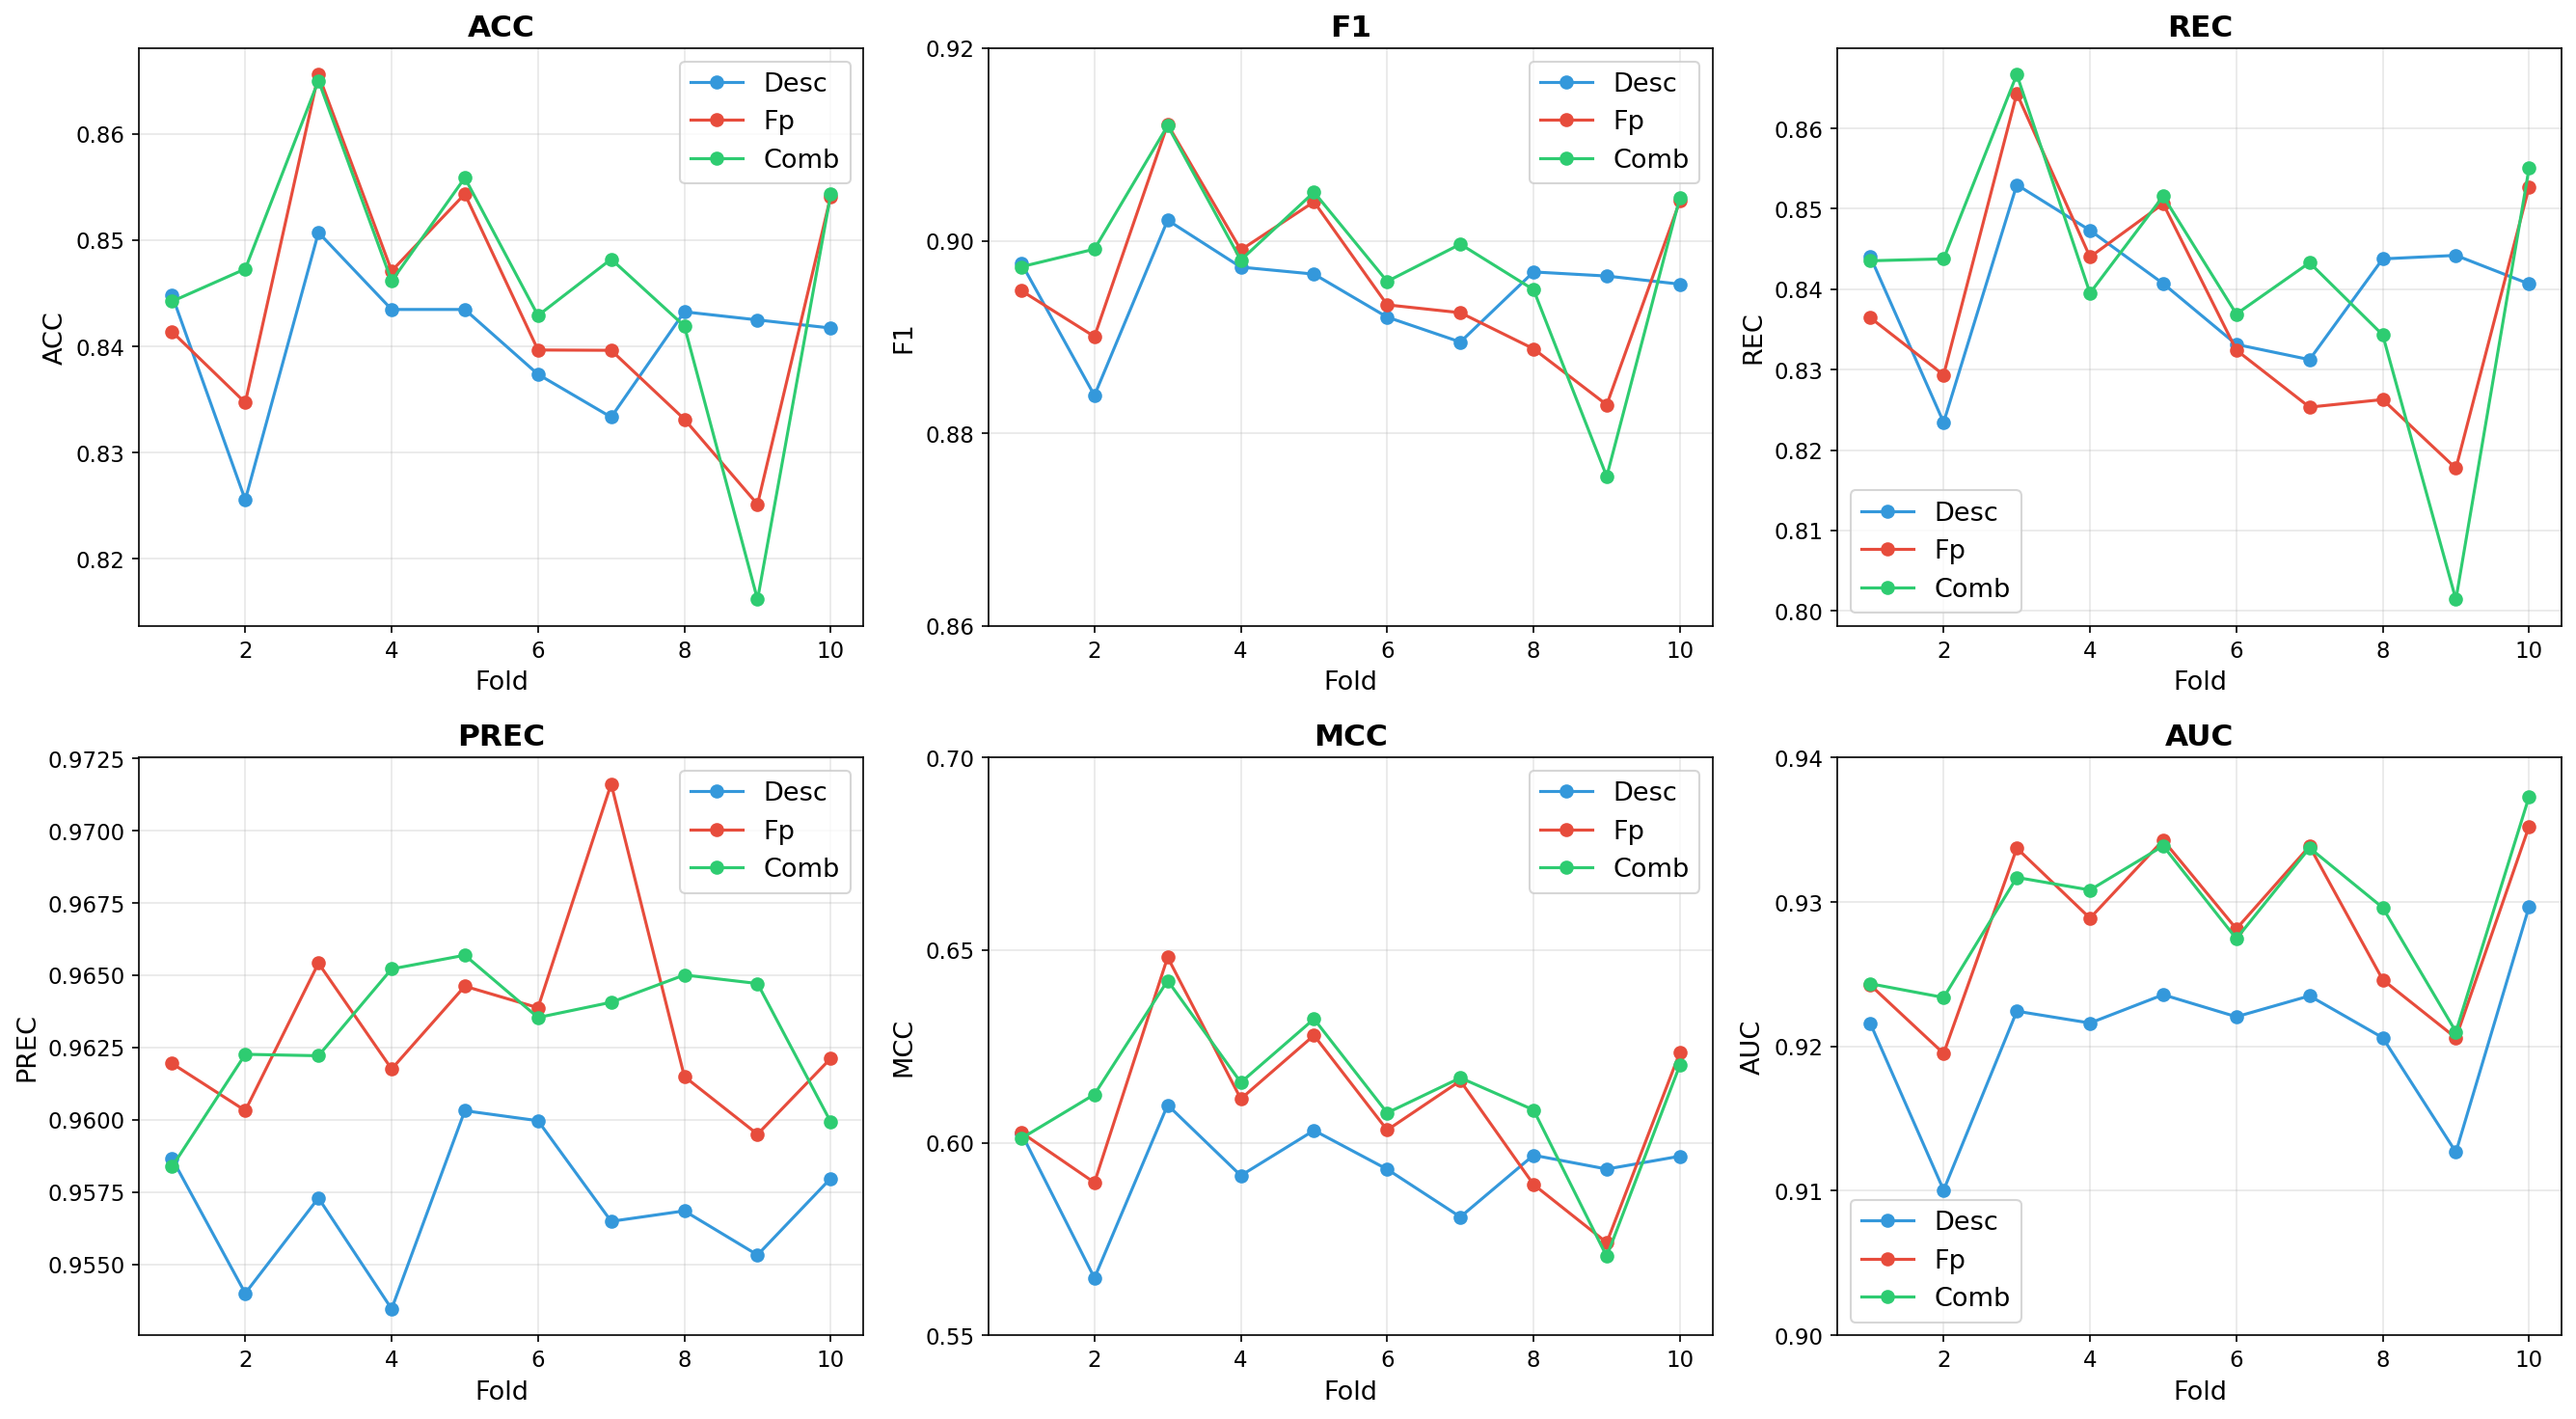

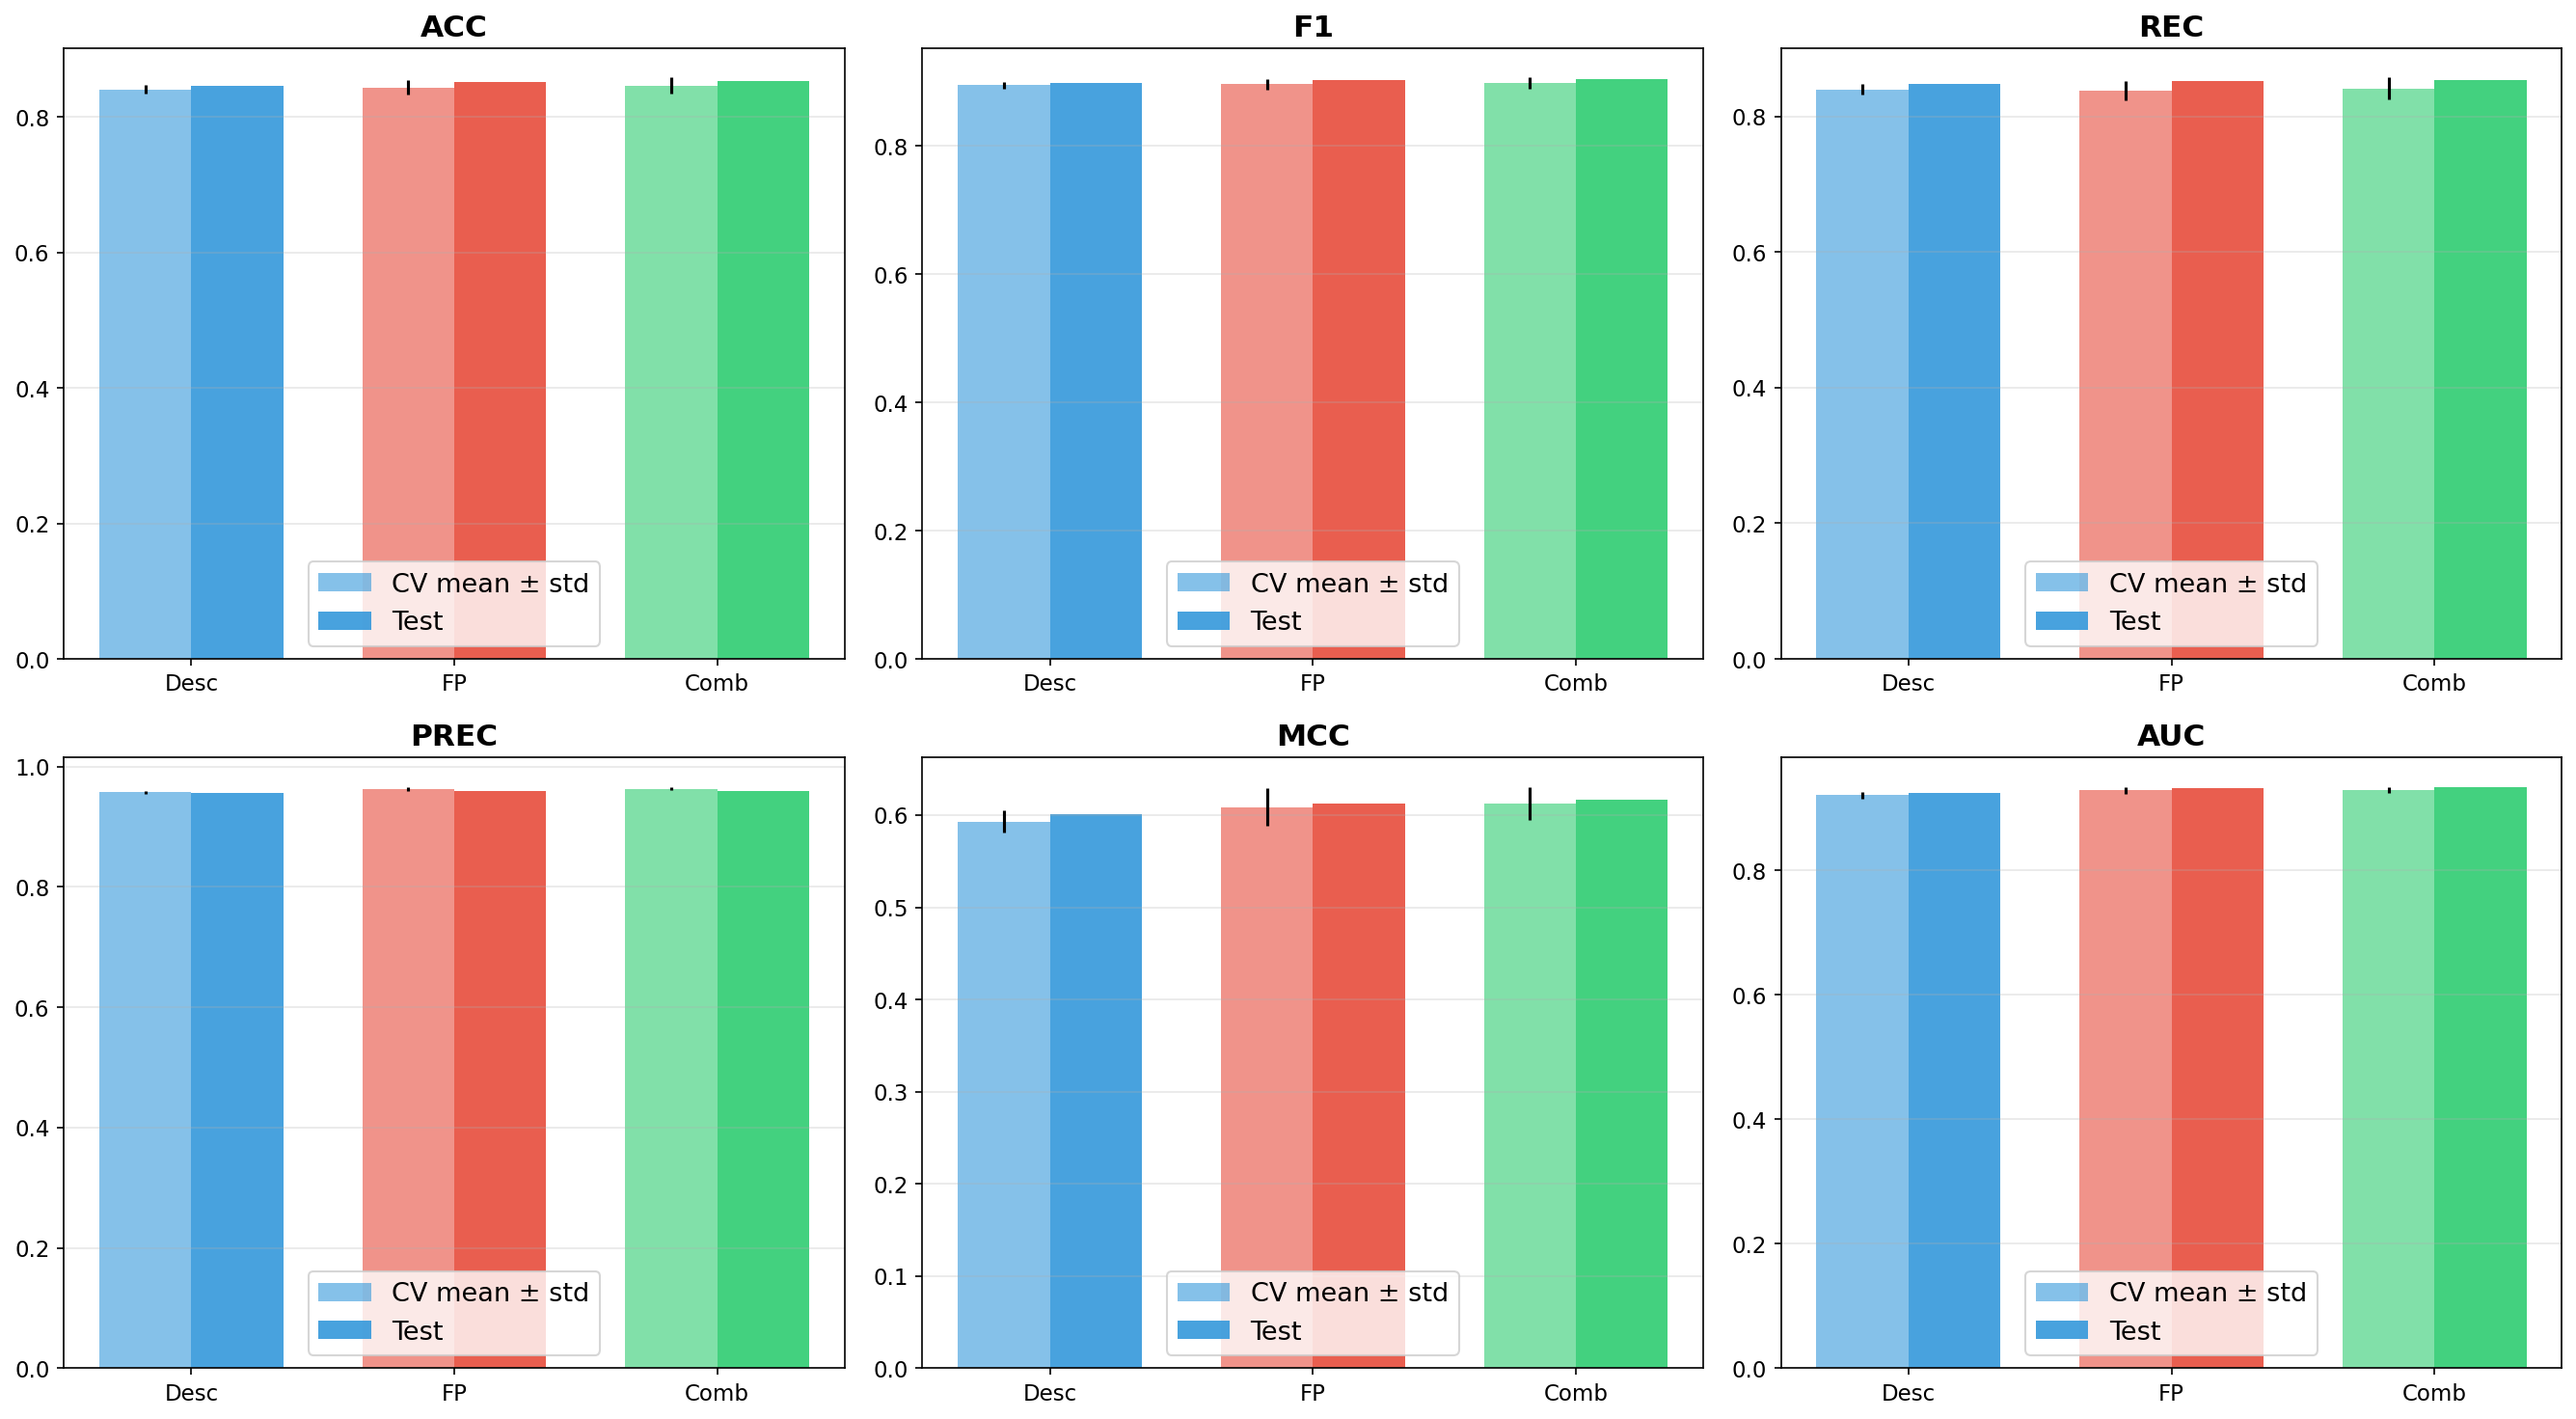

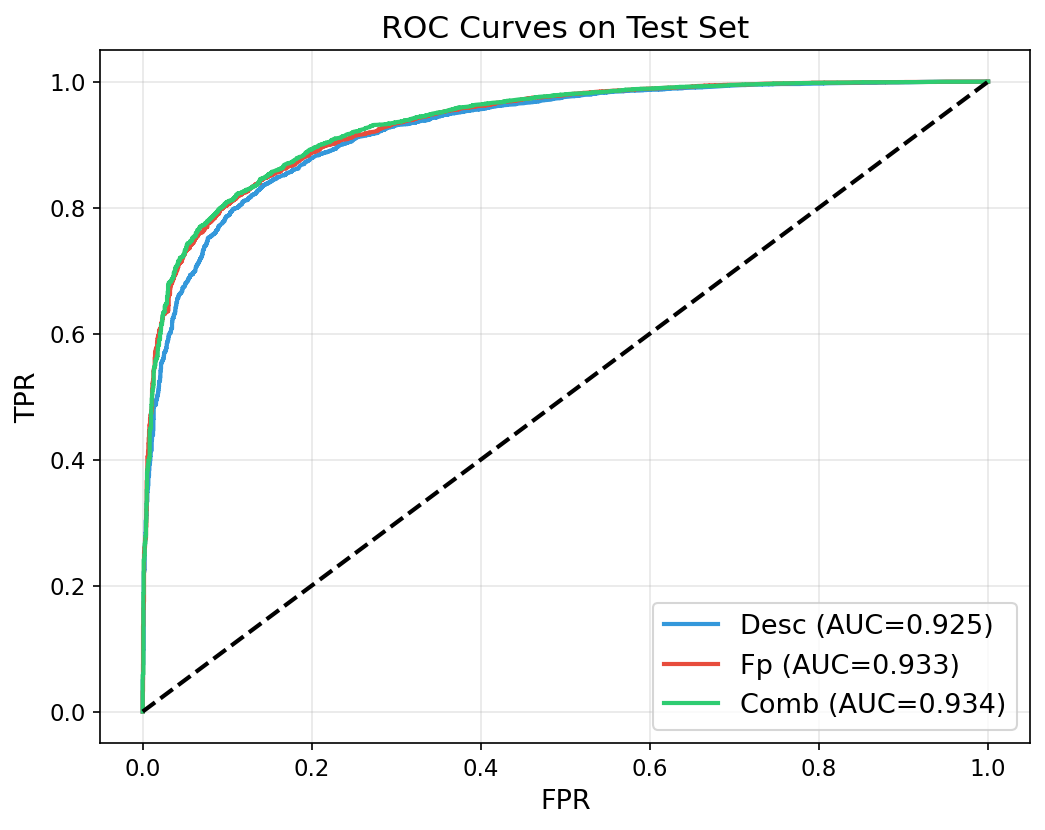

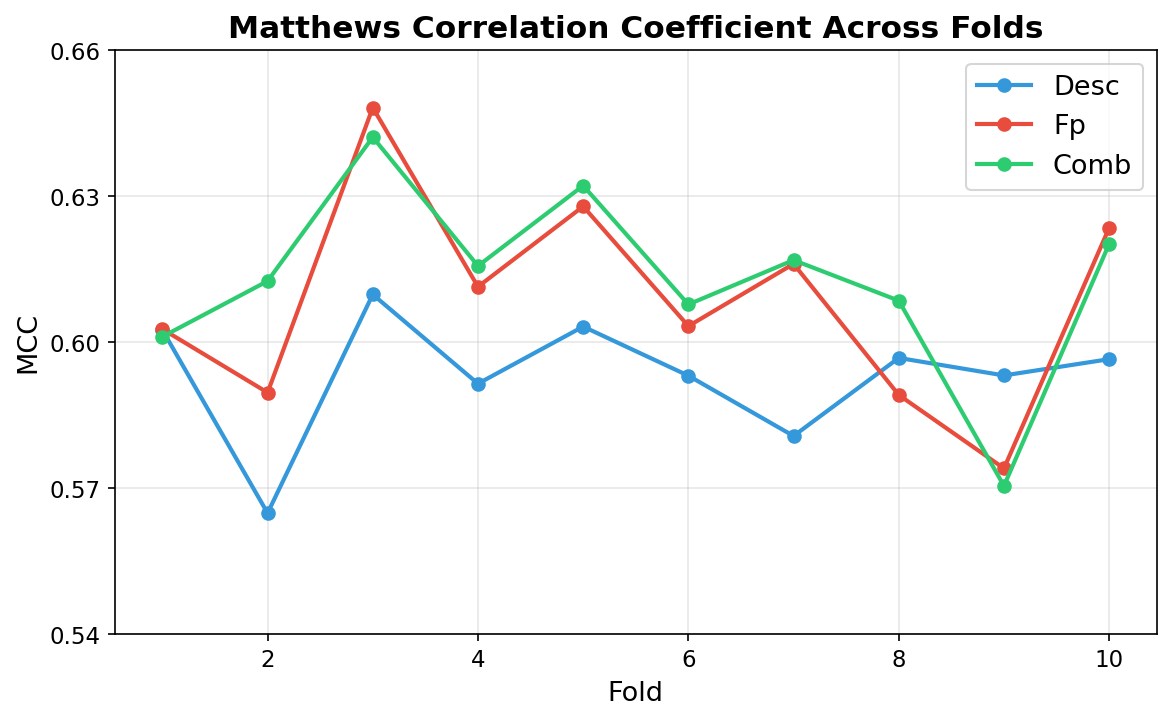

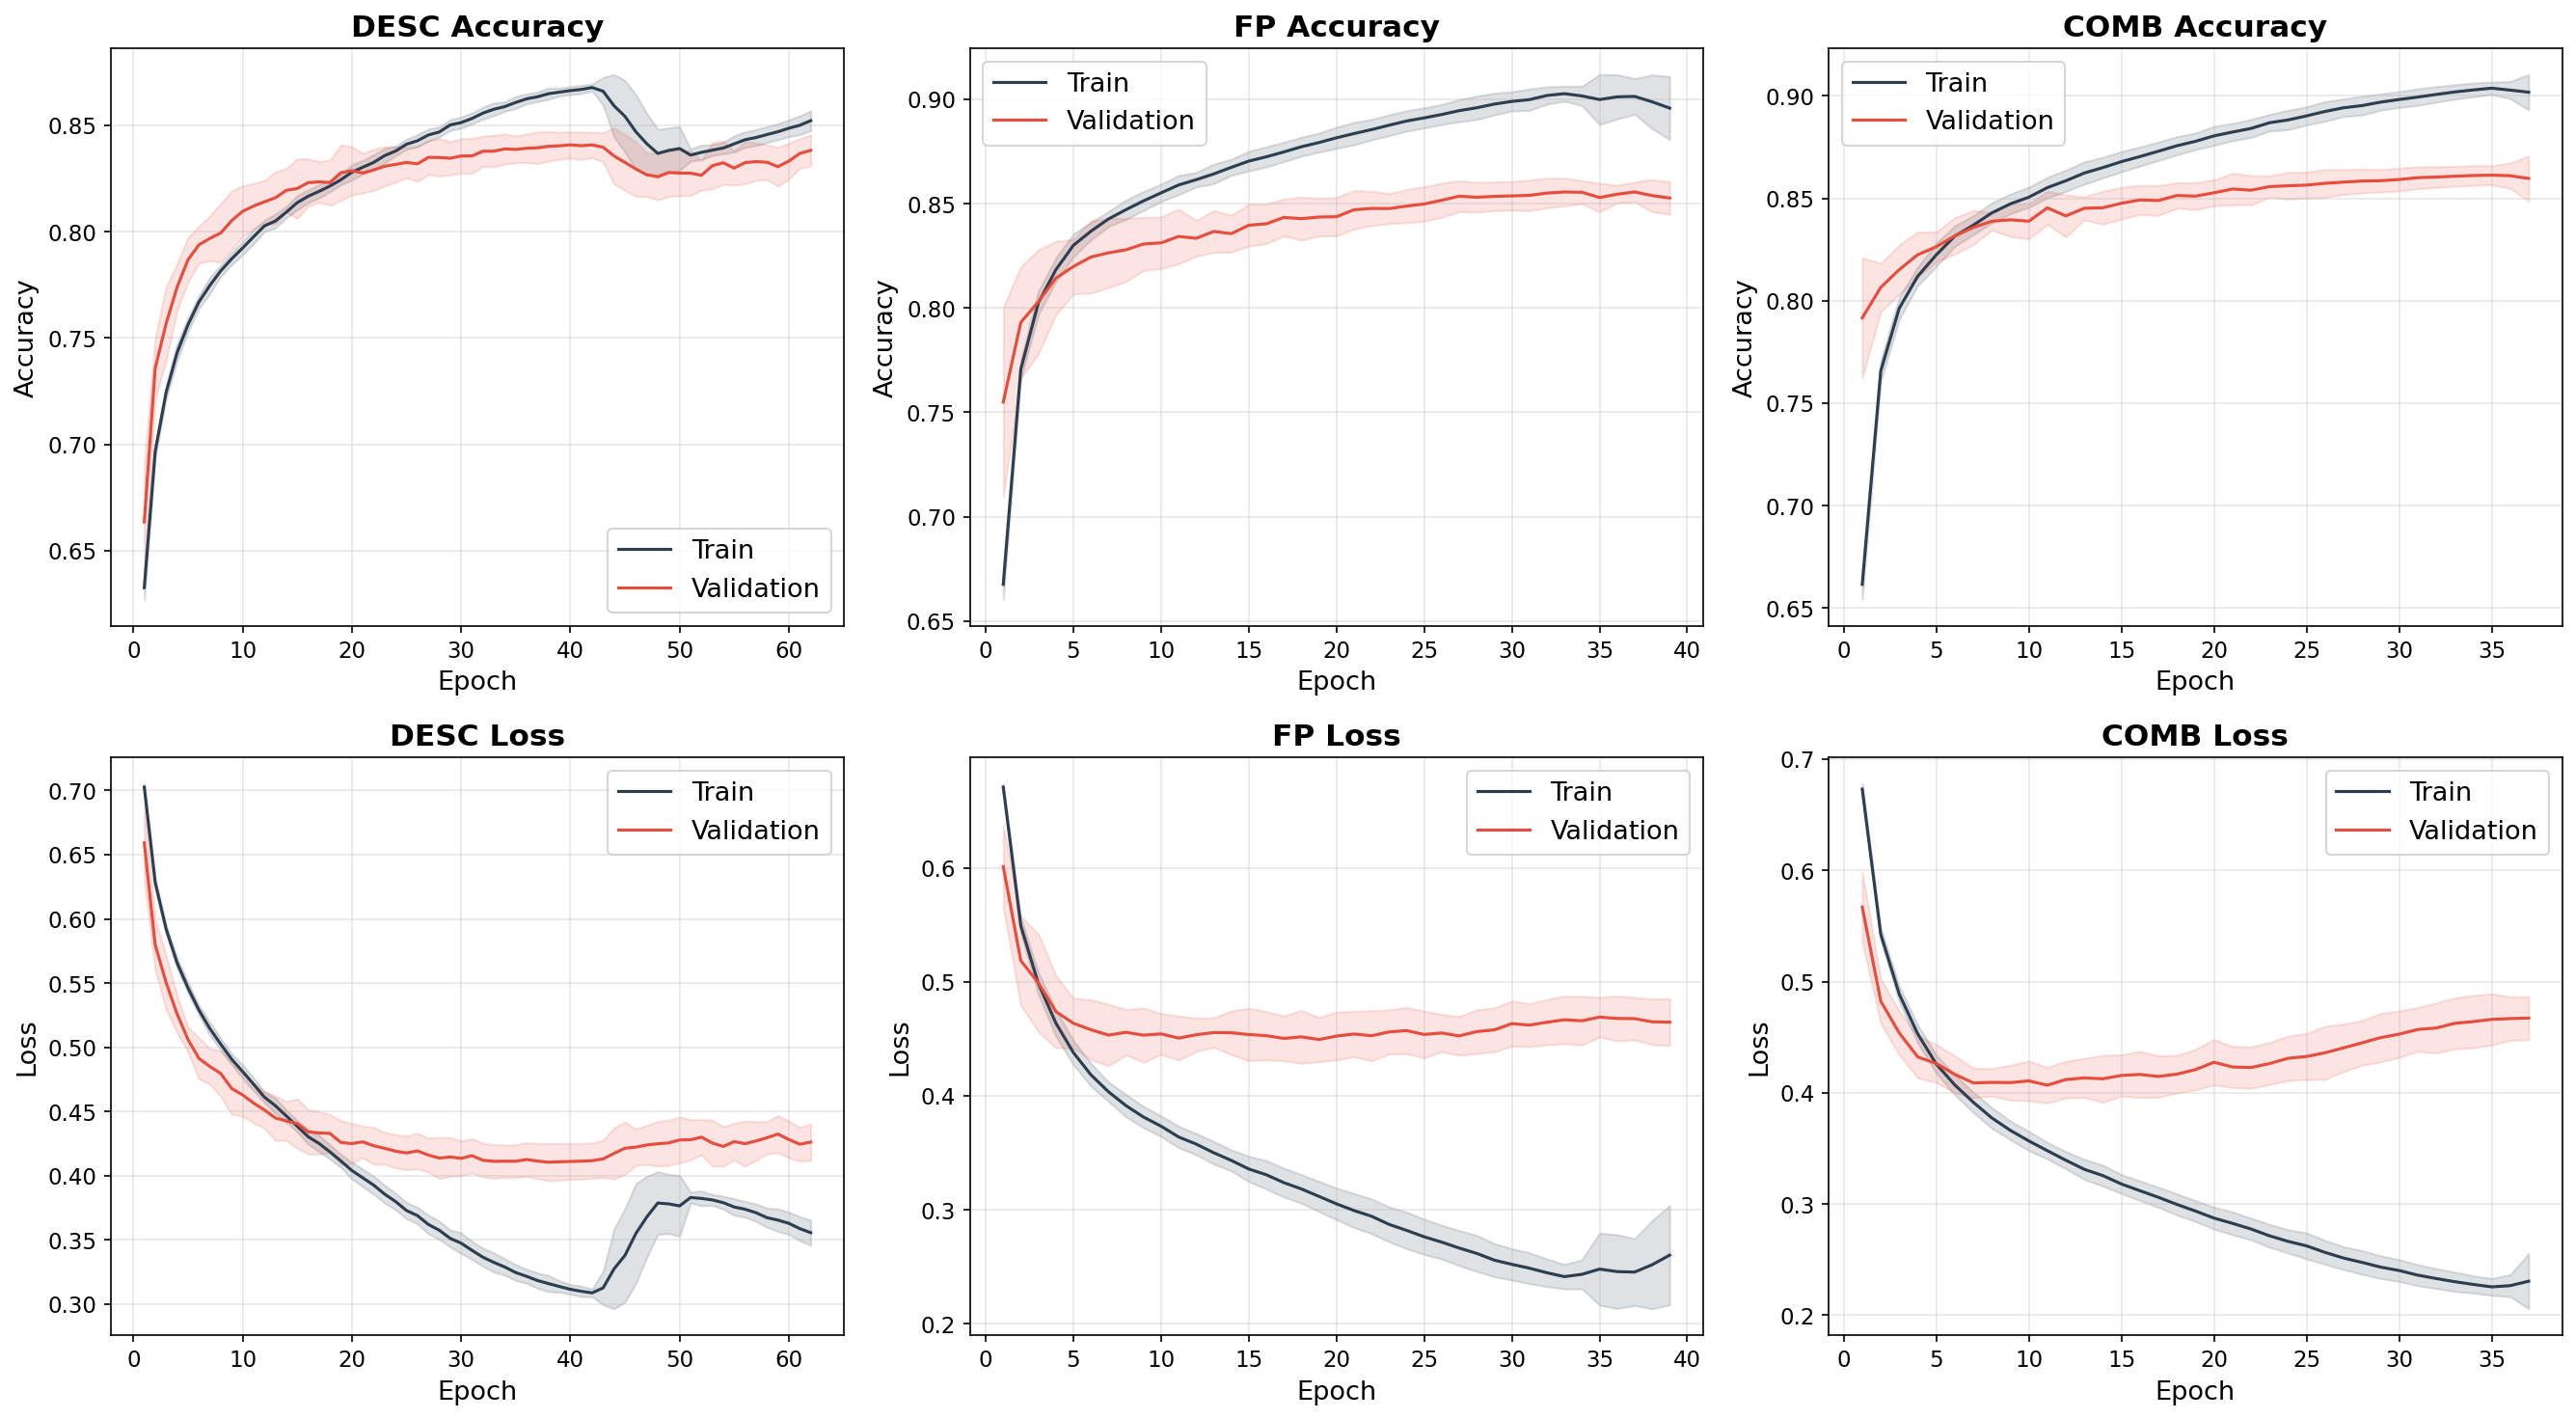

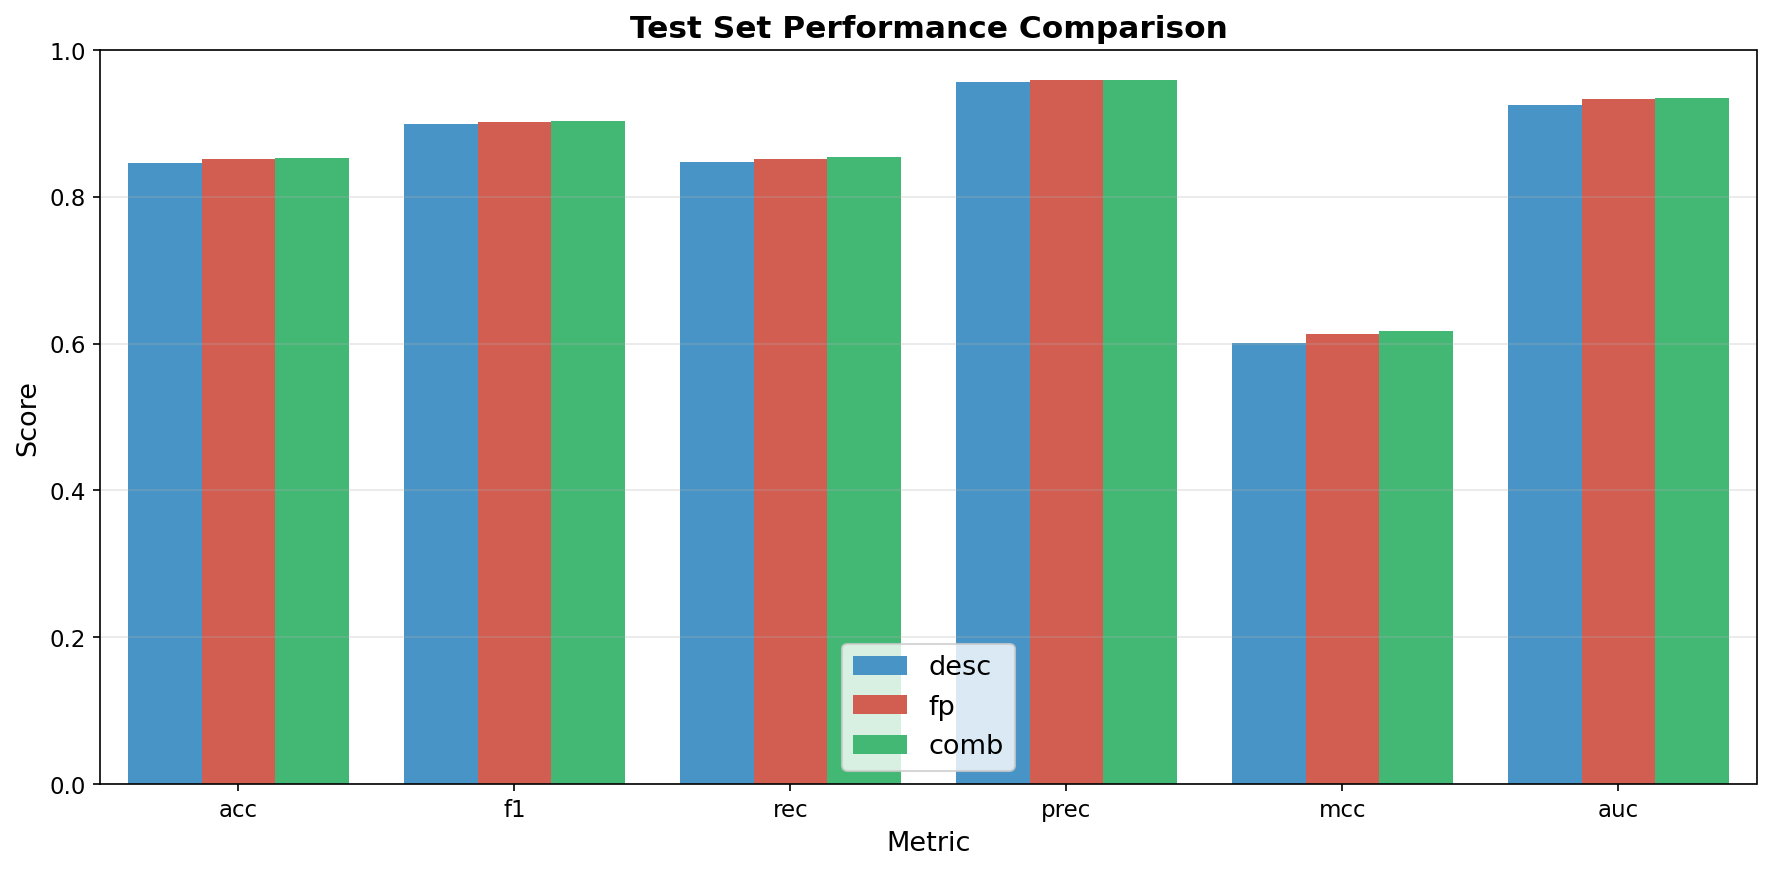

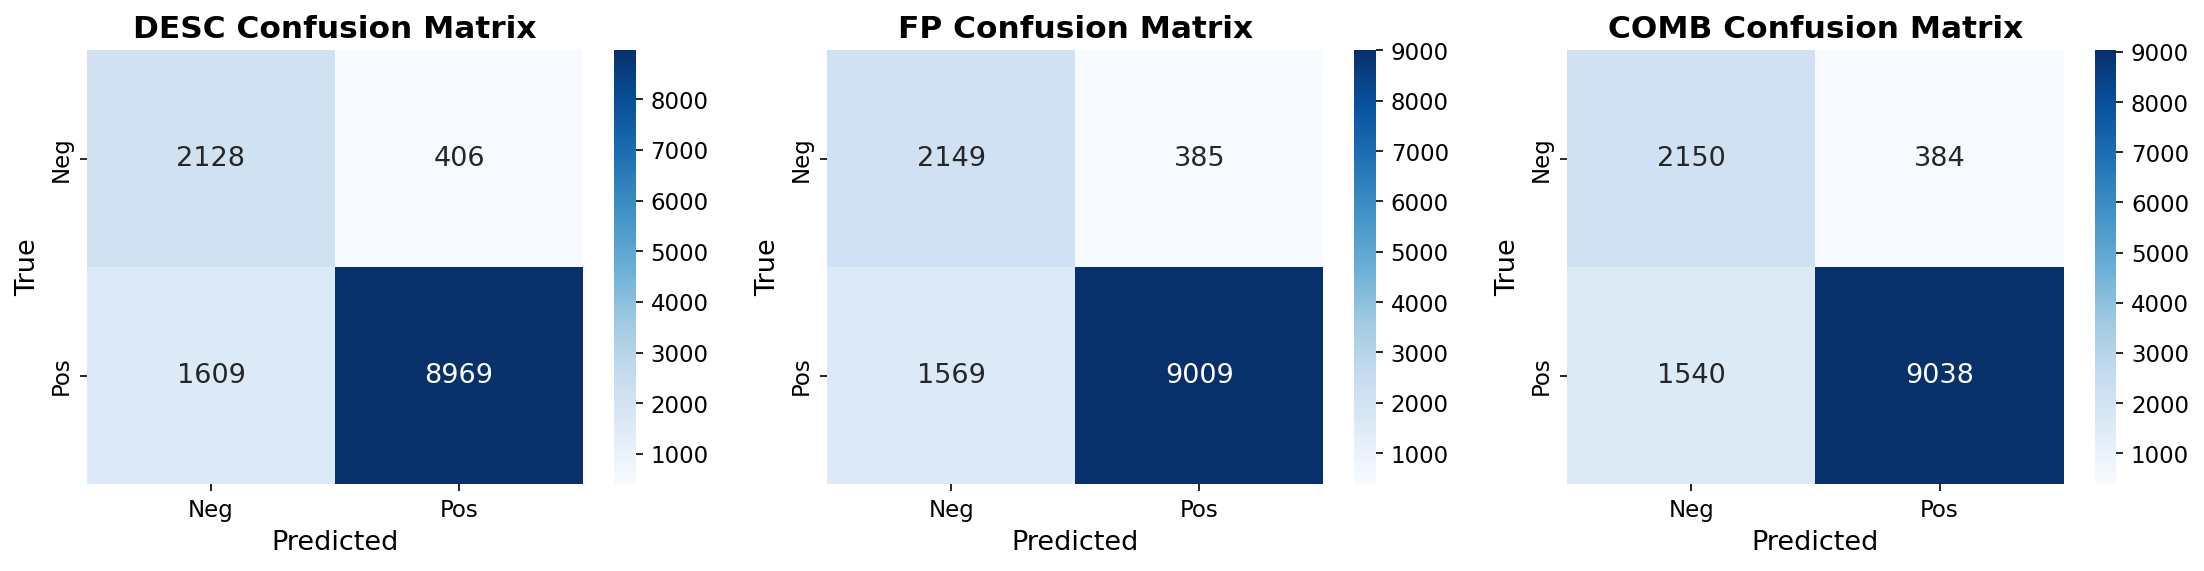

In [ ]:
# ================================================================
# 6. PLOTS (all extended graphs)
# ================================================================
def plot_cv_metrics():
    fig, axes = plt.subplots(2,3, figsize=(18,10))
    axes = axes.ravel()
    folds = range(1, K_FOLDS+1)
    colors = {'desc':'#3498db', 'fp':'#e74c3c', 'comb':'#2ecc71'}
    for idx, metric in enumerate(metrics_list):
        ax = axes[idx]
        for model in ['desc','fp','comb']:
            ax.plot(folds, results[model][metric], marker='o',
                    color=colors[model], label=model.capitalize())
        ax.set_title(metric.upper(), fontweight='bold')
        ax.set_xlabel('Fold')
        ax.set_ylabel(metric.upper())
        ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'cv_metrics.png'), dpi=300)
    plt.show()

def plot_cv_vs_test():
    fig, axes = plt.subplots(2,3, figsize=(18,10))
    axes = axes.ravel()
    x_pos = np.arange(3)
    colors = {'desc':'#3498db','fp':'#e74c3c','comb':'#2ecc71'}
    for idx, metric in enumerate(metrics_list):
        ax = axes[idx]
        cv_means = [np.mean(results[m][metric]) for m in ['desc','fp','comb']]
        cv_stds  = [np.std(results[m][metric]) for m in ['desc','fp','comb']]
        test_vals= [test_results[m][metric] for m in ['desc','fp','comb']]
        w = 0.35
        ax.bar(x_pos - w/2, cv_means, w, yerr=cv_stds, label='CV mean ± std',
               color=[colors[m] for m in ['desc','fp','comb']], alpha=0.6)
        ax.bar(x_pos + w/2, test_vals, w, label='Test',
               color=[colors[m] for m in ['desc','fp','comb']], alpha=0.9)
        ax.set_title(metric.upper(), fontweight='bold')
        ax.set_xticks(x_pos)
        ax.set_xticklabels(['Desc','FP','Comb'])
        ax.legend(); ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'cv_vs_test.png'), dpi=300)
    plt.show()

def plot_test_roc():
    plt.figure(figsize=(8,6))
    colors = {'desc':'#3498db','fp':'#e74c3c','comb':'#2ecc71'}
    for mtype in ['desc','fp','comb']:
        fpr, tpr, _ = roc_curve(y_test, test_probs[mtype])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=colors[mtype], lw=2,
                 label=f'{mtype.capitalize()} (AUC={roc_auc:.3f})')
    plt.plot([0,1],[0,1],'k--', lw=2)
    plt.xlabel('FPR'); plt.ylabel('TPR')
    plt.title('ROC Curves on Test Set')
    plt.legend(); plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(SAVE_DIR, 'test_roc.png'), dpi=300)
    plt.show()

def plot_per_fold_mcc():
    plt.figure(figsize=(8,5))
    folds = range(1, K_FOLDS+1)
    colors = {'desc':'#3498db', 'fp':'#e74c3c', 'comb':'#2ecc71'}
    for model in ['desc','fp','comb']:
        plt.plot(folds, results[model]['mcc'], marker='o', linewidth=2,
                 color=colors[model], label=model.capitalize())
    plt.title('Matthews Correlation Coefficient Across Folds', fontweight='bold')
    plt.xlabel('Fold'); plt.ylabel('MCC')
    plt.legend(); plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'cv_mcc.png'), dpi=300)
    plt.show()

def plot_learning_curves():
    fig, axes = plt.subplots(2,3, figsize=(18,10))
    axes = axes.ravel()
    models = ['desc', 'fp', 'comb']
    for i, model in enumerate(models):
        hist_list = histories[model]
        min_len = min(len(h['loss']) for h in hist_list)
        trn_acc = np.array([np.interp(np.linspace(0,1,min_len), np.linspace(0,1,len(h['accuracy'])), h['accuracy'])
                           for h in hist_list])
        val_acc = np.array([np.interp(np.linspace(0,1,min_len), np.linspace(0,1,len(h['val_accuracy'])), h['val_accuracy'])
                           for h in hist_list])
        trn_loss = np.array([np.interp(np.linspace(0,1,min_len), np.linspace(0,1,len(h['loss'])), h['loss'])
                            for h in hist_list])
        val_loss = np.array([np.interp(np.linspace(0,1,min_len), np.linspace(0,1,len(h['val_loss'])), h['val_loss'])
                            for h in hist_list])
        epochs = np.arange(1, min_len+1)

        ax_acc = axes[i]
        ax_acc.plot(epochs, trn_acc.mean(axis=0), color='#2c3e50', label='Train')
        ax_acc.fill_between(epochs,
                            trn_acc.mean(axis=0) - trn_acc.std(axis=0),
                            trn_acc.mean(axis=0) + trn_acc.std(axis=0),
                            color='#2c3e50', alpha=0.15)
        ax_acc.plot(epochs, val_acc.mean(axis=0), color='#e74c3c', label='Validation')
        ax_acc.fill_between(epochs,
                            val_acc.mean(axis=0) - val_acc.std(axis=0),
                            val_acc.mean(axis=0) + val_acc.std(axis=0),
                            color='#e74c3c', alpha=0.15)
        ax_acc.set_title(f'{model.upper()} Accuracy', fontweight='bold')
        ax_acc.set_xlabel('Epoch'); ax_acc.set_ylabel('Accuracy')
        ax_acc.legend(); ax_acc.grid(True, alpha=0.3)

        ax_loss = axes[i+3]
        ax_loss.plot(epochs, trn_loss.mean(axis=0), color='#2c3e50', label='Train')
        ax_loss.fill_between(epochs,
                             trn_loss.mean(axis=0) - trn_loss.std(axis=0),
                             trn_loss.mean(axis=0) + trn_loss.std(axis=0),
                             color='#2c3e50', alpha=0.15)
        ax_loss.plot(epochs, val_loss.mean(axis=0), color='#e74c3c', label='Validation')
        ax_loss.fill_between(epochs,
                             val_loss.mean(axis=0) - val_loss.std(axis=0),
                             val_loss.mean(axis=0) + val_loss.std(axis=0),
                             color='#e74c3c', alpha=0.15)
        ax_loss.set_title(f'{model.upper()} Loss', fontweight='bold')
        ax_loss.set_xlabel('Epoch'); ax_loss.set_ylabel('Loss')
        ax_loss.legend(); ax_loss.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'learning_curves.png'), dpi=300)
    plt.show()

def plot_model_comparison():
    df_metrics = pd.DataFrame(test_results).T.reset_index().rename(columns={'index':'Model'})
    df_metrics = df_metrics.melt(id_vars='Model', var_name='Metric', value_name='Score')
    plt.figure(figsize=(12,6))
    sns.barplot(data=df_metrics, x='Metric', y='Score', hue='Model',
                palette={'desc':'#3498db','fp':'#e74c3c','comb':'#2ecc71'})
    plt.title('Test Set Performance Comparison', fontweight='bold')
    plt.ylim(0,1)
    plt.legend(); plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'model_comparison.png'), dpi=300)
    plt.show()

def plot_confusion_matrices():
    fig, axes = plt.subplots(1,3, figsize=(15,4))
    models = ['desc','fp','comb']
    for i, mtype in enumerate(models):
        cm = confusion_matrix(y_test, test_preds[mtype])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                    xticklabels=['Neg','Pos'], yticklabels=['Neg','Pos'])
        axes[i].set_title(f'{mtype.upper()} Confusion Matrix', fontweight='bold')
        axes[i].set_xlabel('Predicted'); axes[i].set_ylabel('True')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'confusion_matrices.png'), dpi=300)
    plt.show()

print("\n" + "="*60)
print("GENERATING PLOTS")
print("="*60)
plot_cv_metrics()
plot_cv_vs_test()
plot_test_roc()
plot_per_fold_mcc()
plot_learning_curves()
plot_model_comparison()
plot_confusion_matrices()


SHAP ANALYSIS – COMBINED MODEL
Computing SHAP values for 60 test samples (nsamples=200)...


  0%|          | 0/60 [00:00<?, ?it/s]

Active (non-zero) SHAP features: 464 / 2265


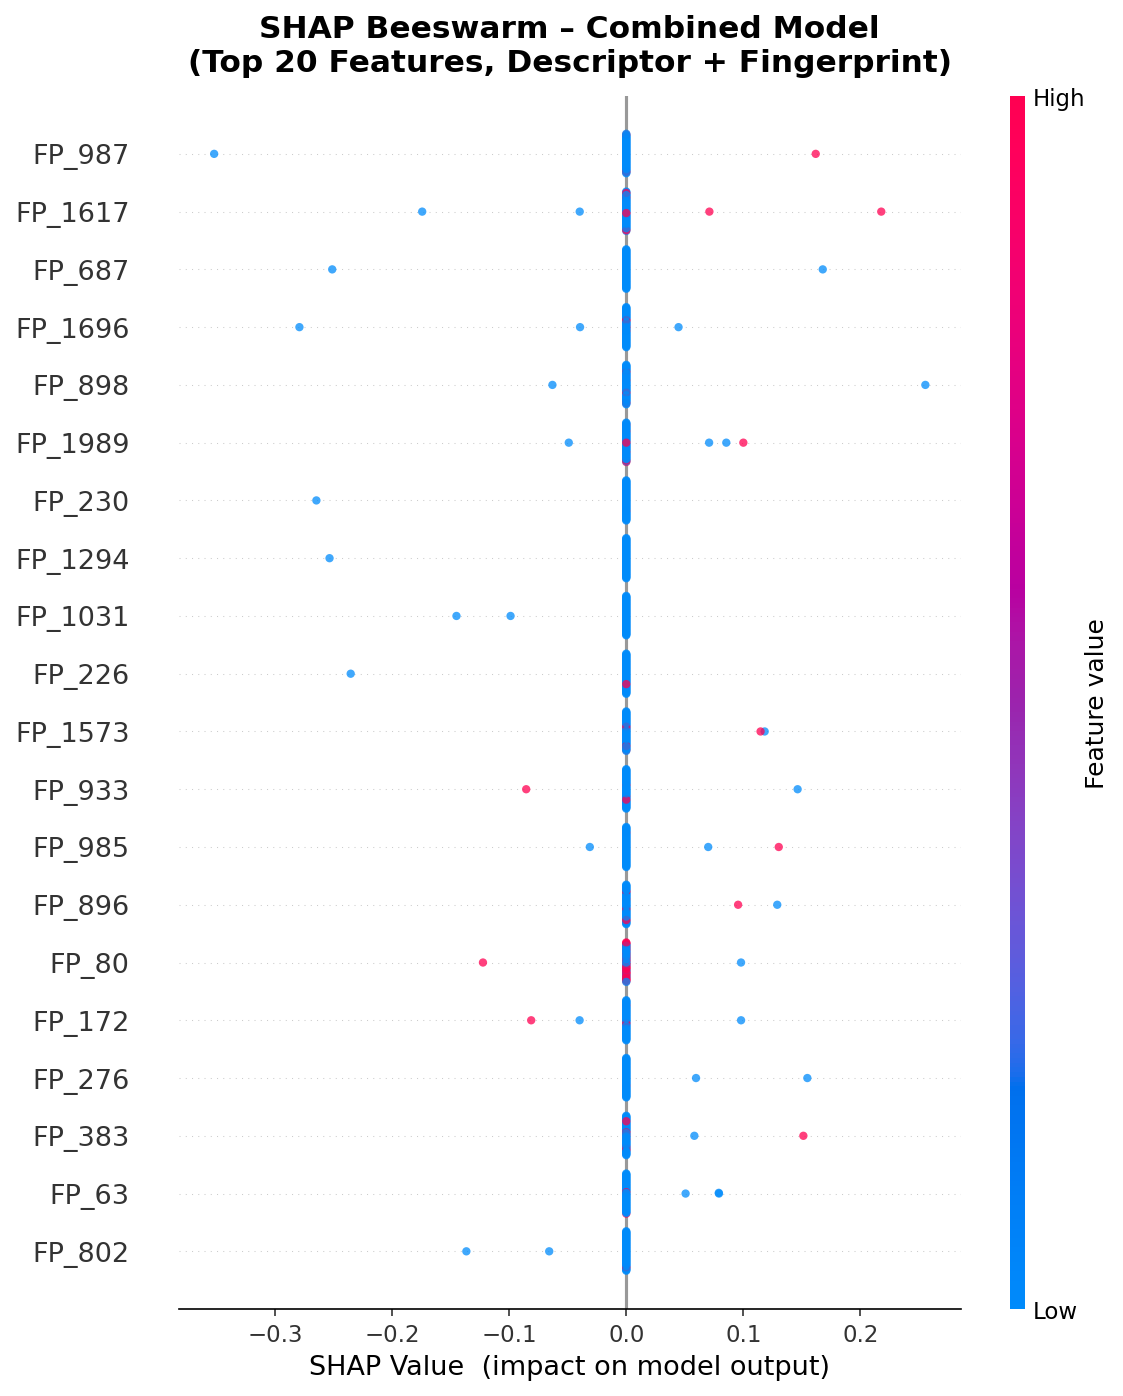

Saved: shap_combined_summary.png


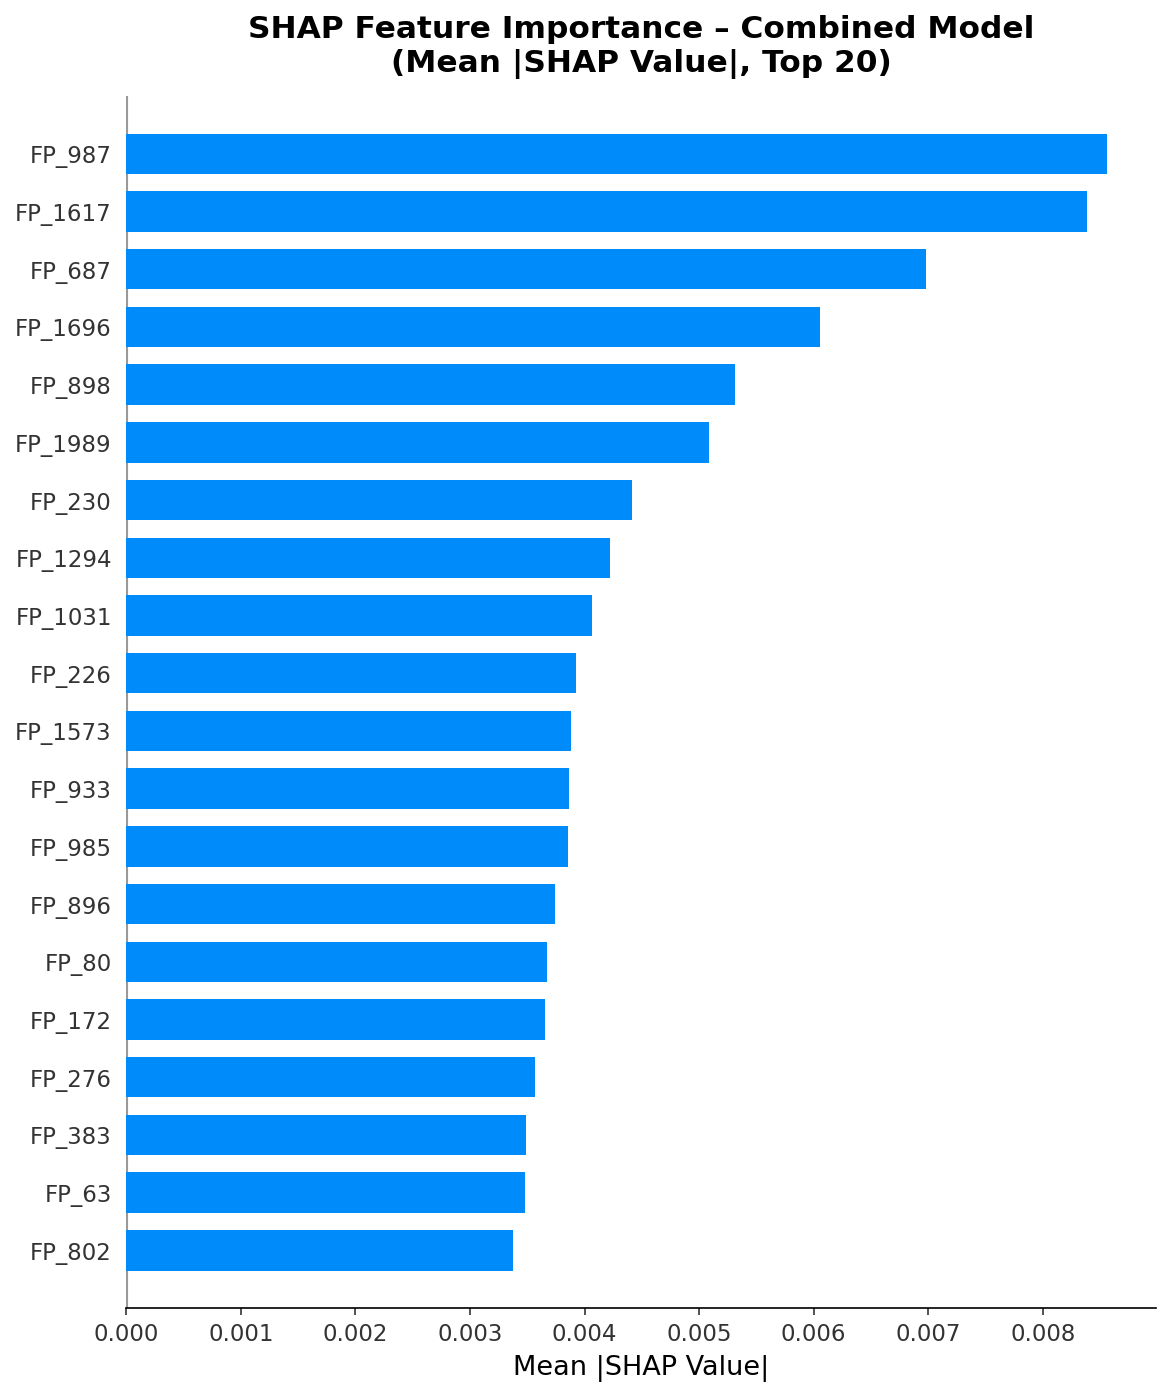

Saved: shap_combined_bar.png


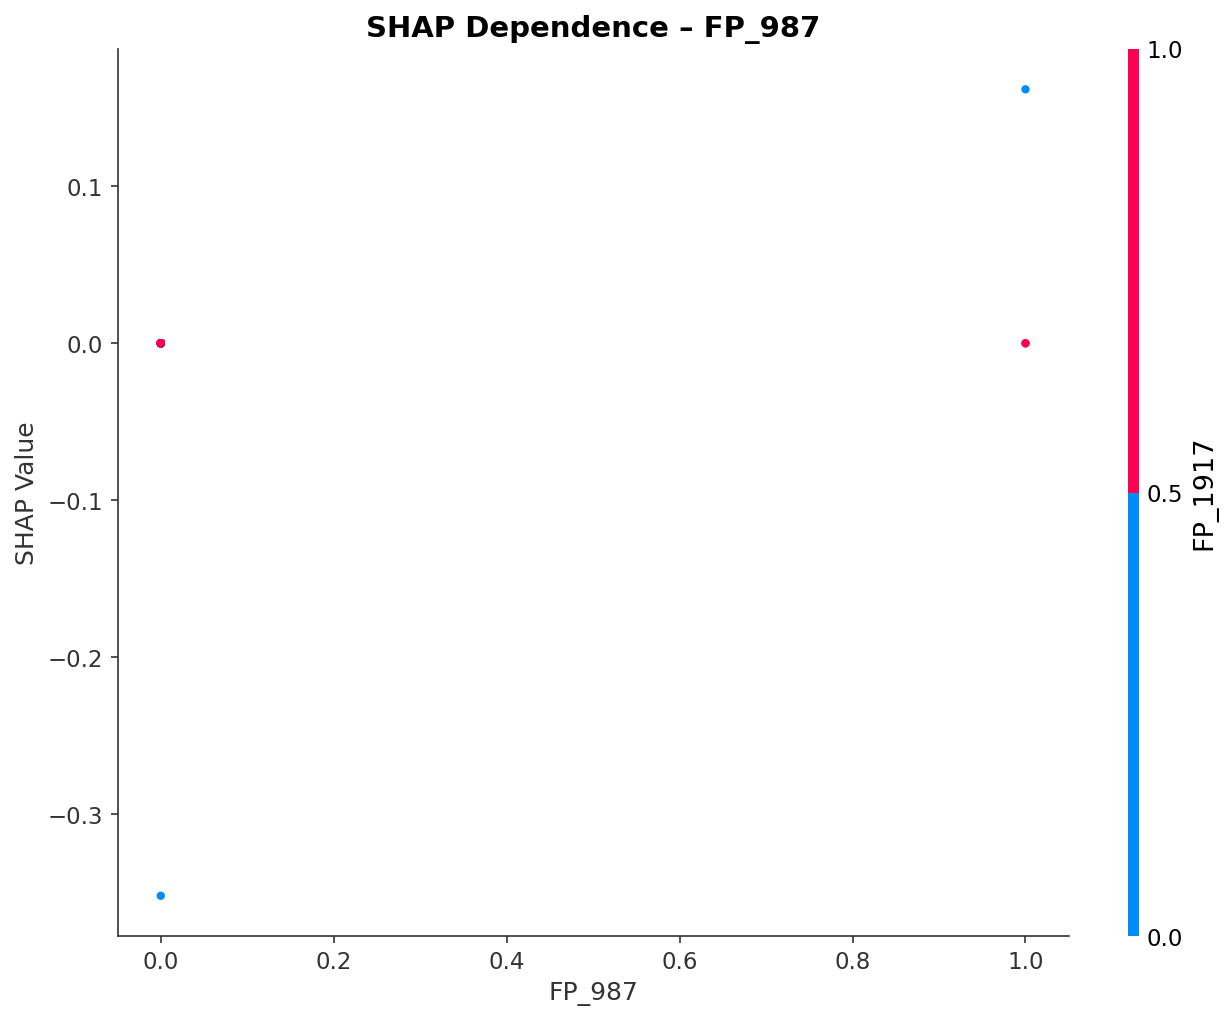

Saved: shap_dependence_comb.png


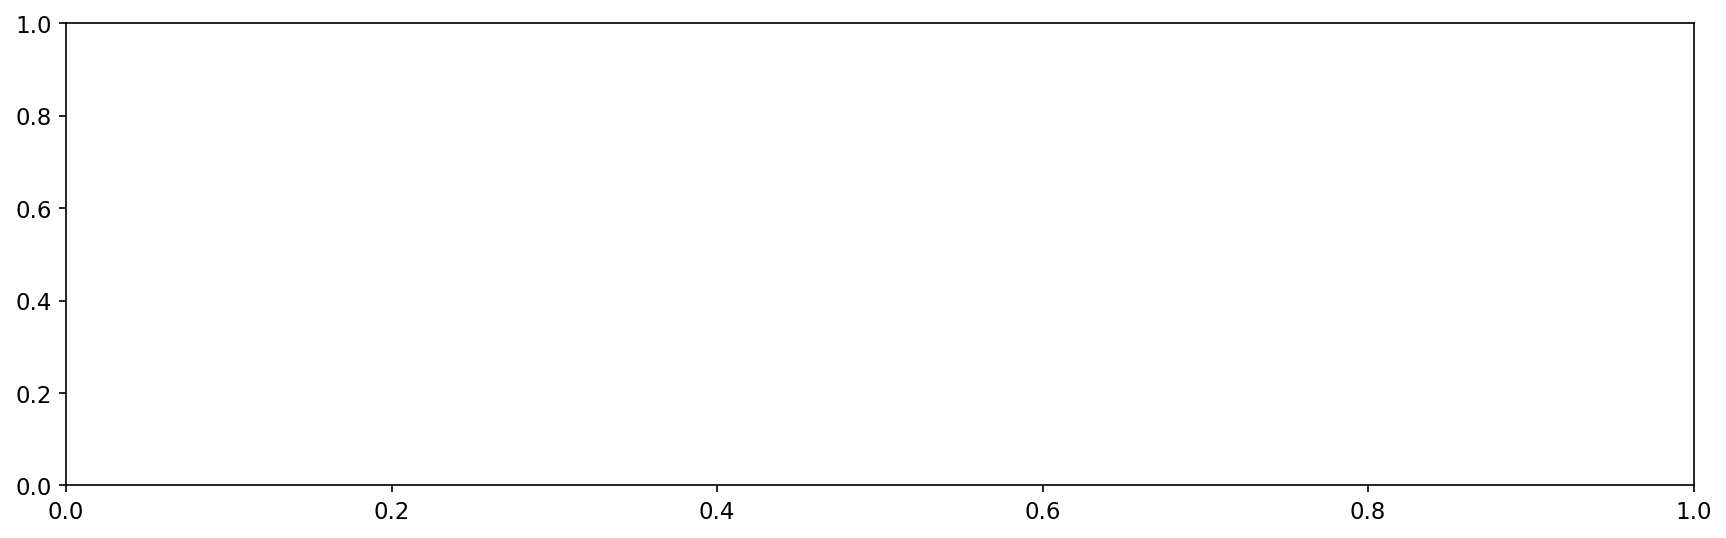

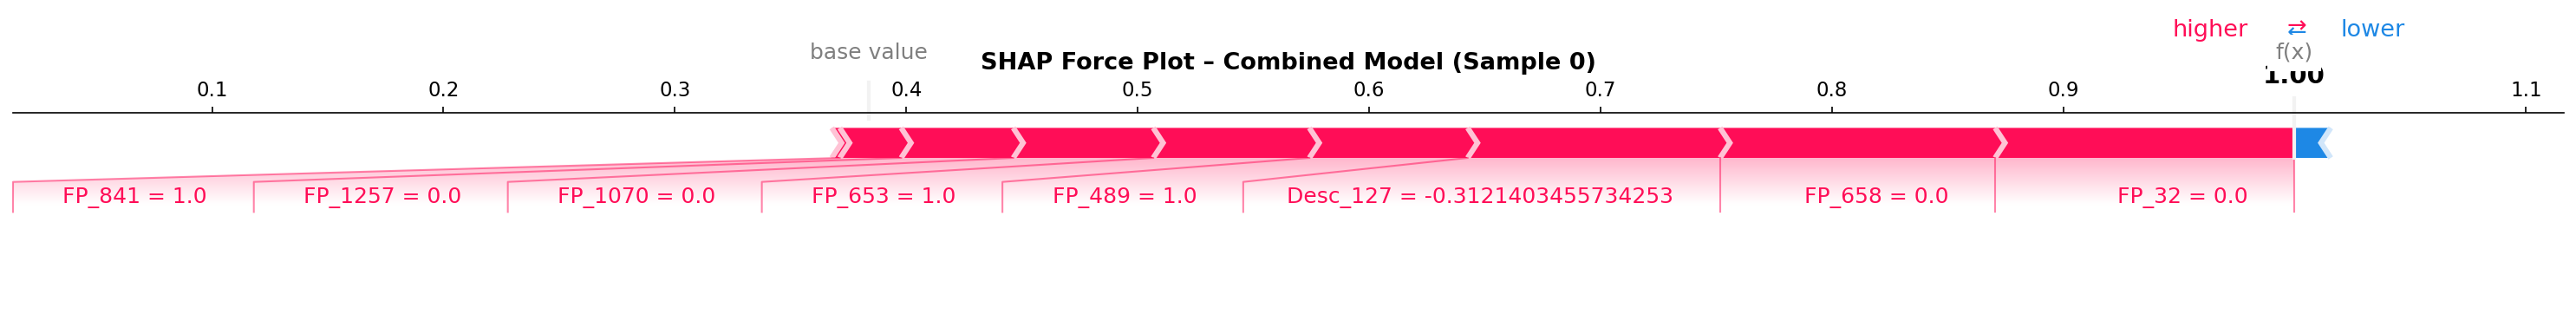

Saved: shap_force_comb.png

Top 20 Combined Features:
Feature  Mean_Abs_SHAP
 FP_987       0.008564
FP_1617       0.008381
 FP_687       0.006983
FP_1696       0.006055
 FP_898       0.005309
FP_1989       0.005088
 FP_230       0.004411
FP_1294       0.004224
FP_1031       0.004064
 FP_226       0.003923
FP_1573       0.003882
 FP_933       0.003864
 FP_985       0.003856
 FP_896       0.003741
  FP_80       0.003673
 FP_172       0.003652
 FP_276       0.003571
 FP_383       0.003490
  FP_63       0.003481
 FP_802       0.003373


In [ ]:
# ================================================================
# 7. SHAP EXPLAINABILITY – COMBINED MODEL
# ================================================================
print("\n" + "="*60)
print("SHAP ANALYSIS – COMBINED MODEL")
print("="*60)

import matplotlib
matplotlib.rcParams.update({
    'font.size': 13, 'axes.titlesize': 15, 'axes.labelsize': 13,
    'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'font.family': 'DejaVu Sans', 'figure.dpi': 150,
})

first_params    = preprocessing_params[0]
scaler_desc_shap = first_params['scaler_desc']
scaler_fp_shap   = first_params['scaler_fp']
d_lo, d_hi       = first_params['desc_clips']
f_lo, f_hi       = first_params['fp_clips']

X_desc_test_clipped = np.clip(X_desc_test, d_lo, d_hi)
X_fp_test_clipped   = np.clip(X_fp_test,   f_lo, f_hi)
X_desc_test_shap = scaler_desc_shap.transform(X_desc_test_clipped).astype(np.float32)
X_fp_test_shap   = scaler_fp_shap.transform(X_fp_test_clipped).astype(np.float32)

Xd_bg_pool = np.clip(X_desc_trainval[:1000], d_lo, d_hi)
Xf_bg_pool = np.clip(X_fp_trainval[:1000],   f_lo, f_hi)
Xd_bg_pool = scaler_desc_shap.transform(Xd_bg_pool).astype(np.float32)
Xf_bg_pool = scaler_fp_shap.transform(Xf_bg_pool).astype(np.float32)

Xd_bg_mean = Xd_bg_pool.mean(axis=0, keepdims=True)
Xf_bg_mean = Xf_bg_pool.mean(axis=0, keepdims=True)
X_bg_comb  = np.hstack([Xd_bg_mean, Xf_bg_mean])

m_comb_shap = best_models['comb'][0]

def predict_fn_comb(X):
    split = X_desc_test_shap.shape[1]
    return m_comb_shap.predict([X[:, :split], X[:, split:]], verbose=0).ravel()

explainer_comb = shap.KernelExplainer(predict_fn_comb, X_bg_comb)

n_sample   = min(60, len(X_desc_test_shap))
np.random.seed(42)
idx_sample = np.random.choice(len(X_desc_test_shap), n_sample, replace=False)
X_sample   = np.hstack([X_desc_test_shap[idx_sample], X_fp_test_shap[idx_sample]])

print(f"Computing SHAP values for {n_sample} test samples (nsamples=200)...")
shap_values_comb = explainer_comb.shap_values(X_sample, nsamples=200)

feature_names_comb = (
    [f"Desc_{i}" for i in range(X_desc_test_shap.shape[1])] +
    [f"FP_{i}"   for i in range(X_fp_test_shap.shape[1])]
)

shap_std   = np.abs(shap_values_comb).max(axis=0)
active_idx = np.where(shap_std > 1e-8)[0]
print(f"Active (non-zero) SHAP features: {len(active_idx)} / {shap_values_comb.shape[1]}")

shap_active       = shap_values_comb[:, active_idx]
X_sample_active   = X_sample[:, active_idx]
names_active      = [feature_names_comb[i] for i in active_idx]

#Beeswarm / Summary plot
fig, ax = plt.subplots(figsize=(12, 9))
shap.summary_plot(shap_active, X_sample_active,
                  feature_names=names_active,
                  max_display=20, show=False, alpha=0.75)
ax = plt.gca()
ax.set_title("SHAP Beeswarm – Combined Model\n(Top 20 Features, Descriptor + Fingerprint)",
             fontsize=15, fontweight='bold', pad=12)
ax.set_xlabel("SHAP Value  (impact on model output)", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'shap_combined_summary.png'), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: shap_combined_summary.png")

#Bar plot (mean |SHAP|)
fig, ax = plt.subplots(figsize=(12, 9))
shap.summary_plot(shap_active, X_sample_active,
                  feature_names=names_active,
                  plot_type='bar', max_display=20, show=False)
ax = plt.gca()
ax.set_title("SHAP Feature Importance – Combined Model\n(Mean |SHAP Value|, Top 20)",
             fontsize=15, fontweight='bold', pad=12)
ax.set_xlabel("Mean |SHAP Value|", fontsize=13)
ax.tick_params(axis='y', labelsize=11)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'shap_combined_bar.png'), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: shap_combined_bar.png")

#Dependence plot (top feature)
mean_abs_shap_comb = np.abs(shap_active).mean(axis=0)
top_local_idx      = int(np.argmax(mean_abs_shap_comb))
fig, ax = plt.subplots(figsize=(9, 7))
shap.dependence_plot(top_local_idx, shap_active, X_sample_active,
                     feature_names=names_active, show=False, ax=ax)
ax.set_title(f"SHAP Dependence – {names_active[top_local_idx]}",
             fontsize=14, fontweight='bold')
ax.set_xlabel(names_active[top_local_idx], fontsize=12)
ax.set_ylabel("SHAP Value", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'shap_dependence_comb.png'), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: shap_dependence_comb.png")

#Force plot (first sample)
fig, ax = plt.subplots(figsize=(14, 4))
shap.force_plot(explainer_comb.expected_value,
                shap_active[0, :], X_sample_active[0, :],
                feature_names=names_active,
                matplotlib=True, show=False)
plt.title("SHAP Force Plot – Combined Model (Sample 0)",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'shap_force_comb.png'), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: shap_force_comb.png")

#Save importance table
feat_imp_comb = pd.DataFrame({
    'Feature': names_active,
    'Mean_Abs_SHAP': mean_abs_shap_comb
}).sort_values('Mean_Abs_SHAP', ascending=False)
feat_imp_comb.to_csv(os.path.join(SAVE_DIR, 'shap_combined_importance.csv'), index=False)
print("\nTop 20 Combined Features:")
print(feat_imp_comb.head(20).to_string(index=False))



SHAP ANALYSIS – DESCRIPTOR MODEL

Creating SHAP explainer for descriptor model...

Calculating SHAP values for 50 test samples...


  0%|          | 0/50 [00:00<?, ?it/s]

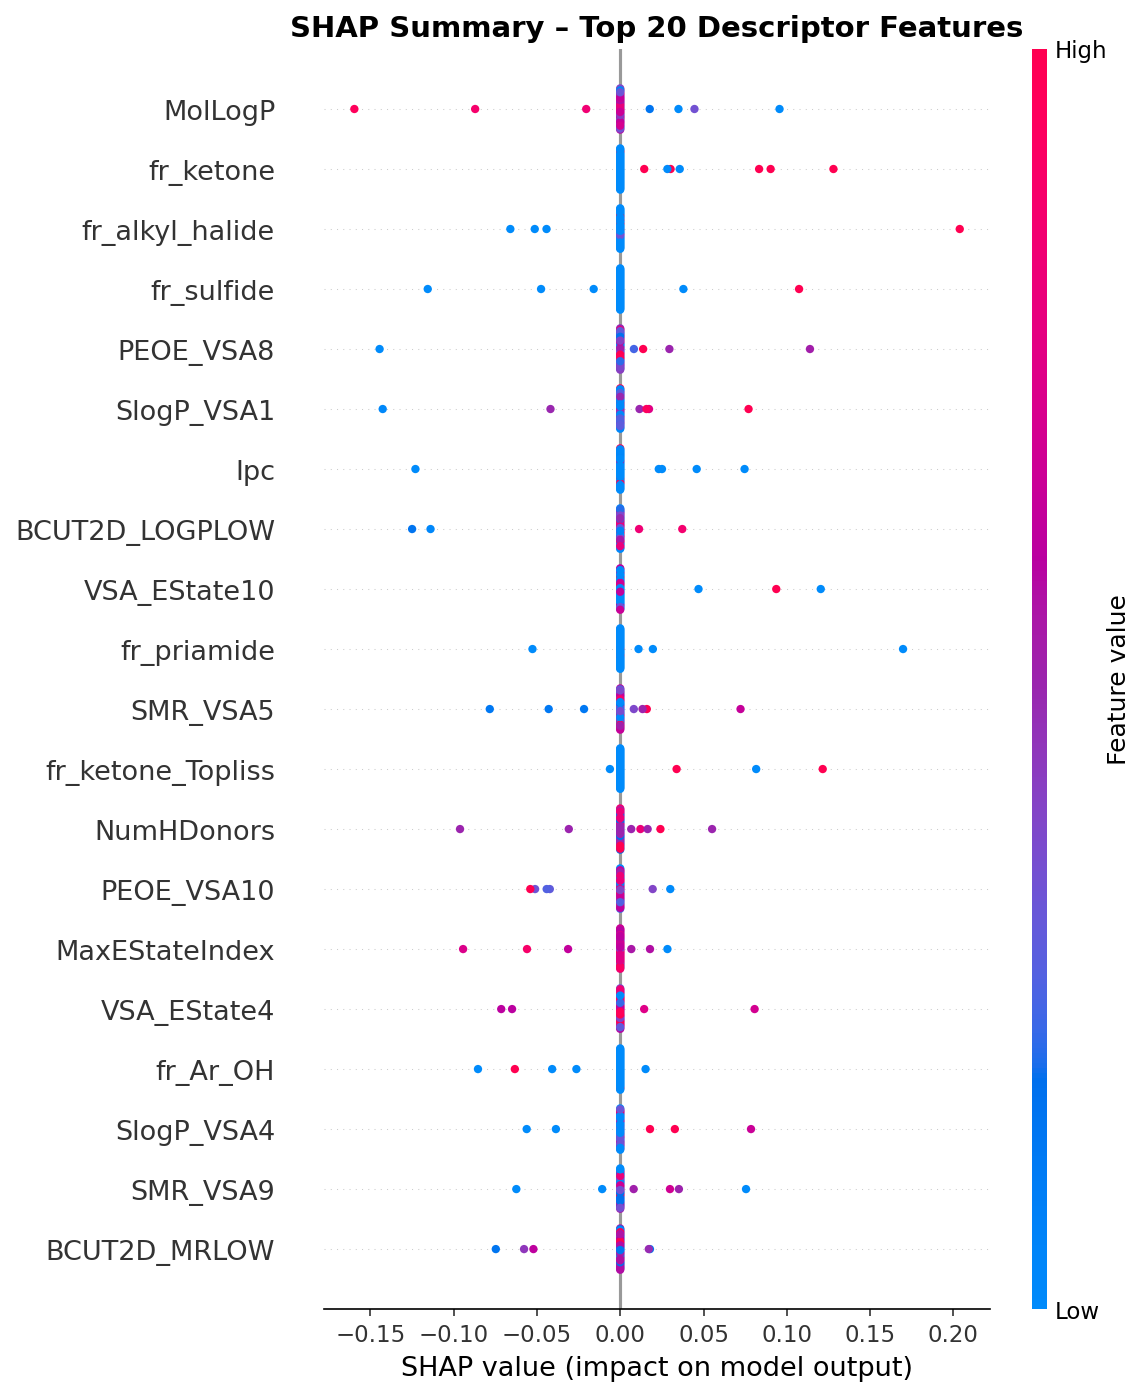

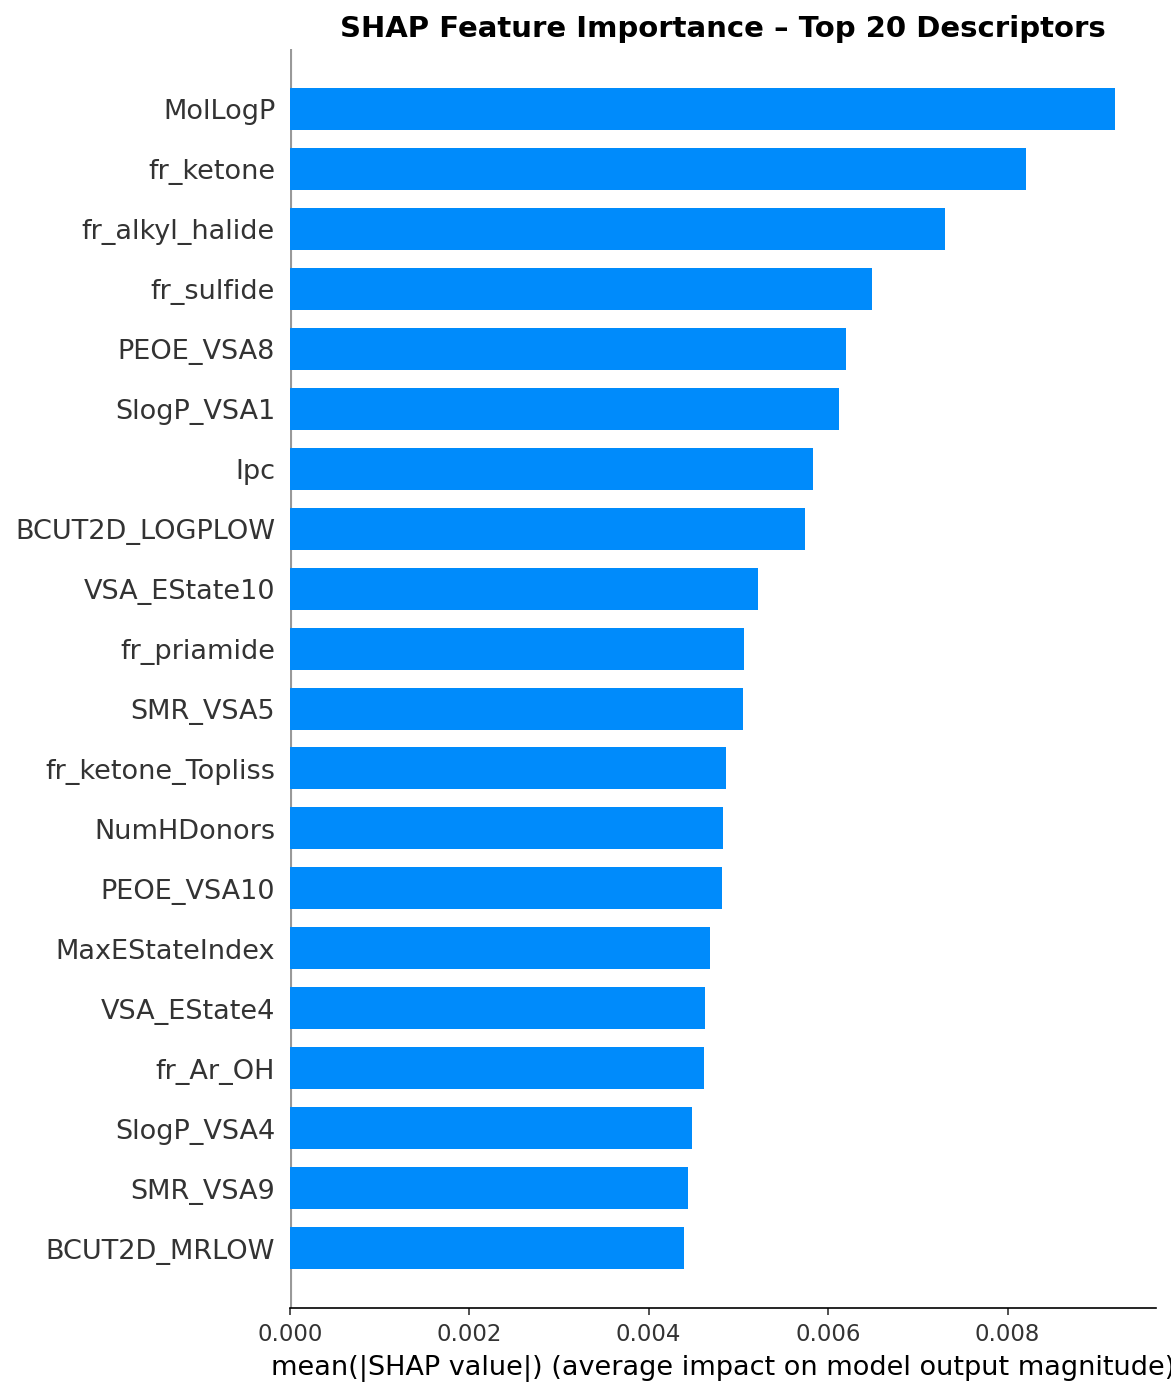


Top 20 Most Important Descriptor Features:
               Feature  Mean_Abs_SHAP
130            MolLogP       0.009199
183          fr_ketone       0.008207
157    fr_alkyl_halide       0.007305
207         fr_sulfide       0.006485
59           PEOE_VSA8       0.006197
71          SlogP_VSA1       0.006122
42                 Ipc       0.005834
23      BCUT2D_LOGPLOW       0.005746
96        VSA_EState10       0.005221
203        fr_priamide       0.005061
66            SMR_VSA5       0.005054
184  fr_ketone_Topliss       0.004864
119         NumHDonors       0.004830
48          PEOE_VSA10       0.004820
1       MaxEStateIndex       0.004689
99         VSA_EState4       0.004627
139           fr_Ar_OH       0.004619
77          SlogP_VSA4       0.004478
70            SMR_VSA9       0.004437
25        BCUT2D_MRLOW       0.004389
Saved to: /content/drive/MyDrive/models_new/shap_descriptor_importance.csv


In [ ]:
# ================================================================
# 7b. SHAP ANALYSIS – DESCRIPTOR MODEL
# ================================================================
print("\n" + "="*80)
print("SHAP ANALYSIS – DESCRIPTOR MODEL")
print("="*80)

# Prepare background from trainval set (same preprocessing as first fold)
np.random.seed(42)
# Use a subset of trainval (already clipped & scaled with first fold's scaler)
Xd_bg_full = np.clip(X_desc_trainval[:1000], d_lo, d_hi)
Xd_bg_full = scaler_desc_shap.transform(Xd_bg_full).astype(np.float32)
background_size = min(100, len(Xd_bg_full))
background_indices = np.random.choice(len(Xd_bg_full), background_size, replace=False)
X_desc_background = Xd_bg_full[background_indices]

# Use the best descriptor model from the first fold
m_desc_shap = best_models['desc'][0]
print("\nCreating SHAP explainer for descriptor model...")
explainer_desc = shap.KernelExplainer(
    lambda x: m_desc_shap.predict(x, verbose=0).ravel(),
    X_desc_background
)

# Use the already scaled test descriptors (X_desc_test_shap)
test_sample_size = min(50, len(X_desc_test_shap))
test_indices = np.random.choice(len(X_desc_test_shap), test_sample_size, replace=False)
X_desc_test_sample = X_desc_test_shap[test_indices]

print(f"\nCalculating SHAP values for {test_sample_size} test samples...")
shap_values_desc = explainer_desc.shap_values(X_desc_test_sample, nsamples=100)

# Feature names (using original descriptor column names)
desc_feature_names = desc_feat_cols  # global from data loading

# SHAP summary plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_desc, X_desc_test_sample,
                  feature_names=desc_feature_names,
                  max_display=20, show=False)
plt.title('SHAP Summary – Top 20 Descriptor Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'shap_descriptor_summary.png'), dpi=300, bbox_inches='tight')
plt.show()

# SHAP bar plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_desc, X_desc_test_sample,
                  feature_names=desc_feature_names,
                  plot_type='bar', max_display=20, show=False)
plt.title('SHAP Feature Importance – Top 20 Descriptors', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'shap_descriptor_bar.png'), dpi=300, bbox_inches='tight')
plt.show()

#Feature importance
mean_abs_shap_desc = np.abs(shap_values_desc).mean(axis=0)
feature_importance_desc = pd.DataFrame({
    'Feature': desc_feature_names,
    'Mean_Abs_SHAP': mean_abs_shap_desc
}).sort_values('Mean_Abs_SHAP', ascending=False)

print("\nTop 20 Most Important Descriptor Features:")
print(feature_importance_desc.head(20))
feature_importance_desc.to_csv(os.path.join(SAVE_DIR, 'shap_descriptor_importance.csv'), index=False)
print(f"Saved to: {os.path.join(SAVE_DIR, 'shap_descriptor_importance.csv')}")


SHAP ANALYSIS – FINGERPRINT MODEL
FP background shape (mean vector): (1, 2048)
Creating SHAP KernelExplainer for fingerprint model...
Computing SHAP values for 60 test samples (nsamples=200)...


  0%|          | 0/60 [00:00<?, ?it/s]

Active FP bits with non-zero SHAP: 442 / 2048


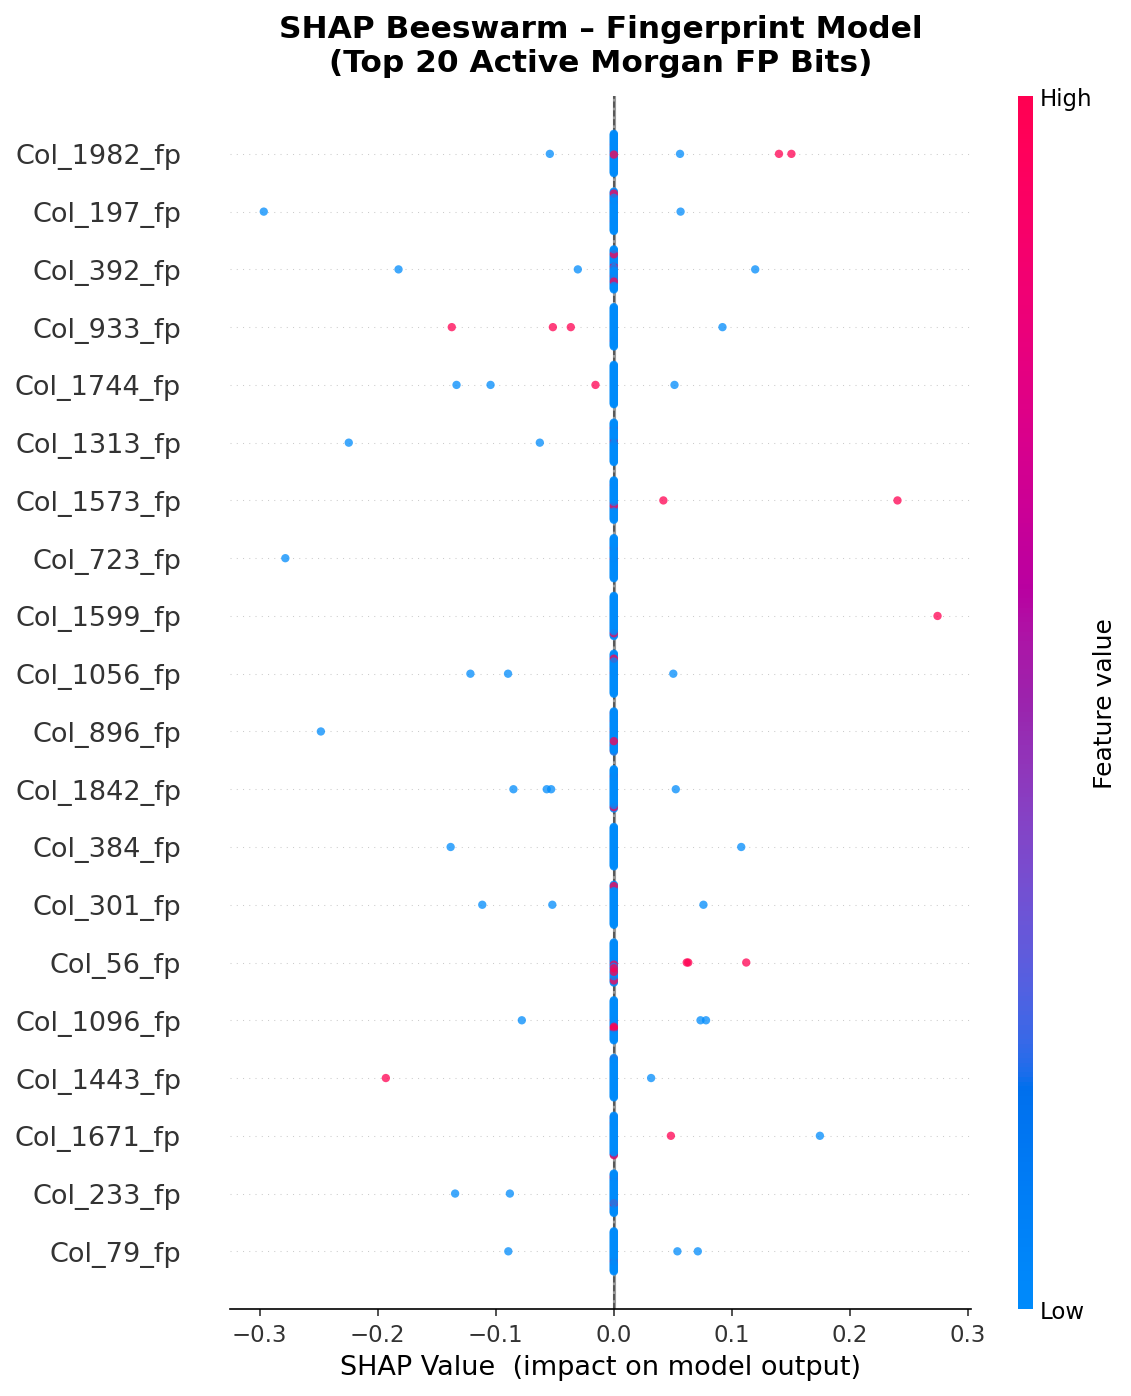

Saved: shap_fingerprint_summary.png


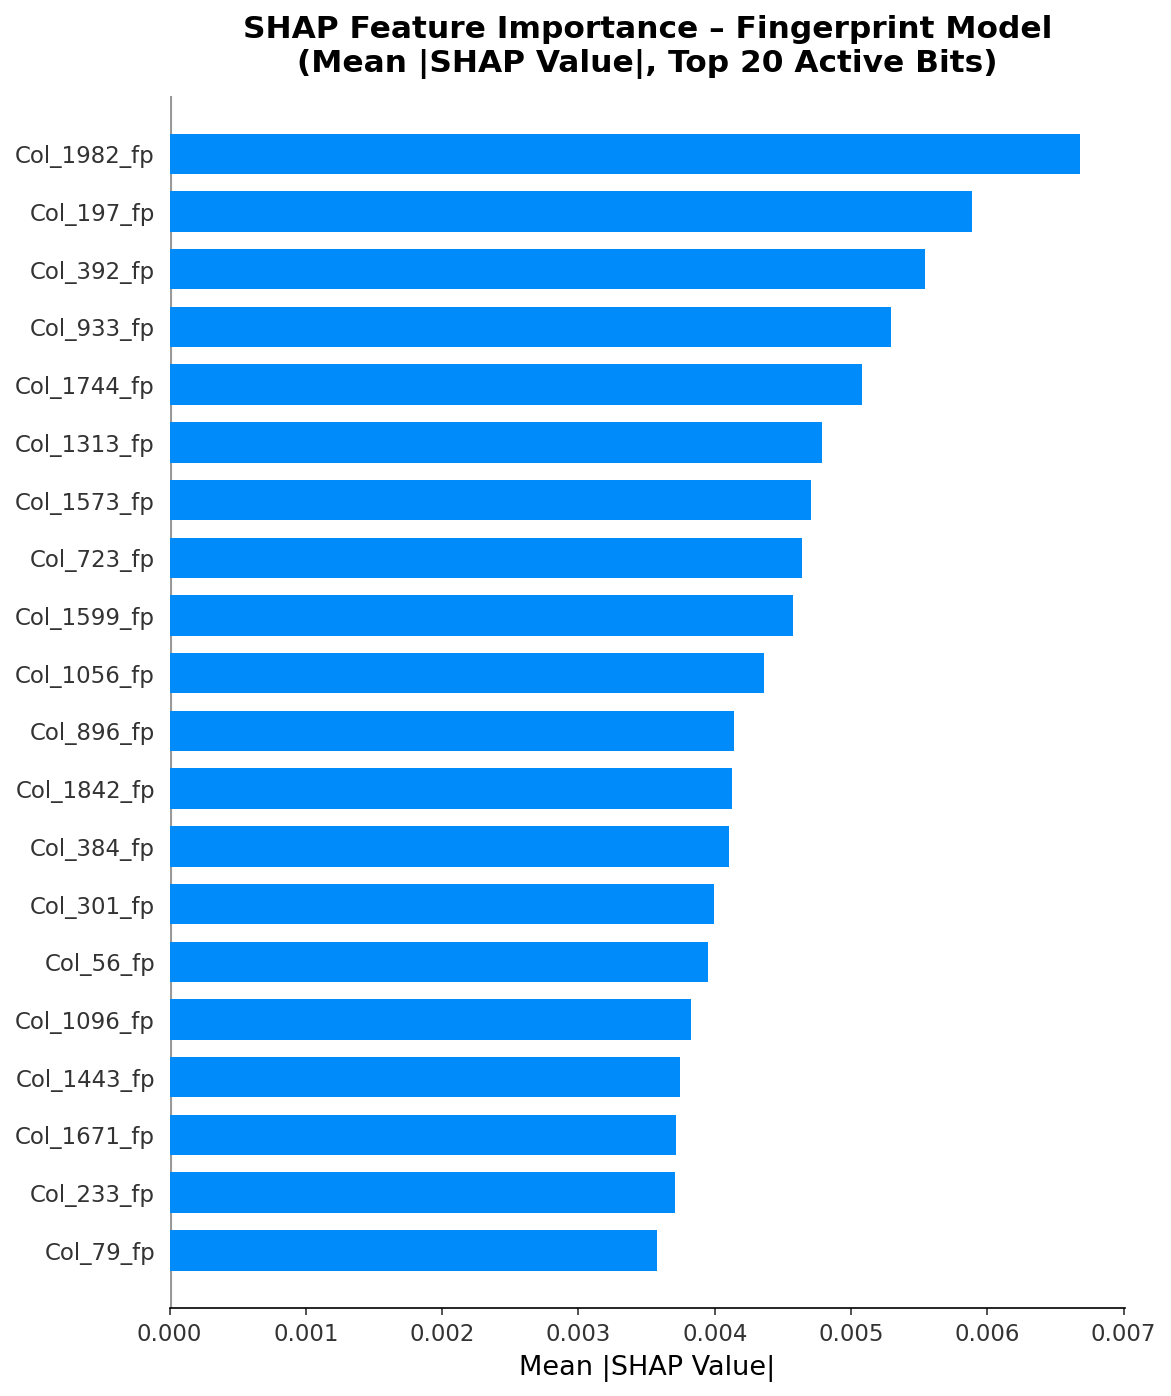

Saved: shap_fingerprint_bar.png


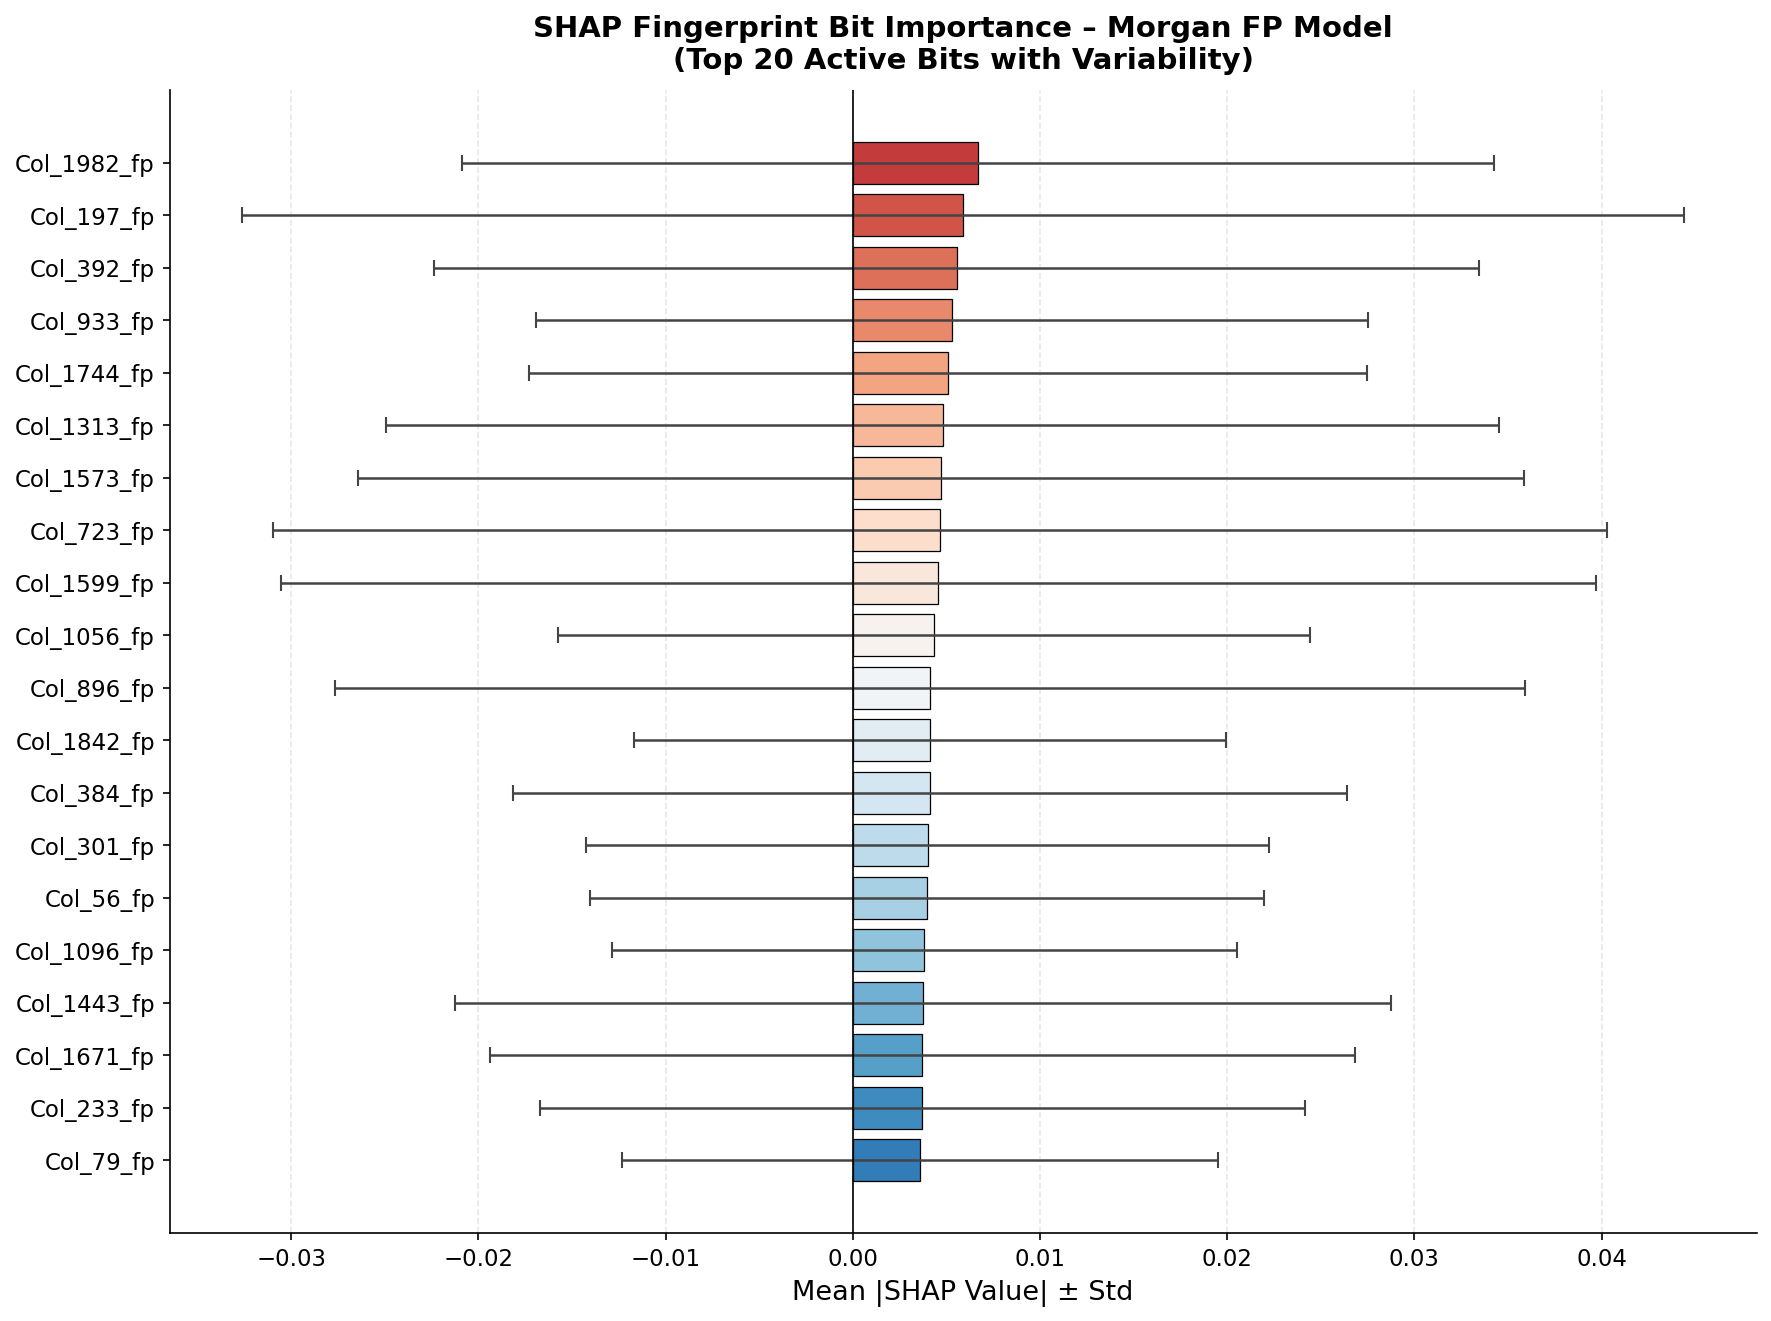

Saved: shap_fingerprint_ranked_bar.png


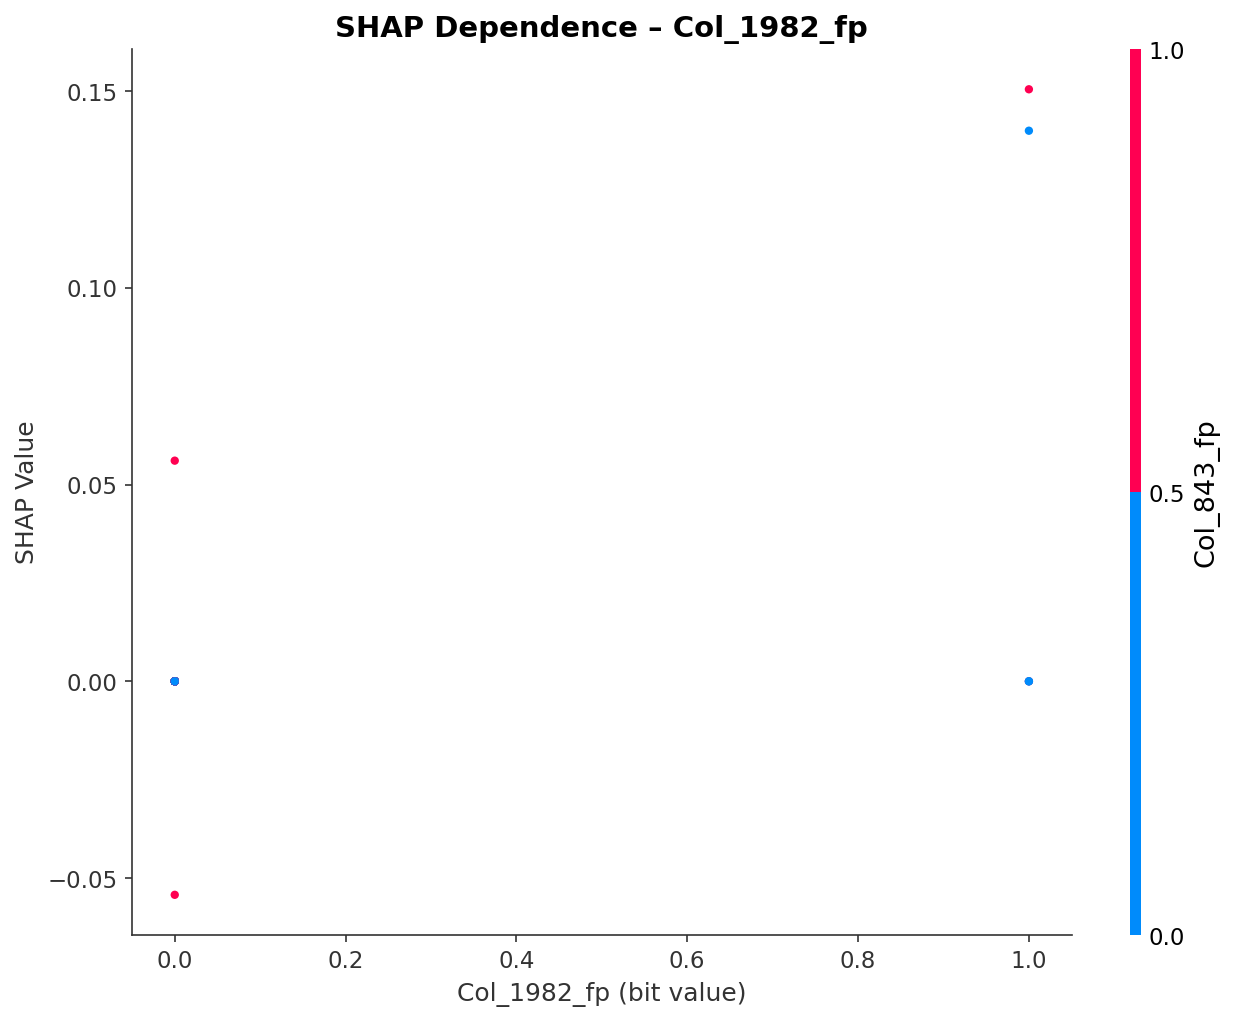

Saved: shap_fingerprint_dependence.png

Top 20 Most Important Fingerprint Bits:
    Feature  Mean_Abs_SHAP  Std_Abs_SHAP  Max_Abs_SHAP
Col_1982_fp       0.006678      0.027573      0.150440
 Col_197_fp       0.005886      0.038535      0.296614
 Col_392_fp       0.005546      0.027903      0.182446
 Col_933_fp       0.005292      0.022230      0.137334
Col_1744_fp       0.005079      0.022368      0.133305
Col_1313_fp       0.004789      0.029723      0.224608
Col_1573_fp       0.004704      0.031139      0.240307
 Col_723_fp       0.004639      0.035632      0.278337
Col_1599_fp       0.004570      0.035106      0.274226
Col_1056_fp       0.004359      0.020087      0.121547
 Col_896_fp       0.004137      0.031780      0.248240
Col_1842_fp       0.004126      0.015827      0.085082
 Col_384_fp       0.004104      0.022272      0.138293
 Col_301_fp       0.003992      0.018236      0.111487
  Col_56_fp       0.003949      0.017995      0.112157
Col_1096_fp       0.003824      0.016678

In [ ]:
# ================================================================
# 7c. SHAP ANALYSIS – FINGERPRINT MODEL
# ================================================================
print("\n" + "="*80)
print("SHAP ANALYSIS – FINGERPRINT MODEL")
print("="*80)

np.random.seed(42)

Xf_bg_pool = np.clip(X_fp_trainval[:1000], f_lo, f_hi)
Xf_bg_pool = scaler_fp_shap.transform(Xf_bg_pool).astype(np.float32)
X_fp_background = Xf_bg_pool.mean(axis=0, keepdims=True)   # shape (1, n_fp)
print(f"FP background shape (mean vector): {X_fp_background.shape}")

m_fp_shap = best_models['fp'][0]
print("Creating SHAP KernelExplainer for fingerprint model...")
explainer_fp = shap.KernelExplainer(
    lambda x: m_fp_shap.predict(x, verbose=0).ravel(),
    X_fp_background
)

test_sample_size_fp = min(60, len(X_fp_test_shap))
test_indices_fp     = np.random.choice(len(X_fp_test_shap), test_sample_size_fp, replace=False)
X_fp_test_sample    = X_fp_test_shap[test_indices_fp]

print(f"Computing SHAP values for {test_sample_size_fp} test samples (nsamples=200)...")
shap_values_fp = explainer_fp.shap_values(X_fp_test_sample, nsamples=200)

shap_max_fp  = np.abs(shap_values_fp).max(axis=0)
active_fp    = np.where(shap_max_fp > 1e-8)[0]
print(f"Active FP bits with non-zero SHAP: {len(active_fp)} / {shap_values_fp.shape[1]}")

shap_fp_active  = shap_values_fp[:, active_fp]
X_fp_active     = X_fp_test_sample[:, active_fp]
fp_feat_names   = fp_feat_cols
names_fp_active = [fp_feat_names[i] for i in active_fp]

#Beeswarm / Summary plot
fig, ax = plt.subplots(figsize=(12, 9))
shap.summary_plot(shap_fp_active, X_fp_active,
                  feature_names=names_fp_active,
                  max_display=20, show=False, alpha=0.75)
ax = plt.gca()
ax.set_title("SHAP Beeswarm – Fingerprint Model\n(Top 20 Active Morgan FP Bits)",
             fontsize=15, fontweight='bold', pad=12)
ax.set_xlabel("SHAP Value  (impact on model output)", fontsize=13)

ax.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'shap_fingerprint_summary.png'), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: shap_fingerprint_summary.png")

#Bar plot
mean_abs_shap_fp = np.abs(shap_fp_active).mean(axis=0)
top20_local      = np.argsort(mean_abs_shap_fp)[::-1][:20]

fig, ax = plt.subplots(figsize=(12, 9))
shap.summary_plot(shap_fp_active, X_fp_active,
                  feature_names=names_fp_active,
                  plot_type='bar', max_display=20, show=False)
ax = plt.gca()
ax.set_title("SHAP Feature Importance – Fingerprint Model\n(Mean |SHAP Value|, Top 20 Active Bits)",
             fontsize=15, fontweight='bold', pad=12)
ax.set_xlabel("Mean |SHAP Value|", fontsize=13)
ax.tick_params(axis='y', labelsize=11)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'shap_fingerprint_bar.png'), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: shap_fingerprint_bar.png")

#Custom ranked bar chart with error bars (std)
top_k           = min(20, len(active_fp))
top_k_local_idx = np.argsort(mean_abs_shap_fp)[::-1][:top_k]
top_names       = [names_fp_active[i] for i in top_k_local_idx]
top_means       = mean_abs_shap_fp[top_k_local_idx]
top_stds        = np.abs(shap_fp_active[:, top_k_local_idx]).std(axis=0)

fig, ax = plt.subplots(figsize=(12, 9))
colors_bar = plt.cm.RdBu_r(np.linspace(0.15, 0.85, top_k))[::-1]
bars = ax.barh(range(top_k)[::-1], top_means, xerr=top_stds,
               color=colors_bar, edgecolor='black', linewidth=0.6,
               error_kw=dict(ecolor='#444444', capsize=4, elinewidth=1.2))
ax.set_yticks(range(top_k)[::-1])
ax.set_yticklabels(top_names, fontsize=11)
ax.set_xlabel("Mean |SHAP Value| ± Std", fontsize=13)
ax.set_title("SHAP Fingerprint Bit Importance – Morgan FP Model\n(Top 20 Active Bits with Variability)",
             fontsize=14, fontweight='bold', pad=10)
ax.axvline(0, color='black', linewidth=0.8)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'shap_fingerprint_ranked_bar.png'), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: shap_fingerprint_ranked_bar.png")

#Dependence plot (top FP bit)
top1_local = int(top_k_local_idx[0])
fig, ax    = plt.subplots(figsize=(9, 7))
shap.dependence_plot(top1_local, shap_fp_active, X_fp_active,
                     feature_names=names_fp_active, show=False, ax=ax)
ax.set_title(f"SHAP Dependence – {names_fp_active[top1_local]}",
             fontsize=14, fontweight='bold')
ax.set_xlabel(f"{names_fp_active[top1_local]} (bit value)", fontsize=12)
ax.set_ylabel("SHAP Value", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'shap_fingerprint_dependence.png'), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: shap_fingerprint_dependence.png")

#Importance table
feature_importance_fp = pd.DataFrame({
    'Feature':       names_fp_active,
    'Mean_Abs_SHAP': mean_abs_shap_fp,
    'Std_Abs_SHAP':  np.abs(shap_fp_active).std(axis=0),
    'Max_Abs_SHAP':  shap_max_fp[active_fp],
}).sort_values('Mean_Abs_SHAP', ascending=False)

print("\nTop 20 Most Important Fingerprint Bits:")
print(feature_importance_fp.head(20).to_string(index=False))
feature_importance_fp.to_csv(os.path.join(SAVE_DIR, 'shap_fingerprint_importance.csv'), index=False)
print(f"\nSaved: shap_fingerprint_importance.csv")


In [ ]:
# ================================================================
# 8. HELPER FUNCTIONS FOR MOLECULAR VISUALIZATION
# ================================================================
def get_morgan_fingerprint_info(smiles, radius=2, nBits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None, None
    bit_info = {}
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits, bitInfo=bit_info)
    return fp, bit_info

def highlight_atoms_and_bonds(smiles, important_bits, bit_info, top_n=5):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    AllChem.Compute2DCoords(mol)

    atom_highlights = set()
    bond_highlights = set()

    for bit_idx in important_bits[:top_n]:
        if bit_idx in bit_info:
            for center_atom, radius in bit_info[bit_idx]:
                atom_highlights.add(center_atom)
                env = Chem.FindAtomEnvironmentOfRadiusN(mol, radius, center_atom)
                for bond_idx in env:
                    bond = mol.GetBondWithIdx(bond_idx)
                    atom_highlights.add(bond.GetBeginAtomIdx())
                    atom_highlights.add(bond.GetEndAtomIdx())
                    bond_highlights.add(bond_idx)

    try:
        drawer = rdMolDraw2D.MolDraw2DCairo(400, 400)
    except AttributeError:
        drawer = rdMolDraw2D.MolDraw2DSVG(400, 400)

    drawer.DrawMolecule(
        mol,
        highlightAtoms=list(atom_highlights),
        highlightBonds=list(bond_highlights),
        highlightAtomColors={a: (1.0, 0.7, 0.0) for a in atom_highlights},
        highlightBondColors={b: (1.0, 0.5, 0.0) for b in bond_highlights}
    )
    drawer.FinishDrawing()
    img_data = drawer.GetDrawingText()
    try:
        img = Image.open(BytesIO(img_data))
    except Exception:
        from IPython.display import SVG, display
        display(SVG(img_data))
        img = None
    return img


PREDICTIONS AND EXPLAINABILITY FOR TEST MOLECULES
  Preparing SHAP for Imatinib...


  0%|          | 0/1 [00:00<?, ?it/s]

[09:54:22] DEPRECATION WARNING: please use MorganGenerator


  Preparing SHAP for Neratinib...


  0%|          | 0/1 [00:00<?, ?it/s]

...

[09:54:32] DEPRECATION WARNING: please use MorganGenerator


✗ Dasatinib not found in dataset
✗ Navitoclax not found in dataset
  Preparing SHAP for Silmitasertib...


  0%|          | 0/1 [00:00<?, ?it/s]

[09:54:35] DEPRECATION WARNING: please use MorganGenerator



SUMMARY OF PREDICTIONS FOR ALL TEST MOLECULES
      Molecule  Combined_Prob  Combined_Pred  Desc_Prob  FP_Prob
      Imatinib       0.445261              0   0.423477 0.420075
     Neratinib       0.034965              0   0.027713 0.027949
   Sitagliptin       0.958453              1   0.974464 0.979999
     Sunitinib       0.434007              0   0.455050 0.439658
Leucettinib-92       0.561877              1   0.452644 0.587033
 Silmitasertib       0.613042              1   0.453455 0.442743

✓ Predictions saved to: /content/drive/MyDrive/models_new/test_molecules_predictions.csv

GENERATING SHAP VISUALISATIONS FOR ALL TEST MOLECULES

--- Imatinib ---
  Top 10 fingerprint features:
    1. Feature 562 (Bit 562): SHAP = -0.279569
    2. Feature 1768 (Bit 1768): SHAP = -0.184058
    3. Feature 167 (Bit 167): SHAP = 0.109723
    4. Feature 809 (Bit 809): SHAP = 0.090885
    5. Feature 1855 (Bit 1855): SHAP = 0.070460
    6. Feature 162 (Bit 162): SHAP = 0.065219
    7. Feature 673 (Bi

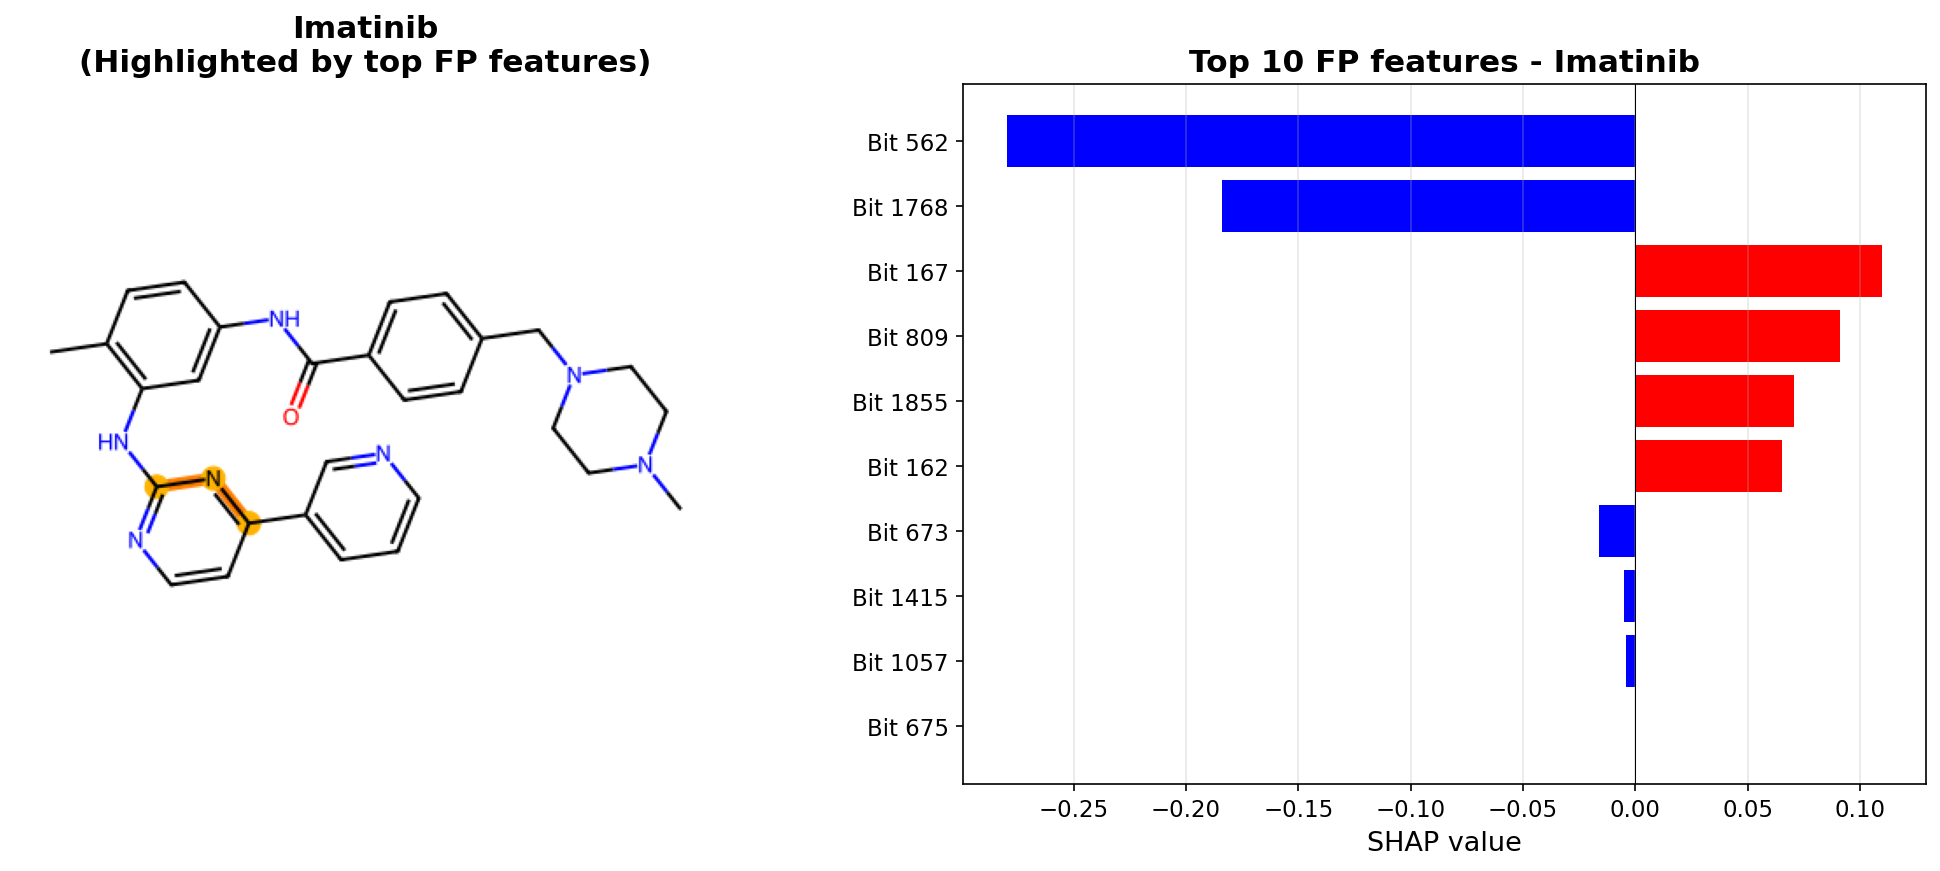


--- Neratinib ---
  Top 10 fingerprint features:
    1. Feature 1041 (Bit 1041): SHAP = -0.123292
    2. Feature 1314 (Bit 1314): SHAP = -0.110597
    3. Feature 1516 (Bit 1516): SHAP = -0.100266
    4. Feature 155 (Bit 155): SHAP = -0.077666
    5. Feature 1546 (Bit 1546): SHAP = -0.048874
    6. Feature 172 (Bit 172): SHAP = -0.037951
    7. Feature 1379 (Bit 1379): SHAP = -0.033776
    8. Feature 552 (Bit 552): SHAP = -0.030353
    9. Feature 1803 (Bit 1803): SHAP = -0.018644
    10. Feature 1726 (Bit 1726): SHAP = 0.016315


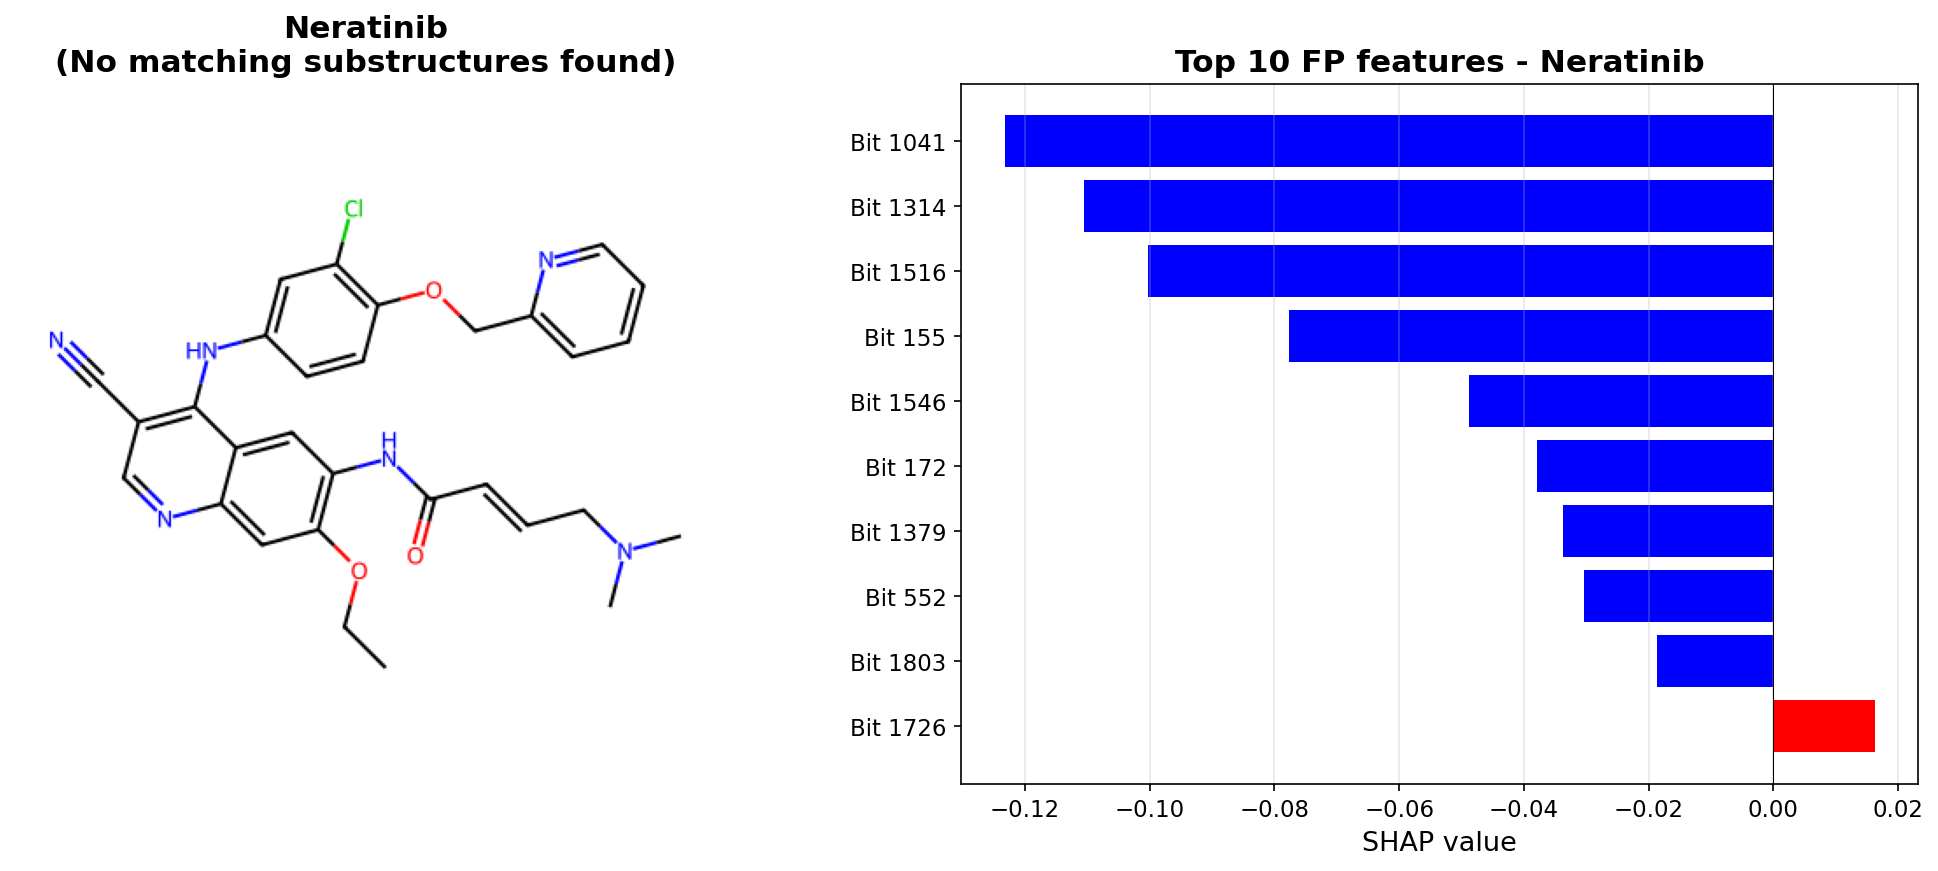


--- Sitagliptin ---
  Top 10 fingerprint features:
    1. Feature 1126 (Bit 1126): SHAP = 0.099702
    2. Feature 745 (Bit 745): SHAP = 0.099702
    3. Feature 576 (Bit 576): SHAP = 0.089916
    4. Feature 425 (Bit 425): SHAP = 0.089916
    5. Feature 598 (Bit 598): SHAP = 0.071073
    6. Feature 561 (Bit 561): SHAP = 0.041858
    7. Feature 811 (Bit 811): SHAP = -0.034677
    8. Feature 1348 (Bit 1348): SHAP = -0.034677
    9. Feature 685 (Bit 685): SHAP = 0.000000
    10. Feature 684 (Bit 684): SHAP = 0.000000


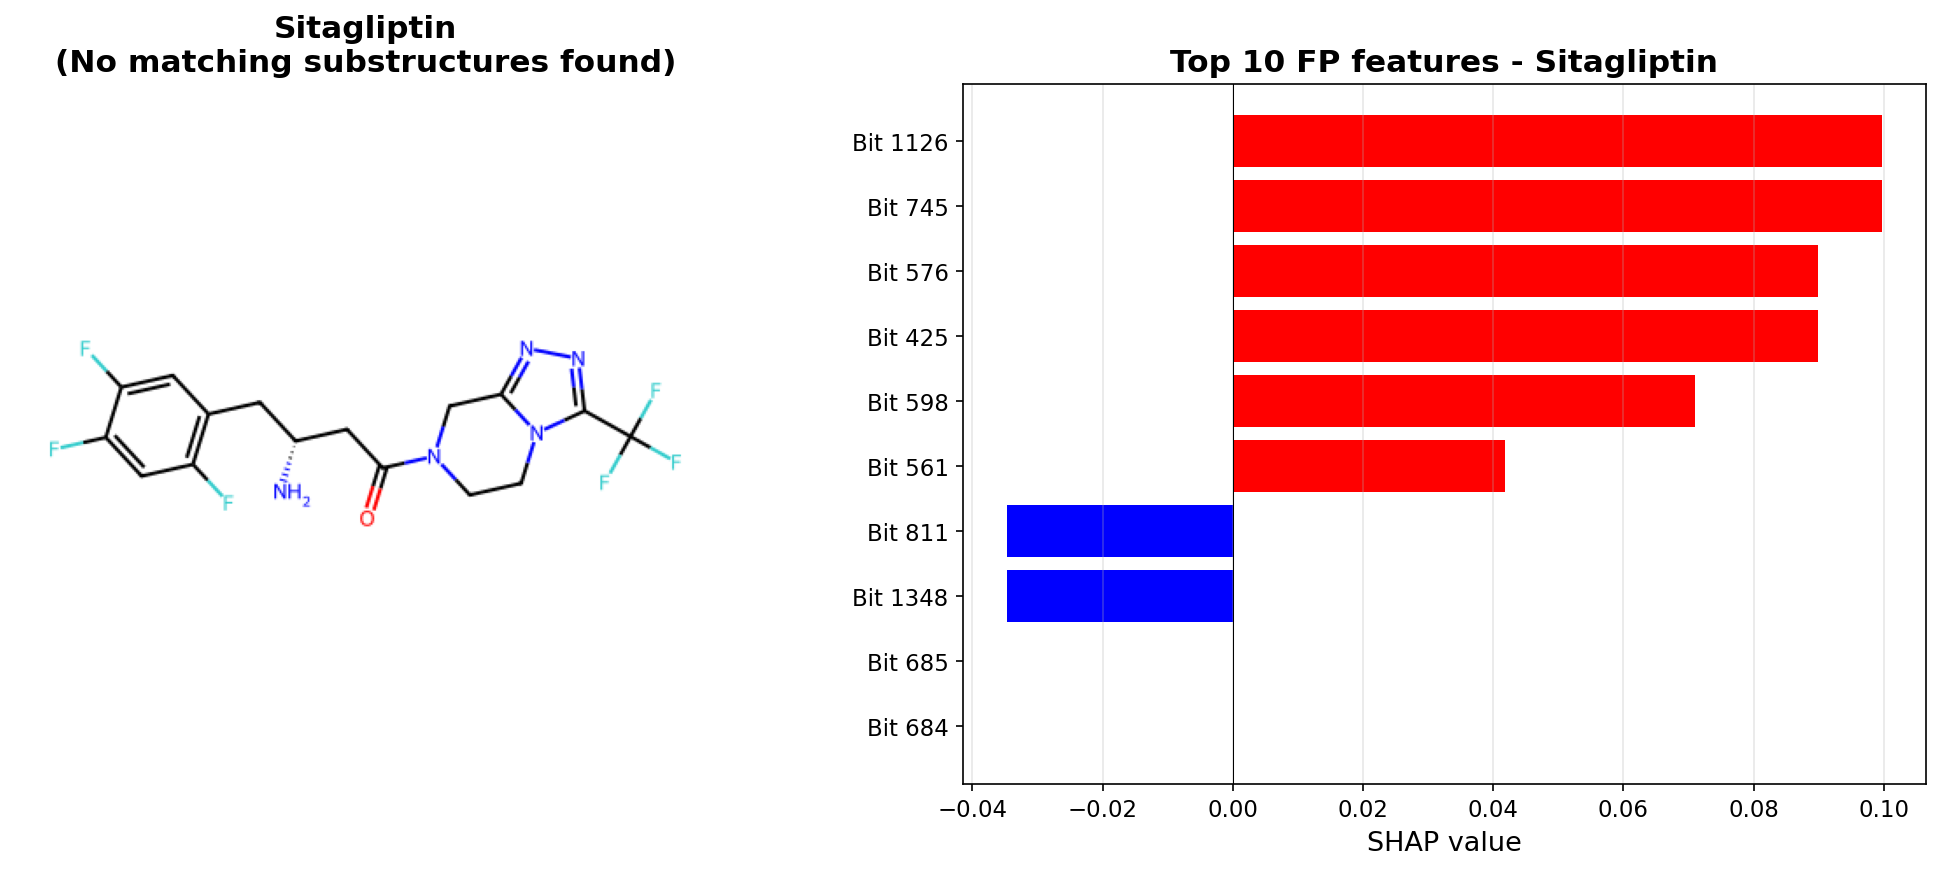


--- Sunitinib ---
  Top 10 fingerprint features:
    1. Feature 387 (Bit 387): SHAP = -0.129079
    2. Feature 576 (Bit 576): SHAP = 0.106943
    3. Feature 1039 (Bit 1039): SHAP = -0.104918
    4. Feature 194 (Bit 194): SHAP = -0.091149
    5. Feature 9 (Bit 9): SHAP = 0.075905
    6. Feature 1303 (Bit 1303): SHAP = 0.056050
    7. Feature 1275 (Bit 1275): SHAP = -0.005447
    8. Feature 1242 (Bit 1242): SHAP = 0.005055
    9. Feature 987 (Bit 987): SHAP = 0.002765
    10. Feature 1154 (Bit 1154): SHAP = -0.000875


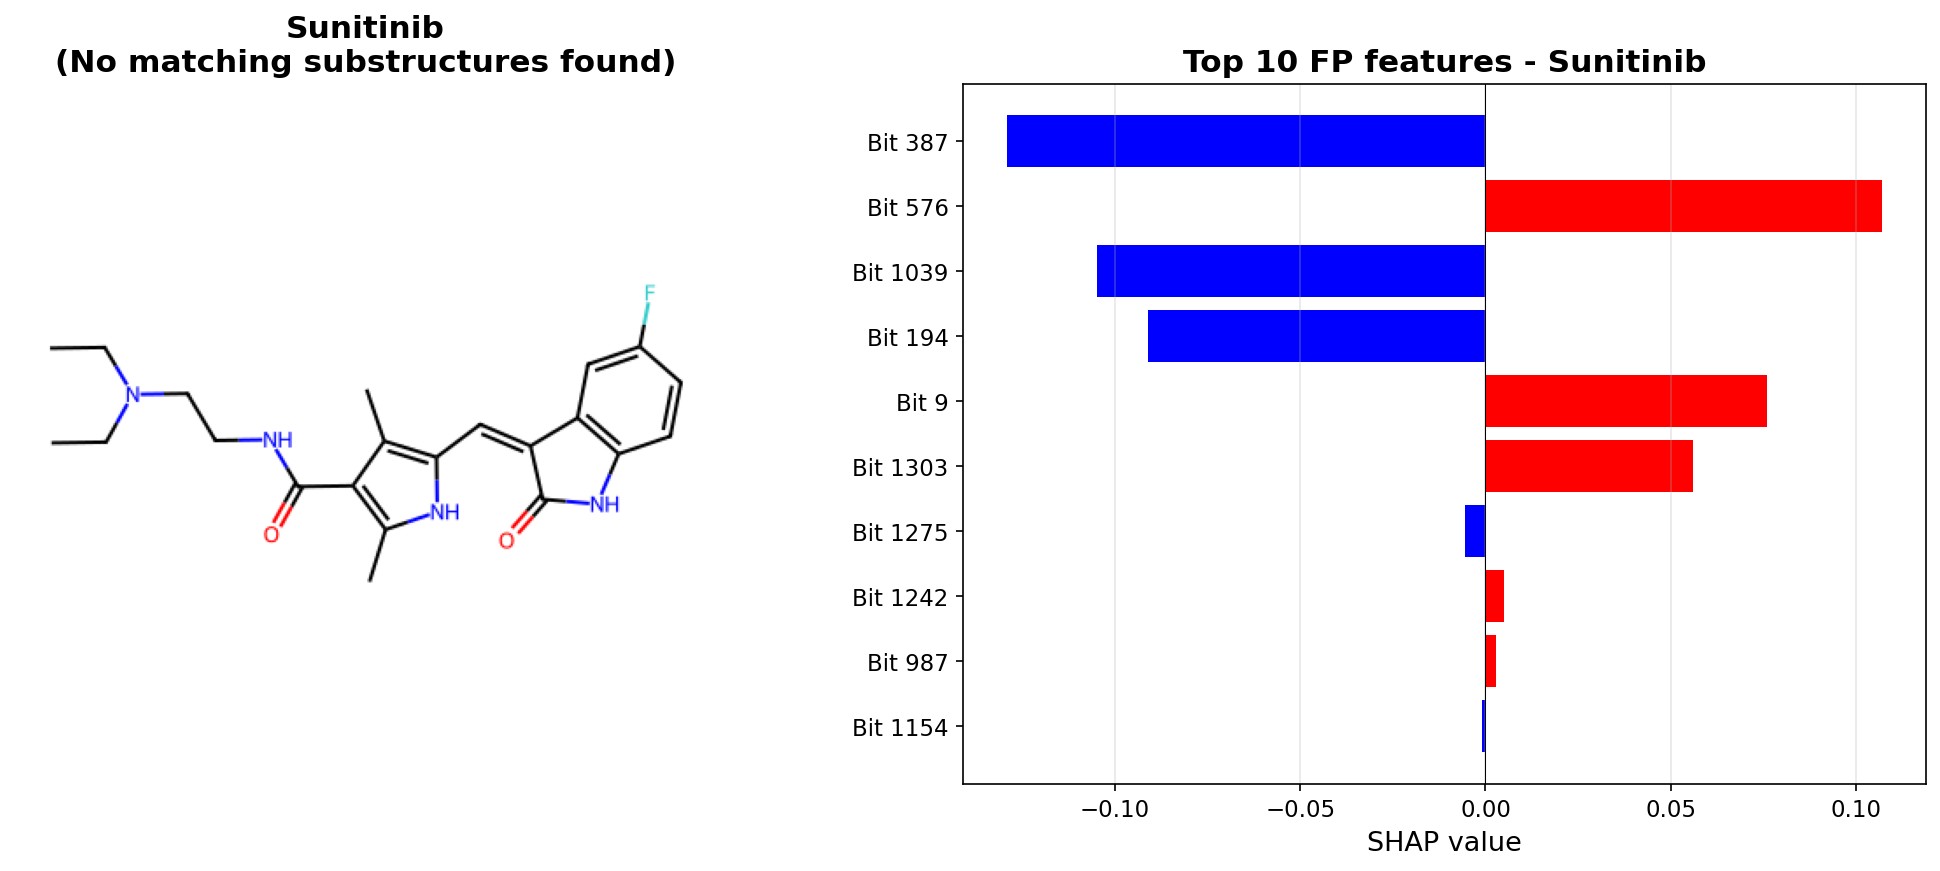


--- Leucettinib-92 ---
  Top 10 fingerprint features:
    1. Feature 693 (Bit 693): SHAP = 0.139142
    2. Feature 216 (Bit 216): SHAP = -0.109370
    3. Feature 1800 (Bit 1800): SHAP = -0.081116
    4. Feature 718 (Bit 718): SHAP = -0.027362
    5. Feature 482 (Bit 482): SHAP = 0.024189
    6. Feature 1209 (Bit 1209): SHAP = -0.023872
    7. Feature 357 (Bit 357): SHAP = -0.023108
    8. Feature 840 (Bit 840): SHAP = -0.022634
    9. Feature 1256 (Bit 1256): SHAP = -0.013467
    10. Feature 649 (Bit 649): SHAP = 0.005621


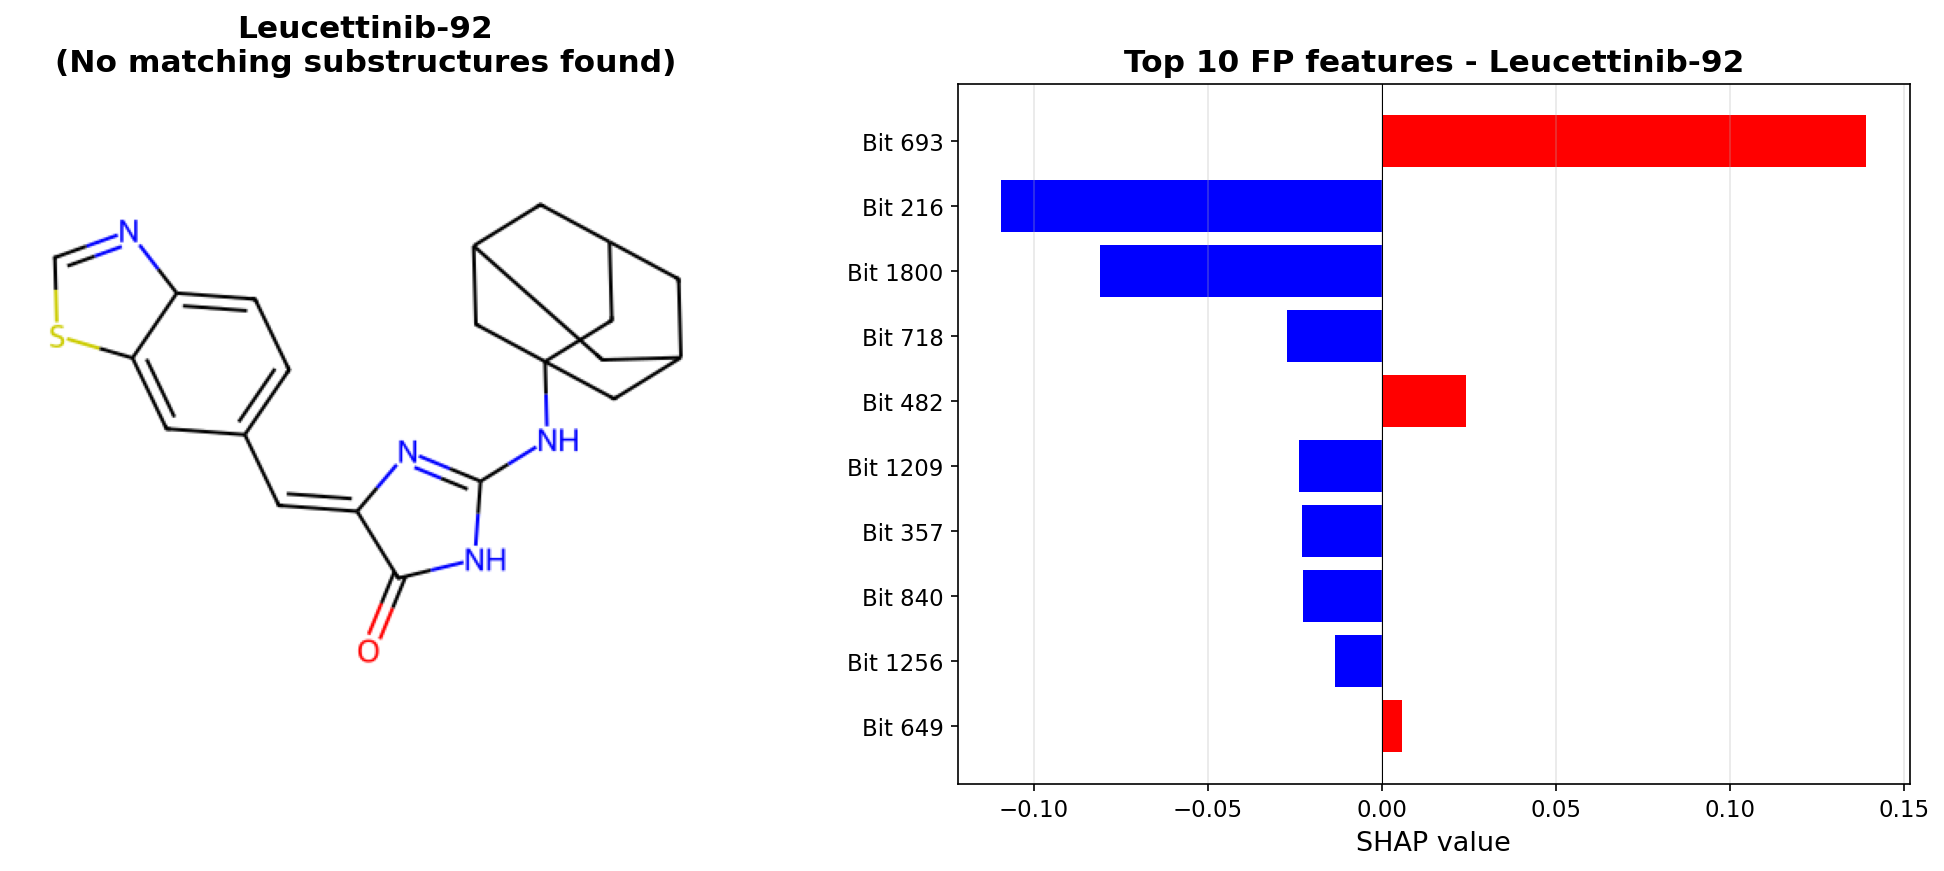


--- Silmitasertib ---
  Top 10 fingerprint features:
    1. Feature 711 (Bit 711): SHAP = -0.160147
    2. Feature 704 (Bit 704): SHAP = 0.104291
    3. Feature 2043 (Bit 2043): SHAP = -0.095117
    4. Feature 788 (Bit 788): SHAP = -0.076800
    5. Feature 1919 (Bit 1919): SHAP = 0.067556
    6. Feature 1535 (Bit 1535): SHAP = 0.044435
    7. Feature 1524 (Bit 1524): SHAP = -0.041550
    8. Feature 1452 (Bit 1452): SHAP = -0.041550
    9. Feature 554 (Bit 554): SHAP = -0.031912
    10. Feature 708 (Bit 708): SHAP = -0.008079


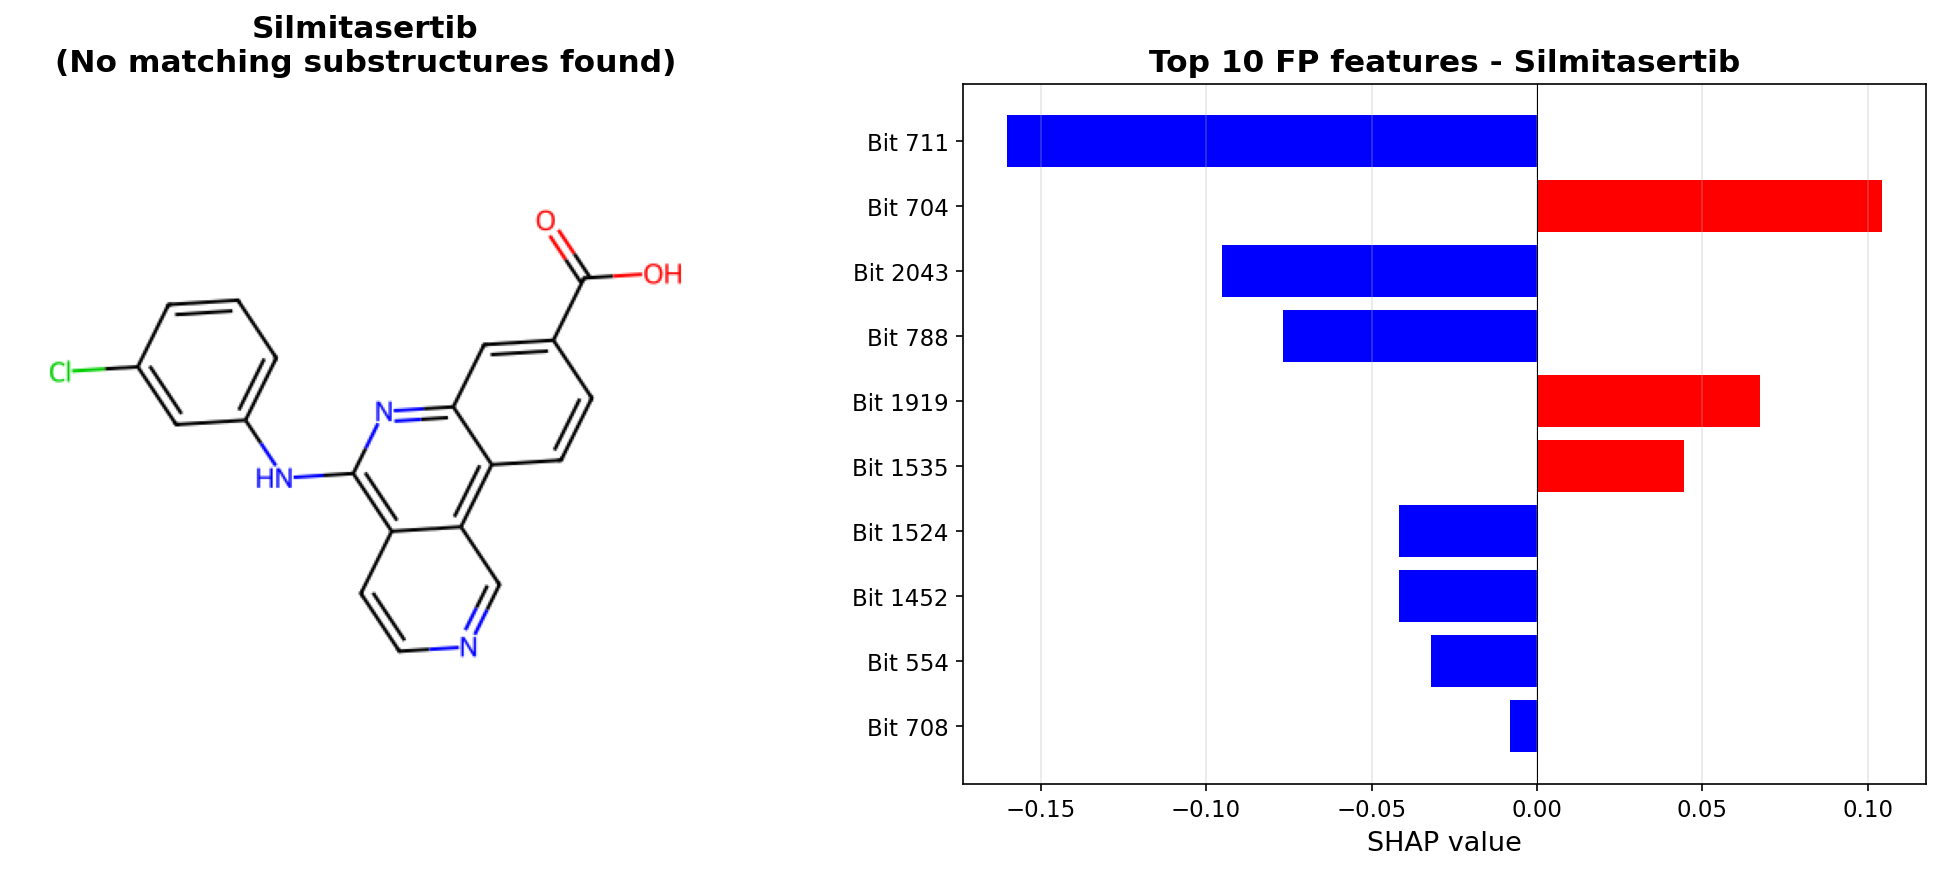


PIPELINE COMPLETED SUCCESSFULLY


In [ ]:
# ================================================================
# 9. PREDICTIONS ON TEST MOLECULES & FINGERPRINT SHAP HIGHLIGHTING
# ================================================================
print("\n" + "="*80)
print("PREDICTIONS AND EXPLAINABILITY FOR TEST MOLECULES")
print("="*80)

TEST_MOLECULES = {
    'Compound_name': [
        'Imatinib', 'Neratinib', 'Sitagliptin', 'Sunitinib',
        'Leucettinib-92', 'Dasatinib', 'Navitoclax', 'Silmitasertib'
    ],
    'ChEMBL_ID': [
        'CHEMBL941', 'CHEMBL180022', 'CHEMBL1422', 'CHEMBL535',
        'CHEMBL5091238', 'CHEMBL1421', 'CHEMBL443684', 'CHEMBL1230165'
    ],
    'Smiles': [
        'Cc1ccc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)cc1Nc1nccc(-c2cccnc2)n1',
        'CCOc1cc2ncc(C#N)c(Nc3ccc(OCc4ccccn4)c(Cl)c3)c2cc1NC(=O)/C=C/CN(C)C',
        'N[C@@H](CC(=O)N1CCn2c(nnc2C(F)(F)F)C1)Cc1cc(F)c(F)cc1F',
        'CCN(CC)CCNC(=O)c1c(C)[nH]c(/C=C2\\C(=O)Nc3ccc(F)cc32)c1C',
        r'O=C1NC(NC23CC4CC(CC(C4)C2)C3)=N/C1=C\c1ccc2ncsc2c1',
        'Cc1nc(Nc2ncc(C(=O)Nc3c(C)cccc3Cl)s2)cc(N2CCN(CCO)CC2)n1',
        'CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(N[C@H](CCN5CCOCC5)CSc5ccccc5)c(S(=O)(=O)C(F)(F)F)c4)cc3)CC2)C1',
        'O=C(O)c1ccc2c(c1)nc(Nc1cccc(Cl)c1)c1ccncc12'
    ]
}

smiles_to_idx = {smi: i for i, smi in enumerate(df['Smiles'])}
results_list = []
viz_data = []

for name, smi, chembl in zip(TEST_MOLECULES['Compound_name'],
                             TEST_MOLECULES['Smiles'],
                             TEST_MOLECULES['ChEMBL_ID']):
    if smi not in smiles_to_idx:
        print(f"✗ {name} not found in dataset")
        continue
    idx = smiles_to_idx[smi]
    Xd_raw = X_desc_raw[idx:idx+1]
    Xf_raw = X_fp_raw[idx:idx+1]

    #Ensemble predictions (combined)
    weights_comb = np.maximum(fold_aucs['comb'], 0.5)
    prob_comb = ensemble_predict(best_models['comb'],
                                 Xd_raw, Xf_raw,
                                 preprocessing_params, 'comb',
                                 weights=weights_comb)

    #Descriptor-only prediction
    prob_desc = ensemble_predict(best_models['desc'],
                                 Xd_raw, Xf_raw,
                                 preprocessing_params, 'desc',
                                 weights=np.maximum(fold_aucs['desc'], 0.5))

    #Fingerprint-only prediction
    prob_fp = ensemble_predict(best_models['fp'],
                               Xd_raw, Xf_raw,
                               preprocessing_params, 'fp',
                               weights=np.maximum(fold_aucs['fp'], 0.5))

    pred_comb = int(prob_comb > 0.5)

    results_list.append({
        'Molecule': name,
        'Combined_Prob': prob_comb.item(),
        'Combined_Pred': pred_comb,
        'Desc_Prob': prob_desc.item(),
        'FP_Prob': prob_fp.item()
    })

    print(f"  Preparing SHAP for {name}...")
    try:
        Xf_clip = np.clip(Xf_raw, f_lo, f_hi)
        Xf_sc = scaler_fp_shap.transform(Xf_clip).astype(np.float32)
        shap_single = explainer_fp.shap_values(Xf_sc, nsamples=100)
        shap_fp_values = shap_single[0]

        fp, bit_info = get_morgan_fingerprint_info(smi, radius=2, nBits=len(fp_feat_cols))
        if fp is None:
            print(f"  ✗ Failed to generate Morgan fingerprint for {name}")
            continue

        bit_indices_map = []
        for feat_name in fp_feat_cols:
            if 'Bit' in feat_name or 'bit' in feat_name:
                try:
                    bit_num = int(''.join(filter(str.isdigit, feat_name)))
                    bit_indices_map.append(bit_num)
                except:
                    bit_indices_map.append(len(bit_indices_map))
            else:
                bit_indices_map.append(len(bit_indices_map))

        top_feature_indices = np.argsort(np.abs(shap_fp_values))[::-1][:10]
        top_bit_positions = [bit_indices_map[i] for i in top_feature_indices]


        viz_data.append({
            'name': name,
            'smi': smi,
            'shap_fp_values': shap_fp_values,
            'top_feature_indices': top_feature_indices,
            'top_bit_positions': top_bit_positions,
            'bit_info': bit_info,
            'valid_highlight_bits': [b for b in top_bit_positions[:5] if b in bit_info]
        })
    except Exception as e:
        print(f"  ✗ Error during SHAP preparation for {name}: {e}")
        import traceback
        traceback.print_exc()

print("\n" + "="*80)
print("SUMMARY OF PREDICTIONS FOR ALL TEST MOLECULES")
print("="*80)
pred_df = pd.DataFrame(results_list)
print(pred_df.to_string(index=False))
pred_df.to_csv(os.path.join(SAVE_DIR, 'test_molecules_predictions.csv'), index=False)
print(f"\n✓ Predictions saved to: {os.path.join(SAVE_DIR, 'test_molecules_predictions.csv')}")

print("\n" + "="*80)
print("GENERATING SHAP VISUALISATIONS FOR ALL TEST MOLECULES")
print("="*80)

for data in viz_data:
    name = data['name']
    smi = data['smi']
    shap_fp_values = data['shap_fp_values']
    top_feature_indices = data['top_feature_indices']
    top_bit_positions = data['top_bit_positions']
    bit_info = data['bit_info']
    valid_highlight_bits = data['valid_highlight_bits']

    print(f"\n--- {name} ---")
    print("  Top 10 fingerprint features:")
    for rank, (feat_idx, bit_pos) in enumerate(zip(top_feature_indices, top_bit_positions), 1):
        print(f"    {rank}. Feature {feat_idx} (Bit {bit_pos}): SHAP = {shap_fp_values[feat_idx]:.6f}")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    if len(valid_highlight_bits) > 0:
        highlighted_img = highlight_atoms_and_bonds(smi, valid_highlight_bits, bit_info, top_n=len(valid_highlight_bits))
        if highlighted_img:
            ax1.imshow(highlighted_img)
            ax1.axis('off')
            ax1.set_title(f'{name}\n(Highlighted by top FP features)', fontweight='bold')
        else:
            ax1.text(0.5, 0.5, 'Could not render molecule', ha='center', va='center')
            ax1.axis('off')
    else:
        mol = Chem.MolFromSmiles(smi)
        if mol:
            img = Draw.MolToImage(mol, size=(400, 400))
            ax1.imshow(img)
            ax1.axis('off')
            ax1.set_title(f'{name}\n(No matching substructures found)', fontweight='bold')
        else:
            ax1.text(0.5, 0.5, 'Could not render molecule', ha='center', va='center')
            ax1.axis('off')

    colors = ['red' if val > 0 else 'blue' for val in shap_fp_values[top_feature_indices]]
    ax2.barh(range(len(top_feature_indices)), shap_fp_values[top_feature_indices], color=colors)
    ax2.set_yticks(range(len(top_feature_indices)))
    ax2.set_yticklabels([f'Bit {bit_pos}' for bit_pos in top_bit_positions])
    ax2.set_xlabel('SHAP value')
    ax2.set_title(f'Top 10 FP features - {name}', fontweight='bold')
    ax2.axvline(0, color='black', lw=0.5)
    ax2.grid(axis='x', alpha=0.3)
    ax2.invert_yaxis()

    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f'explain_{name.replace(" ", "_")}.png'), dpi=150, bbox_inches='tight')
    plt.show()

print("\n" + "="*80)
print("PIPELINE COMPLETED SUCCESSFULLY")
print("="*80)


GENERATING PER-MOLECULE SHAP FINGERPRINT PANELS

  Imatinib
    1. Morgan  1855  SHAP=+0.07046  (activating)
    2. Morgan  1057  SHAP=-0.00425  (suppressing)
    3. Morgan    14  SHAP=+0.00000  (activating)


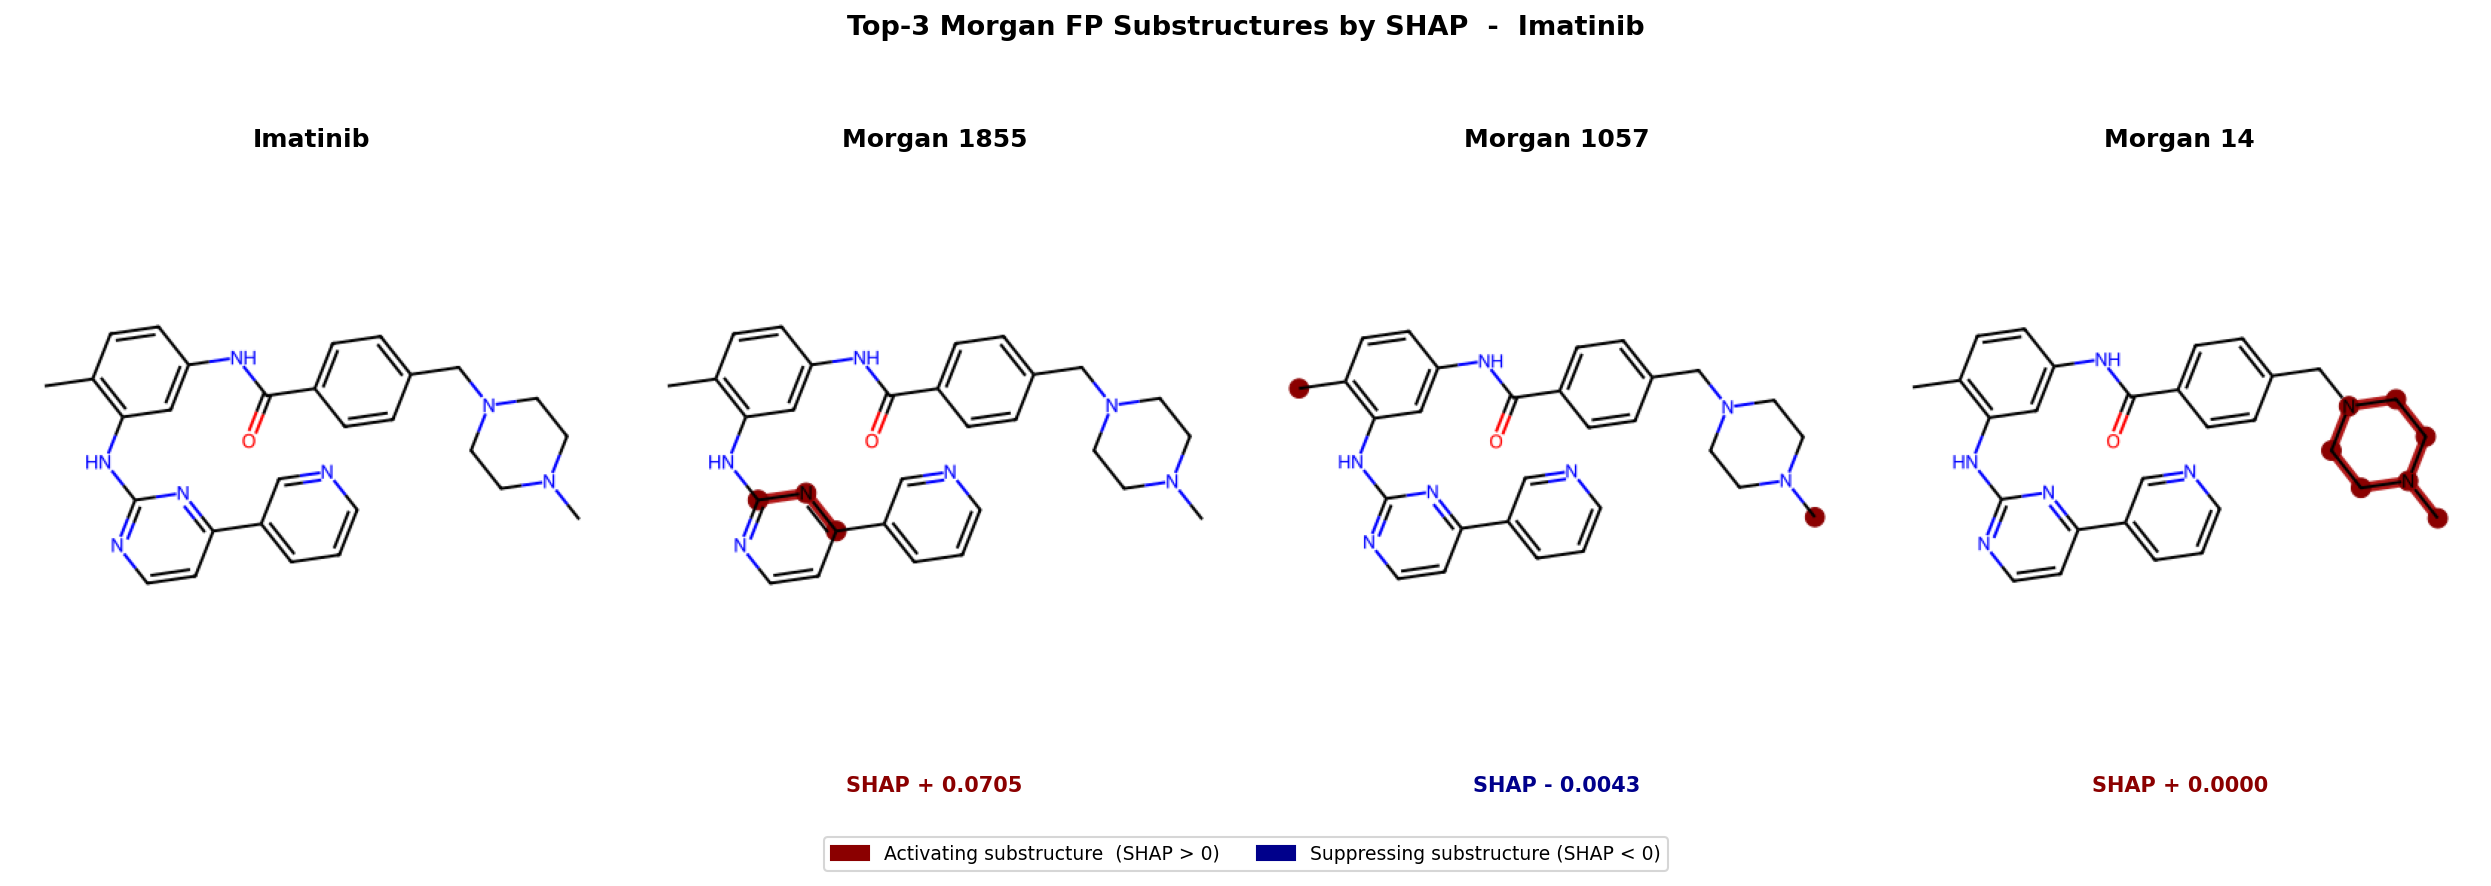

    Saved: /content/drive/MyDrive/models_new/shap_mol_Imatinib.png

  Neratinib
    1. Morgan   172  SHAP=-0.03795  (suppressing)
    2. Morgan    31  SHAP=+0.00000  (activating)
    3. Morgan    80  SHAP=+0.00000  (activating)


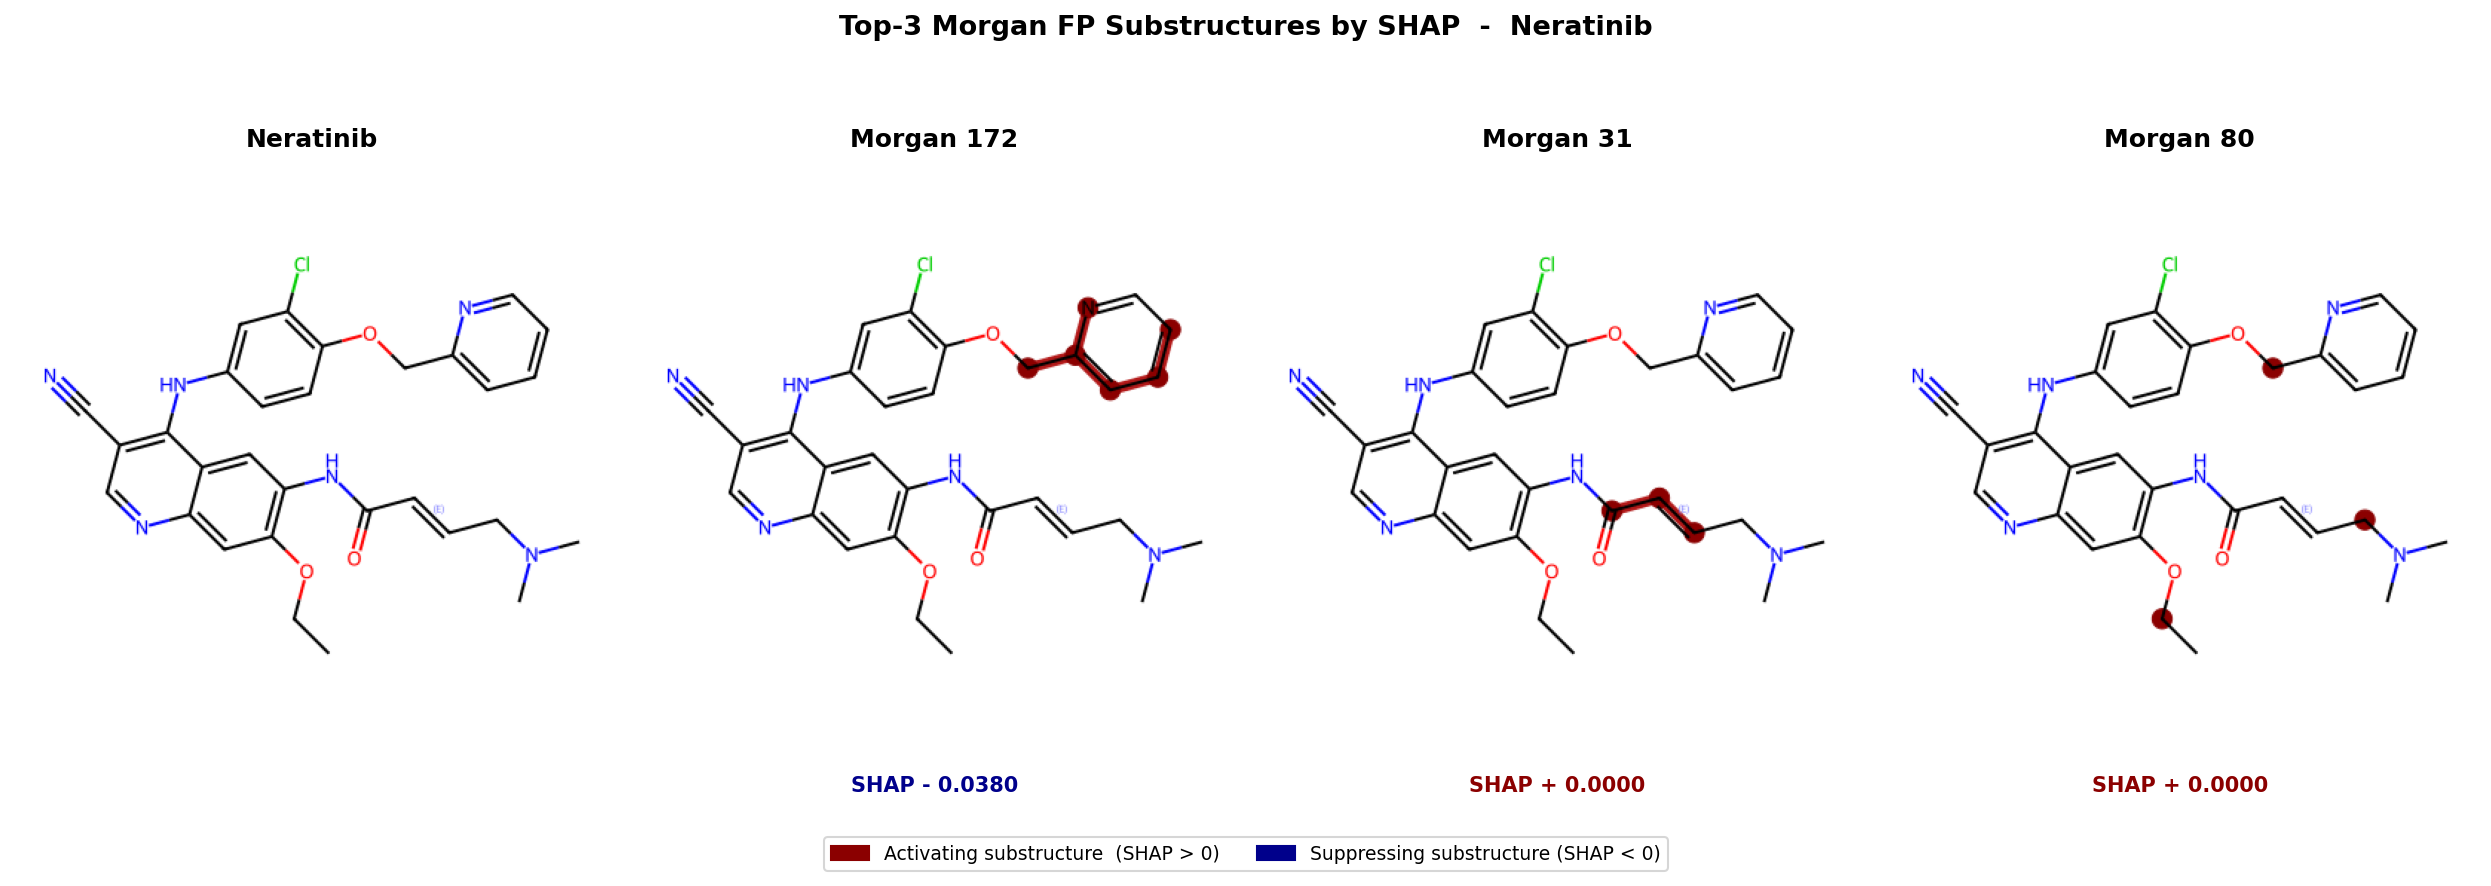

    Saved: /content/drive/MyDrive/models_new/shap_mol_Neratinib.png

  Sitagliptin
    1. Morgan     1  SHAP=+0.00000  (activating)
    2. Morgan    79  SHAP=+0.00000  (activating)
    3. Morgan    80  SHAP=+0.00000  (activating)


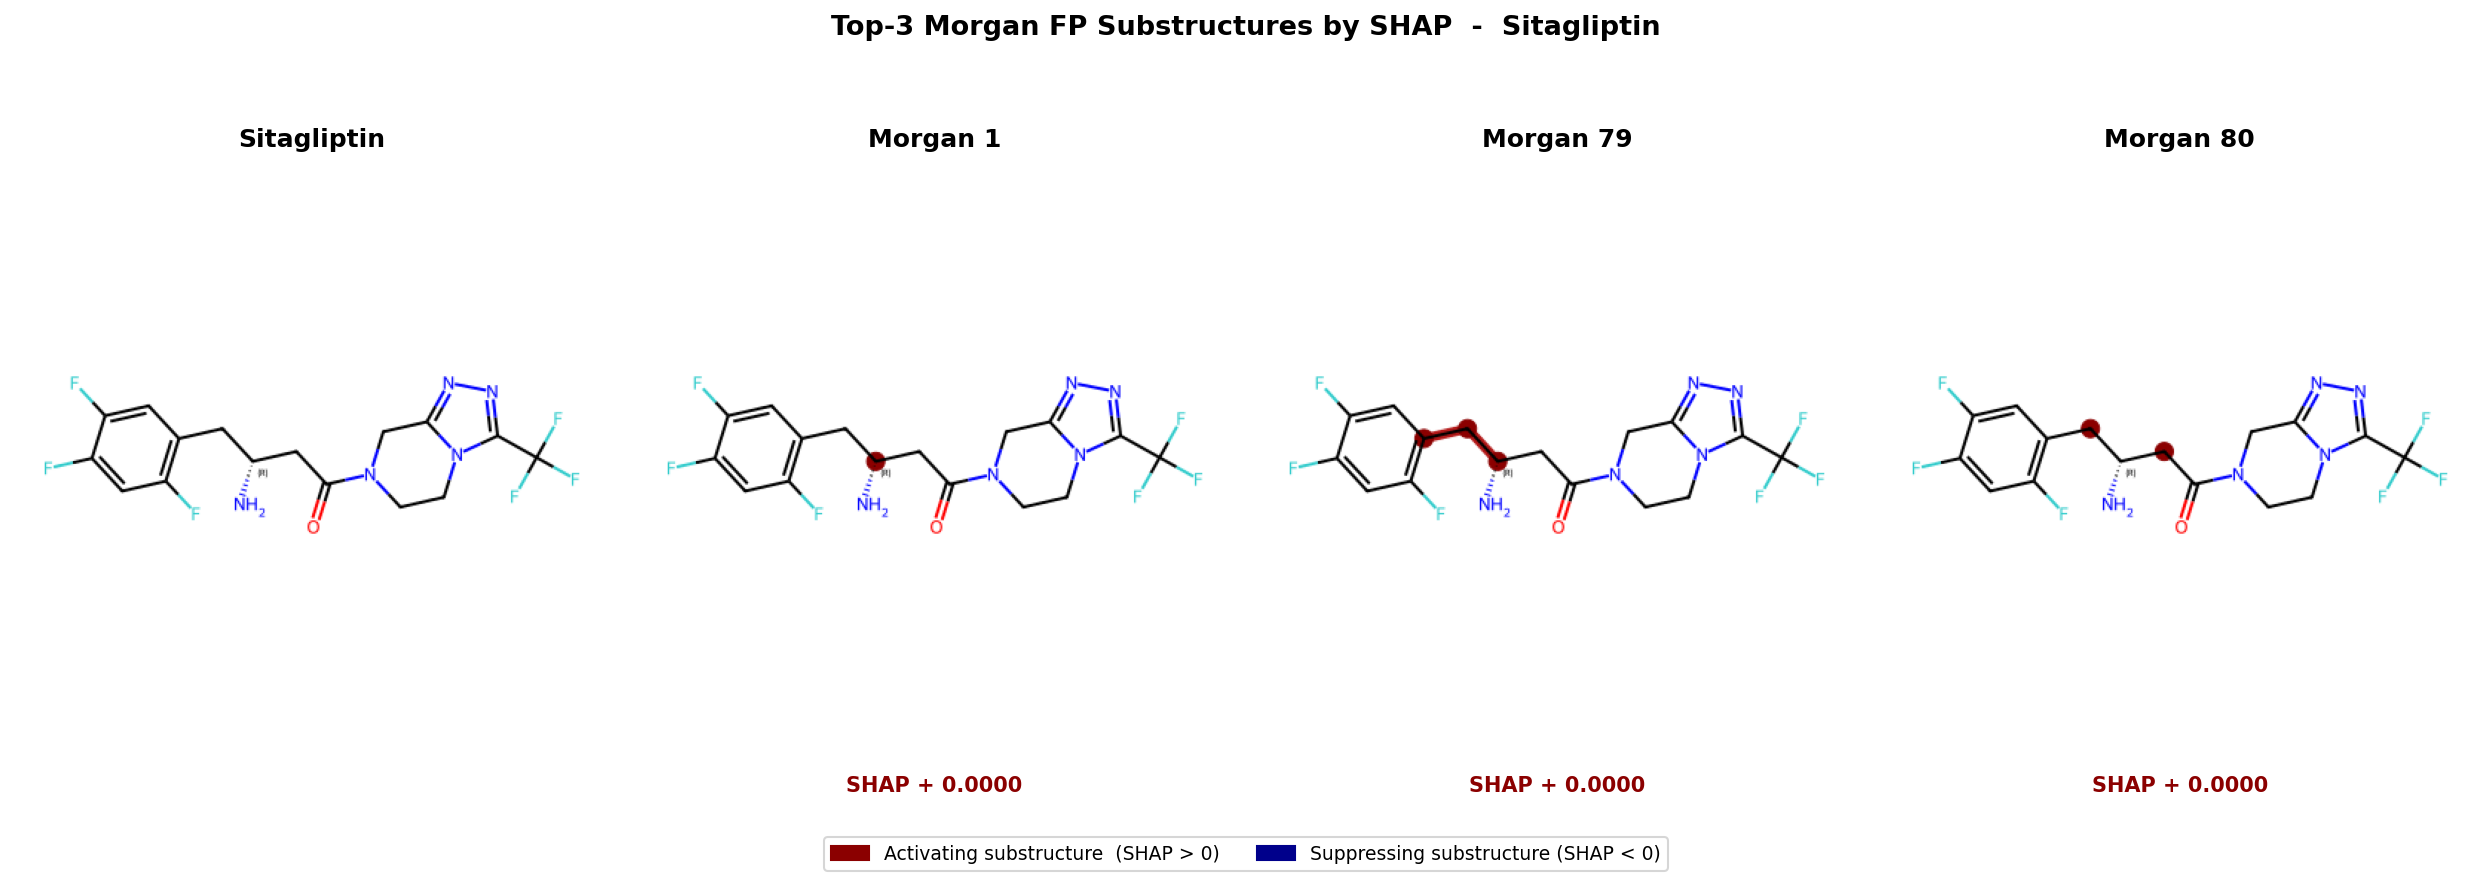

    Saved: /content/drive/MyDrive/models_new/shap_mol_Sitagliptin.png

  Sunitinib
    1. Morgan     8  SHAP=+0.00000  (activating)
    2. Morgan    74  SHAP=+0.00000  (activating)
    3. Morgan    80  SHAP=+0.00000  (activating)


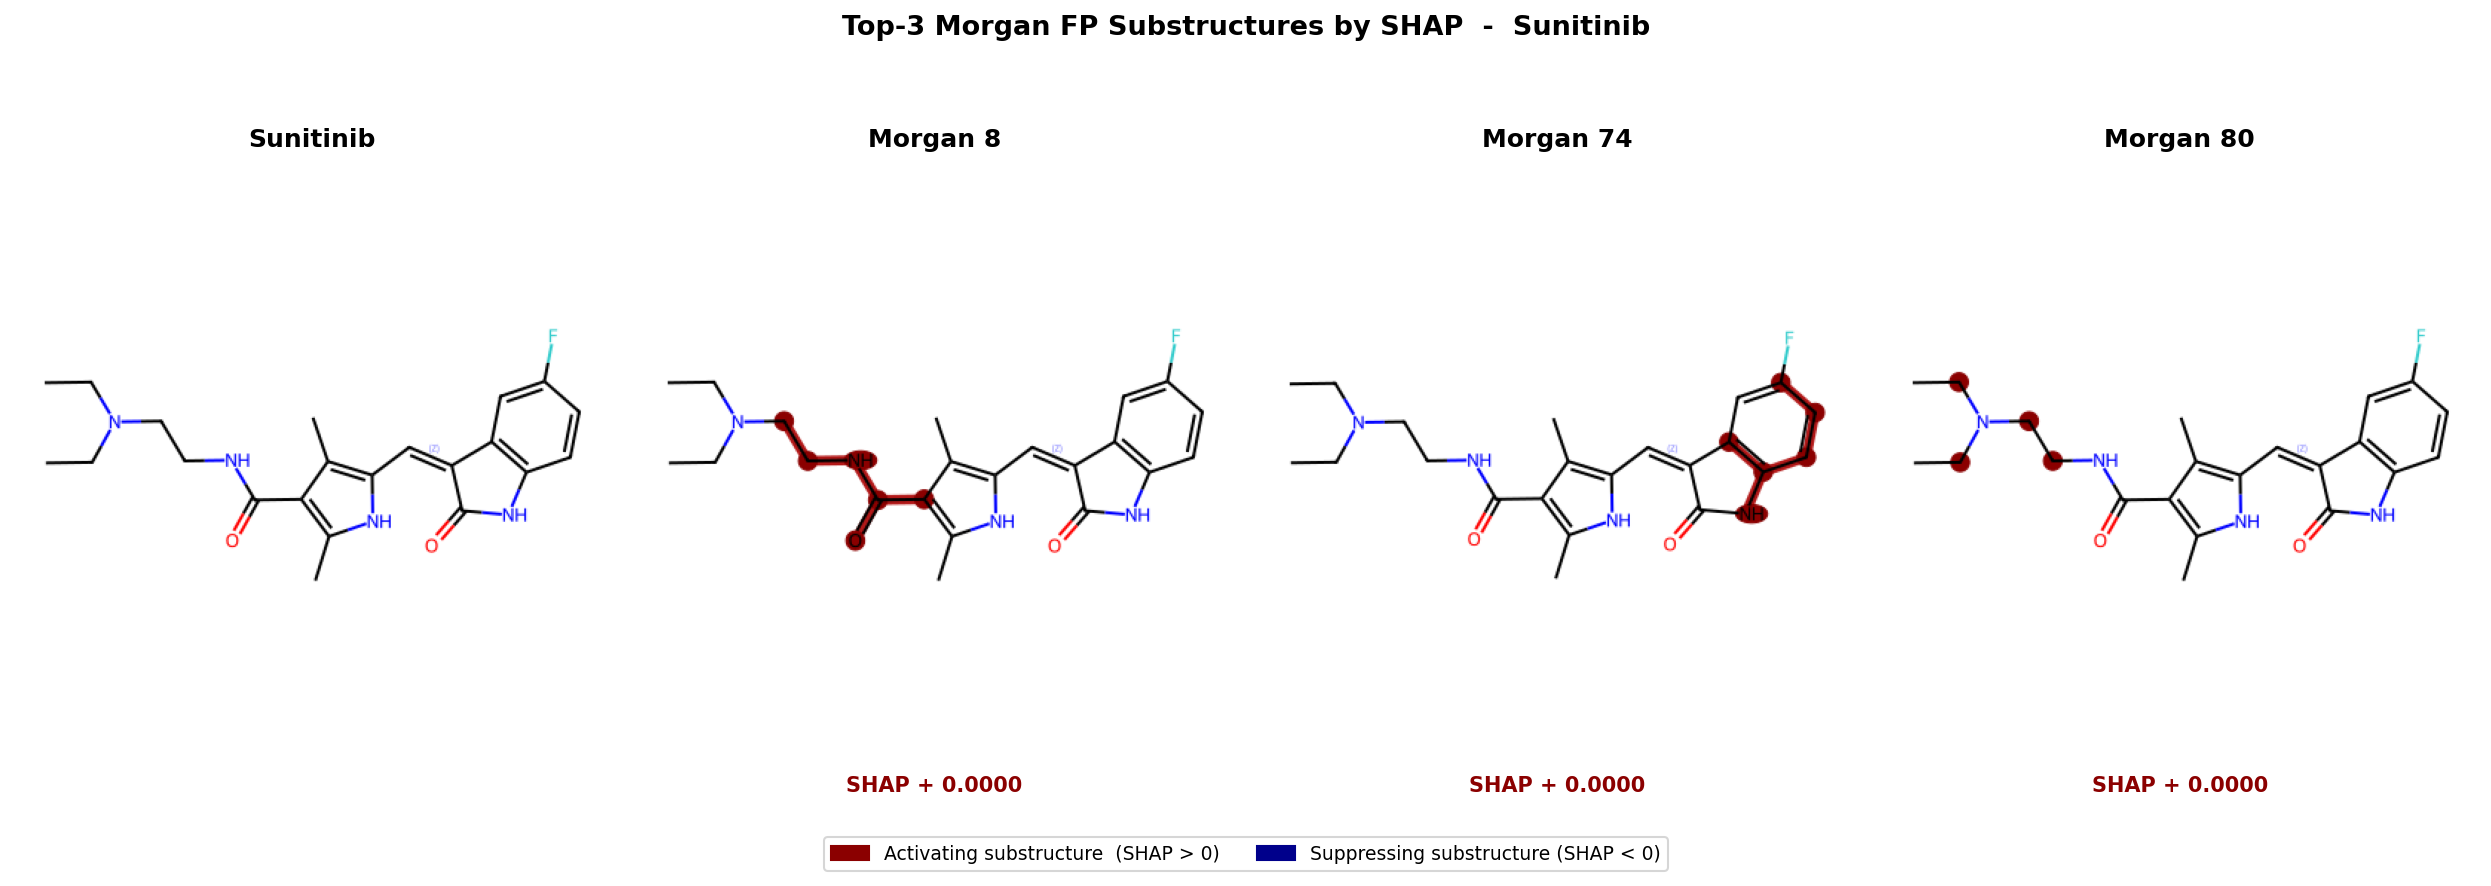

    Saved: /content/drive/MyDrive/models_new/shap_mol_Sunitinib.png

  Leucettinib-92
    1. Morgan   357  SHAP=-0.02311  (suppressing)
    2. Morgan    25  SHAP=+0.00000  (activating)
    3. Morgan    50  SHAP=+0.00000  (activating)


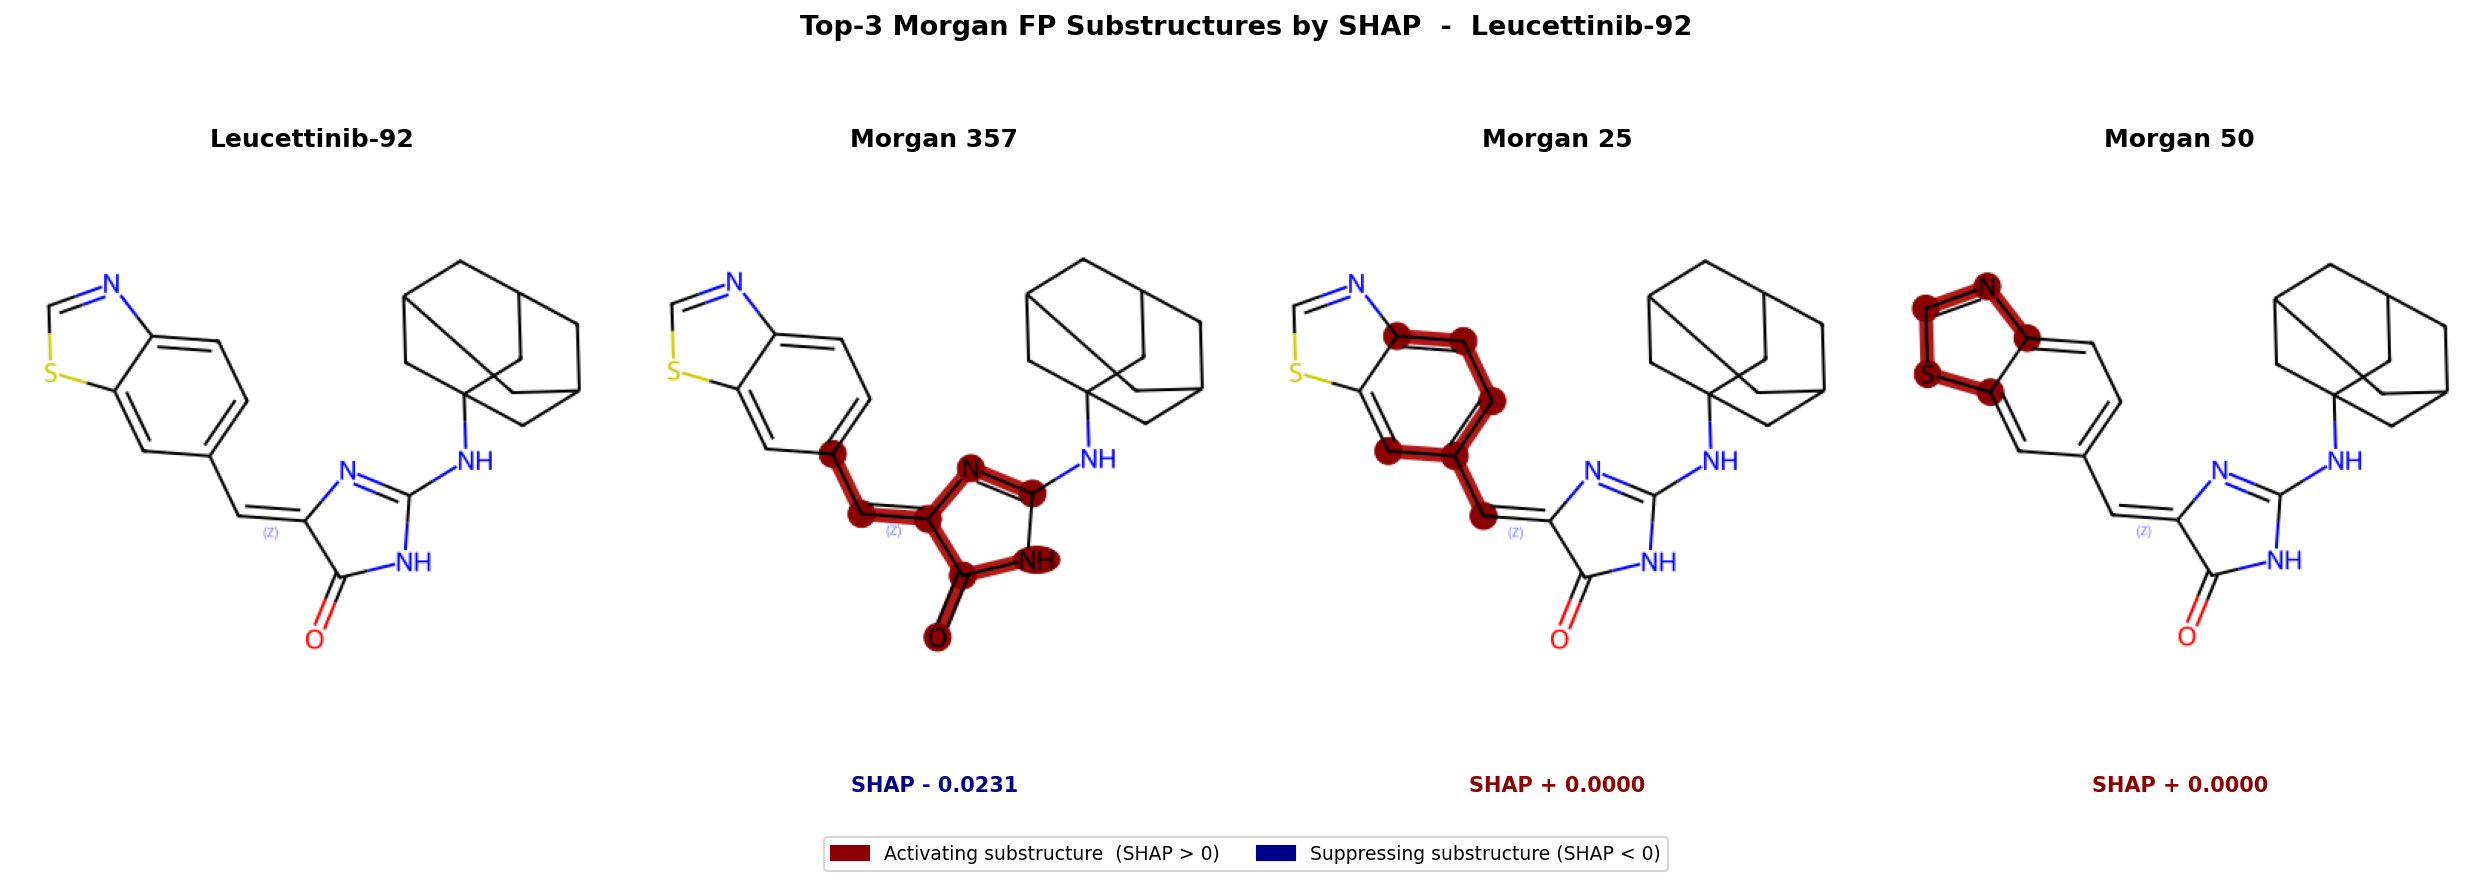

    Saved: /content/drive/MyDrive/models_new/shap_mol_Leucettinib-92.png

  Silmitasertib
    1. Morgan  1535  SHAP=+0.04444  (activating)
    2. Morgan   708  SHAP=-0.00808  (suppressing)
    3. Morgan    72  SHAP=+0.00000  (activating)


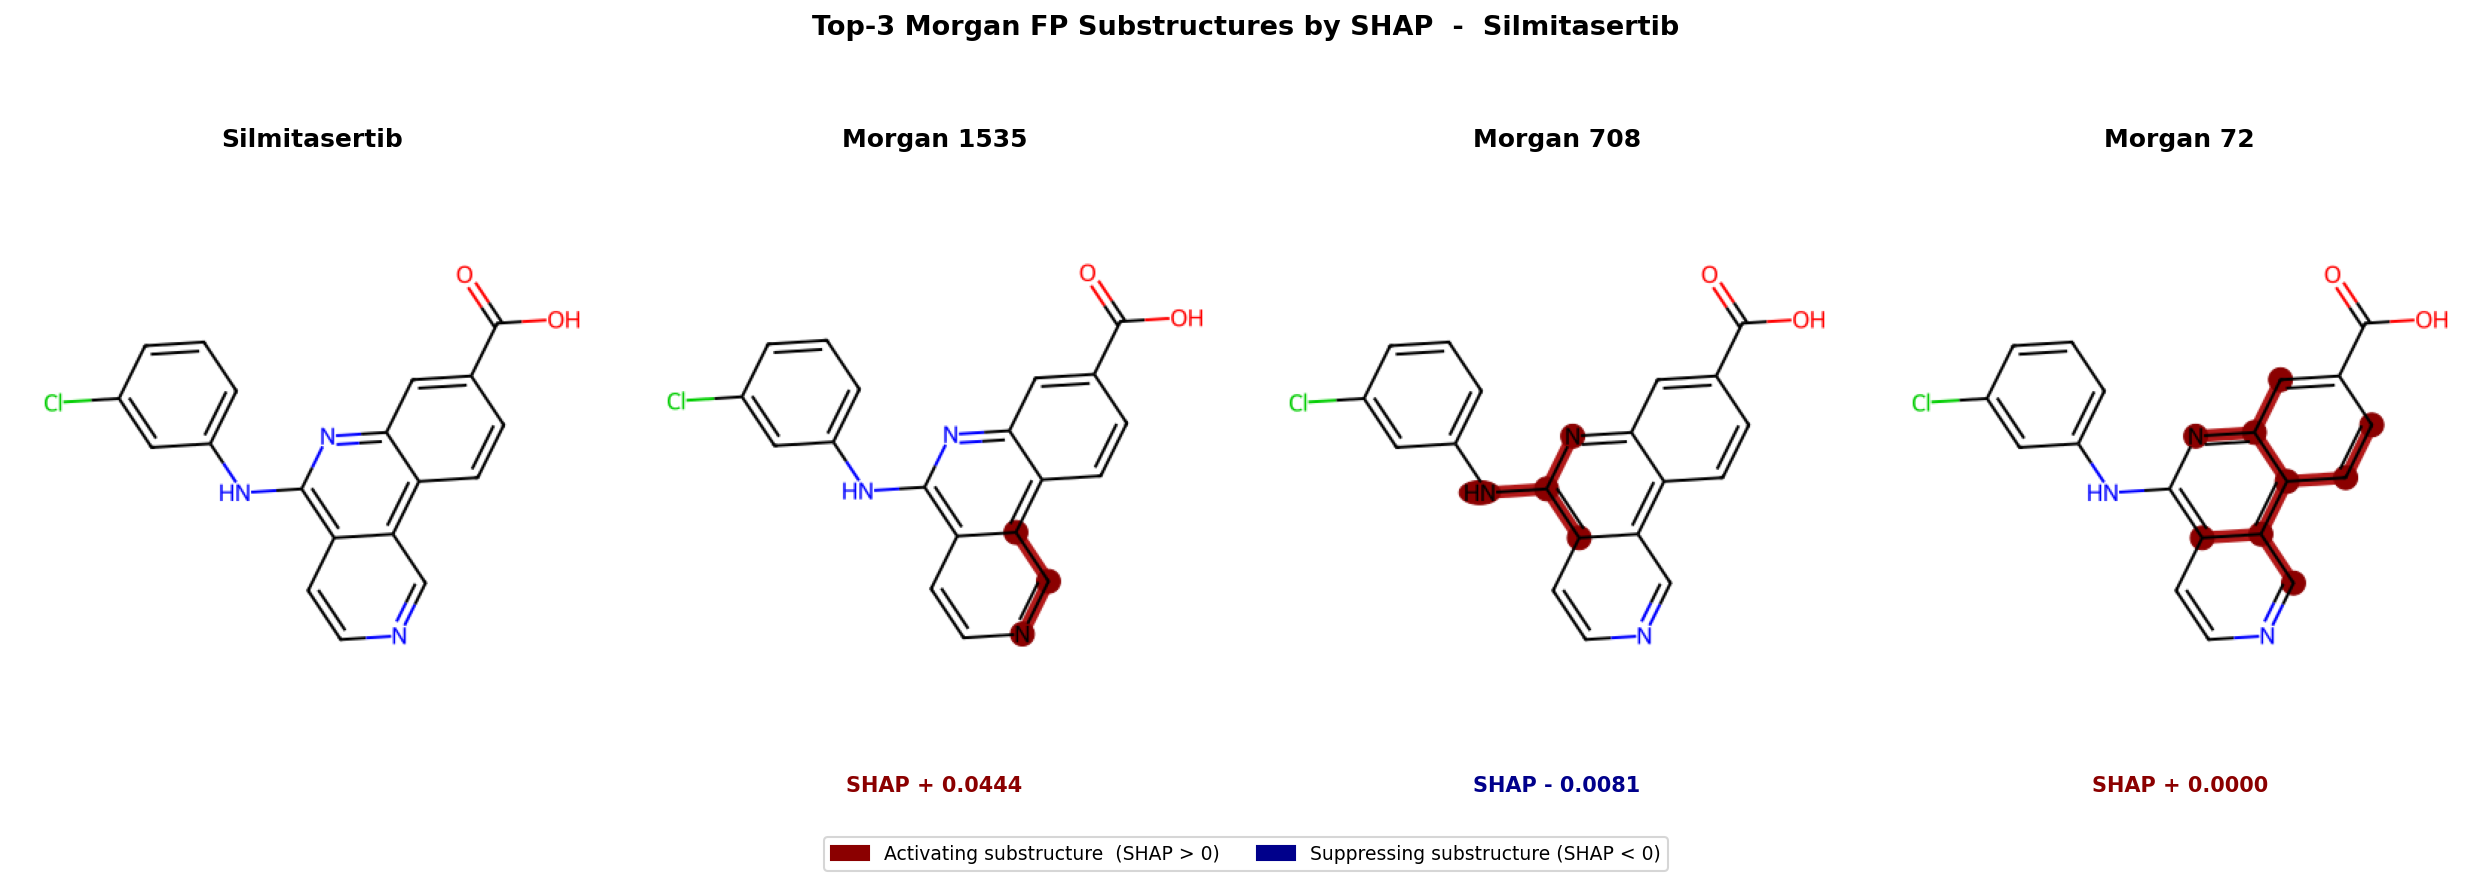

    Saved: /content/drive/MyDrive/models_new/shap_mol_Silmitasertib.png

ALL PER-MOLECULE SHAP PANELS COMPLETE


In [ ]:
# ================================================================
# 10. PER-MOLECULE SHAP FINGERPRINT PANEL
# ================================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from io import BytesIO
from PIL import Image

from rdkit import Chem
from rdkit.Chem import AllChem, Draw
from rdkit.Chem.Draw import rdMolDraw2D

HIGHLIGHT_COLOR = (0.545, 0.0, 0.0)
BOND_COLOR      = (0.700, 0.1, 0.1)
IMG_SIZE        = 400


def _bit_number_from_name(feat_name, fallback):
    digits = "".join(c for c in feat_name if c.isdigit())
    return int(digits) if digits else fallback


def _render_mol(smiles, highlight_atoms=(), highlight_bonds=(), size=IMG_SIZE):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    AllChem.Compute2DCoords(mol)

    try:
        drawer = rdMolDraw2D.MolDraw2DCairo(size, size)
    except AttributeError:
        drawer = rdMolDraw2D.MolDraw2DSVG(size, size)

    opts = drawer.drawOptions()
    opts.addStereoAnnotation = True
    opts.addAtomIndices      = False

    atom_set = set(highlight_atoms)
    bond_set = set(highlight_bonds)

    drawer.DrawMolecule(
        mol,
        highlightAtoms=list(atom_set),
        highlightBonds=list(bond_set),
        highlightAtomColors={a: HIGHLIGHT_COLOR for a in atom_set},
        highlightBondColors={b: BOND_COLOR      for b in bond_set},
    )
    drawer.FinishDrawing()
    raw = drawer.GetDrawingText()
    try:
        return Image.open(BytesIO(raw)).convert("RGBA")
    except Exception:
        return None


def _atoms_and_bonds_for_bit(mol, bit_info, bit_num):
    atom_set = set()
    bond_set = set()
    if bit_num not in bit_info:
        return atom_set, bond_set
    for center_atom, radius in bit_info[bit_num]:
        atom_set.add(center_atom)
        env = Chem.FindAtomEnvironmentOfRadiusN(mol, radius, center_atom)
        for bond_idx in env:
            b = mol.GetBondWithIdx(bond_idx)
            atom_set.add(b.GetBeginAtomIdx())
            atom_set.add(b.GetEndAtomIdx())
            bond_set.add(bond_idx)
    return atom_set, bond_set


print("GENERATING PER-MOLECULE SHAP FINGERPRINT PANELS")
print("="*70)

for mol_data in viz_data:
    name      = mol_data["name"]
    smiles    = mol_data["smi"]
    shap_vals = mol_data["shap_fp_values"]
    bit_info  = mol_data["bit_info"]

    candidates = []
    for feat_idx, feat_name in enumerate(fp_feat_cols):
        bit_num = _bit_number_from_name(feat_name, feat_idx)
        if bit_num in bit_info:
            candidates.append((feat_idx, bit_num, shap_vals[feat_idx]))

    if not candidates:
        print(f"  X {name}: no active FP bits found - skipping")
        continue

    candidates.sort(key=lambda x: abs(x[2]), reverse=True)
    top3 = candidates[:3]

    print(f"\n  {name}")
    for rank, (fi, bn, sv) in enumerate(top3, 1):
        direction = "activating" if sv >= 0 else "suppressing"
        print(f"    {rank}. Morgan {bn:>5d}  SHAP={sv:+.5f}  ({direction})")

    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        print(f"  X {name}: invalid SMILES")
        continue
    AllChem.Compute2DCoords(mol)

    panel_imgs   = [_render_mol(smiles)]
    panel_titles = [name]
    panel_shap   = [None]

    for feat_idx, bit_num, sv in top3:
        a_set, b_set = _atoms_and_bonds_for_bit(mol, bit_info, bit_num)
        img = _render_mol(smiles, highlight_atoms=a_set, highlight_bonds=b_set)
        panel_imgs.append(img)
        panel_titles.append(f"Morgan {bit_num}")
        panel_shap.append(sv)

    n_panels = len(panel_imgs)
    fig, axes = plt.subplots(1, n_panels,
                             figsize=(4.2 * n_panels, 5.2),
                             facecolor="white")
    if n_panels == 1:
        axes = [axes]

    for ax, img, title, sv in zip(axes, panel_imgs, panel_titles, panel_shap):
        if img is not None:
            ax.imshow(img)
        else:
            ax.text(0.5, 0.5, "N/A", ha="center", va="center",
                    transform=ax.transAxes, fontsize=14)
        ax.axis("off")
        ax.set_title(title, fontsize=12, fontweight="bold", pad=6)

        if sv is not None:
            colour = "#8B0000" if sv >= 0 else "#00008B"
            arrow  = "+" if sv >= 0 else "-"
            ax.text(0.5, -0.04,
                    f"SHAP {arrow} {abs(sv):.4f}",
                    transform=ax.transAxes,
                    ha="center", va="top",
                    fontsize=10, color=colour, fontweight="bold")

    legend_handles = [
        mpatches.Patch(color="#8B0000", label="Activating substructure  (SHAP > 0)"),
        mpatches.Patch(color="#00008B", label="Suppressing substructure (SHAP < 0)"),
    ]
    fig.legend(handles=legend_handles, loc="lower center", ncol=2,
               fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.08))

    plt.suptitle(f"Top-3 Morgan FP Substructures by SHAP  -  {name}",
                 fontsize=13, fontweight="bold", y=1.03)
    plt.tight_layout()

    fname = os.path.join(SAVE_DIR, f"shap_mol_{name.replace(' ', '_')}.png")
    plt.savefig(fname, dpi=200, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"    Saved: {fname}")

print("\n" + "="*70)
print("ALL PER-MOLECULE SHAP PANELS COMPLETE")
print("="*70)



SHAP – EXTERNAL TEST MOLECULES  (Hardcoded)

[1/6] Computing RDKit descriptors and Morgan fingerprints …
  ✓ Imatinib
  ✓ Neratinib
  ✓ Sitagliptin
  ✓ Sunitinib
  ✓ Leucettinib-92
  ✓ Silmitasertib

  Processed 6 molecules | desc shape: (6, 217) | fp shape: (6, 2048)

[2/6] Preprocessing with fold-0 scalers …

[3/6] Generating ensemble predictions …
      Molecule  Desc_Prob  Desc_Pred  FP_Prob  FP_Pred  Comb_Prob  Comb_Pred
      Imatinib     0.9941          1   0.4201        0     0.4419          0
     Neratinib     0.9221          1   0.0279        0     0.0306          0
   Sitagliptin     0.9416          1   0.9800        1     0.9817          1
     Sunitinib     0.9627          1   0.4397        0     0.4666          0
Leucettinib-92     0.9958          1   0.5870        1     0.5901          1
 Silmitasertib     0.9981          1   0.4428        0     0.6202          1

  Class-1 predictions: 3 / 6 molecules
  Retained for SHAP: ['Sitagliptin', 'Leucettinib-92', 'Silmitasert

  0%|          | 0/3 [00:00<?, ?it/s]

  Descriptor Model: 28 active features / 217


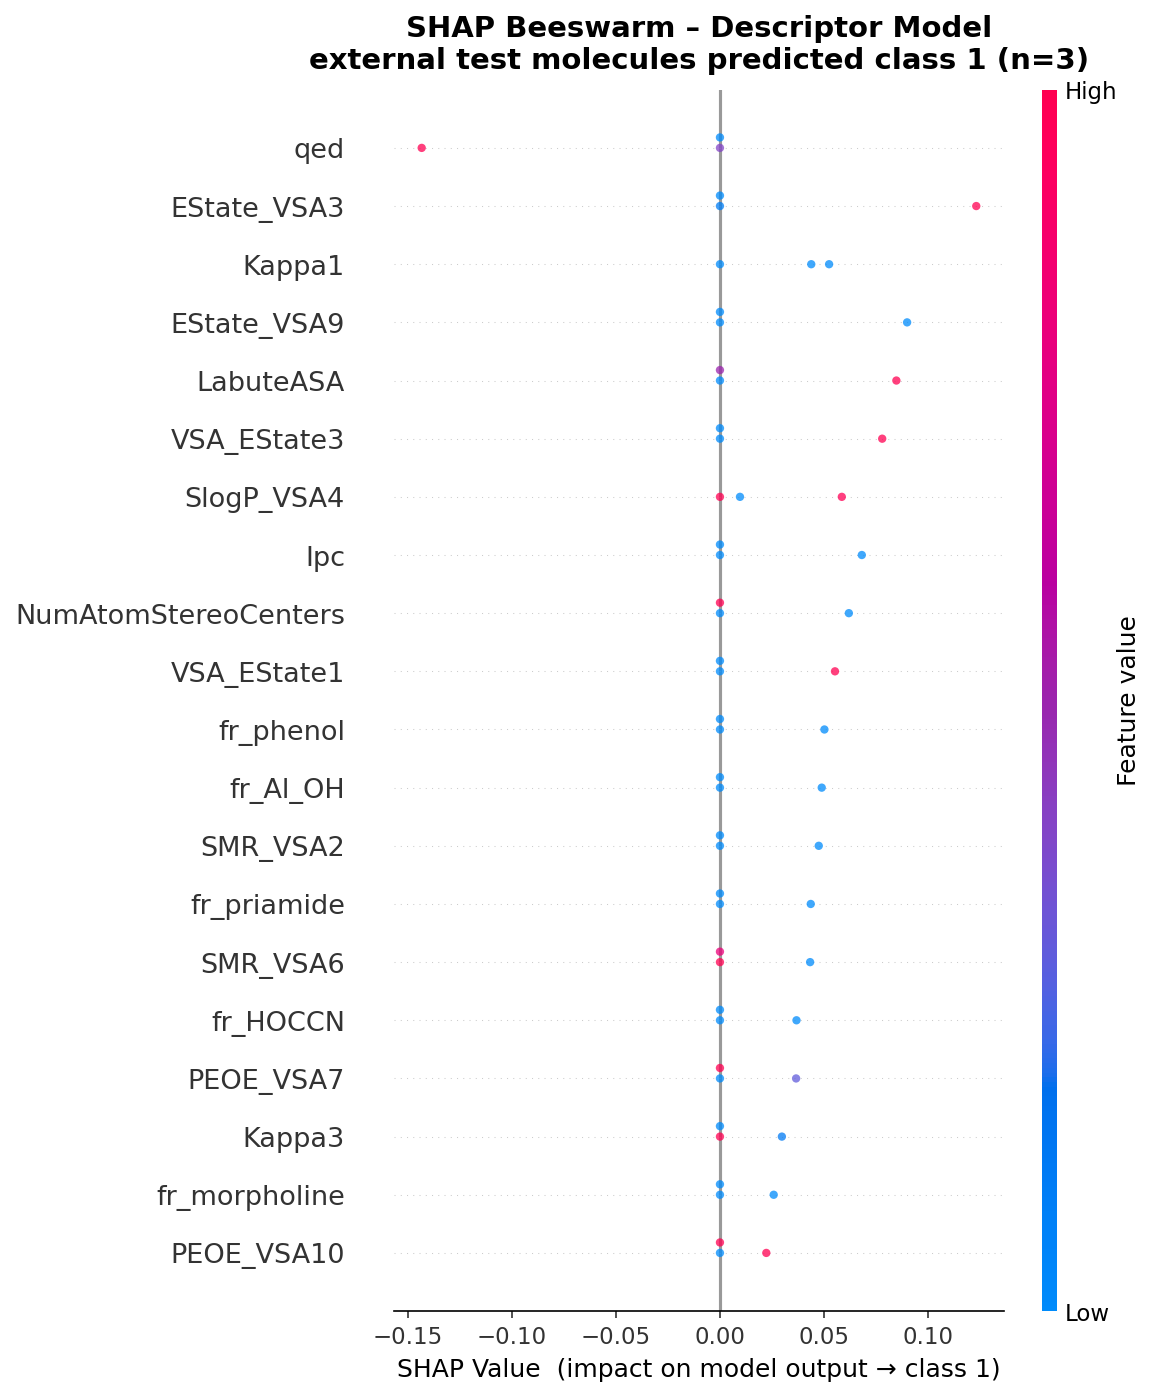

    Saved: /content/drive/MyDrive/models_new/shap_desc_ext_beeswarm.png


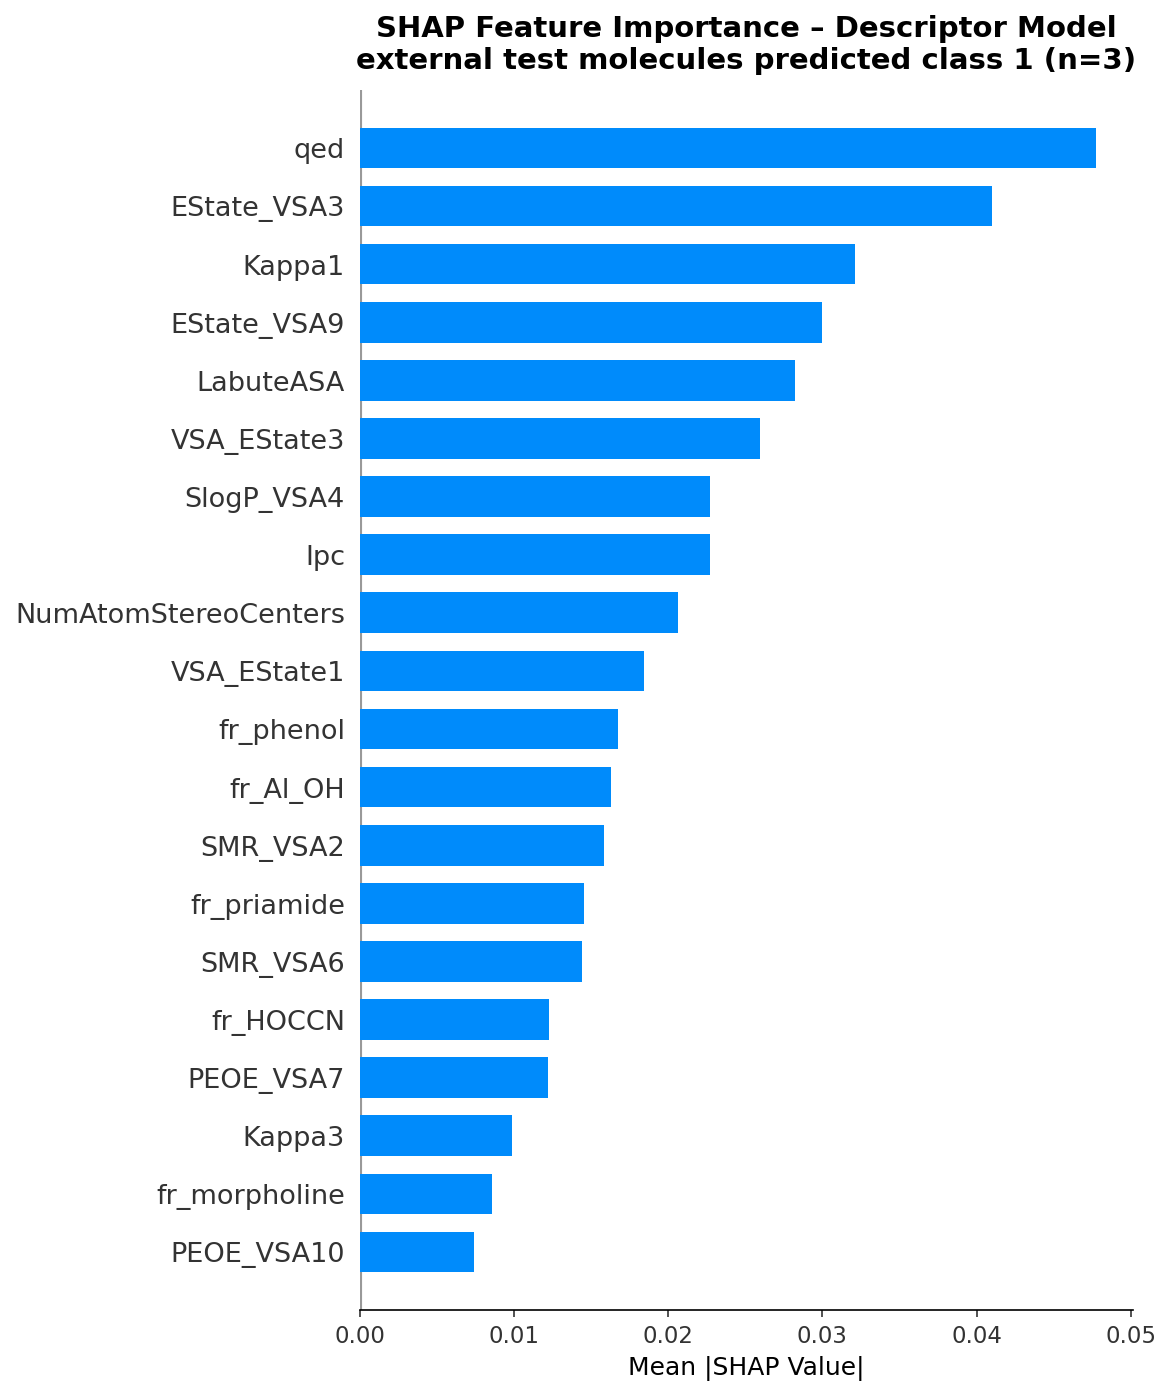

    Saved: /content/drive/MyDrive/models_new/shap_desc_ext_bar.png


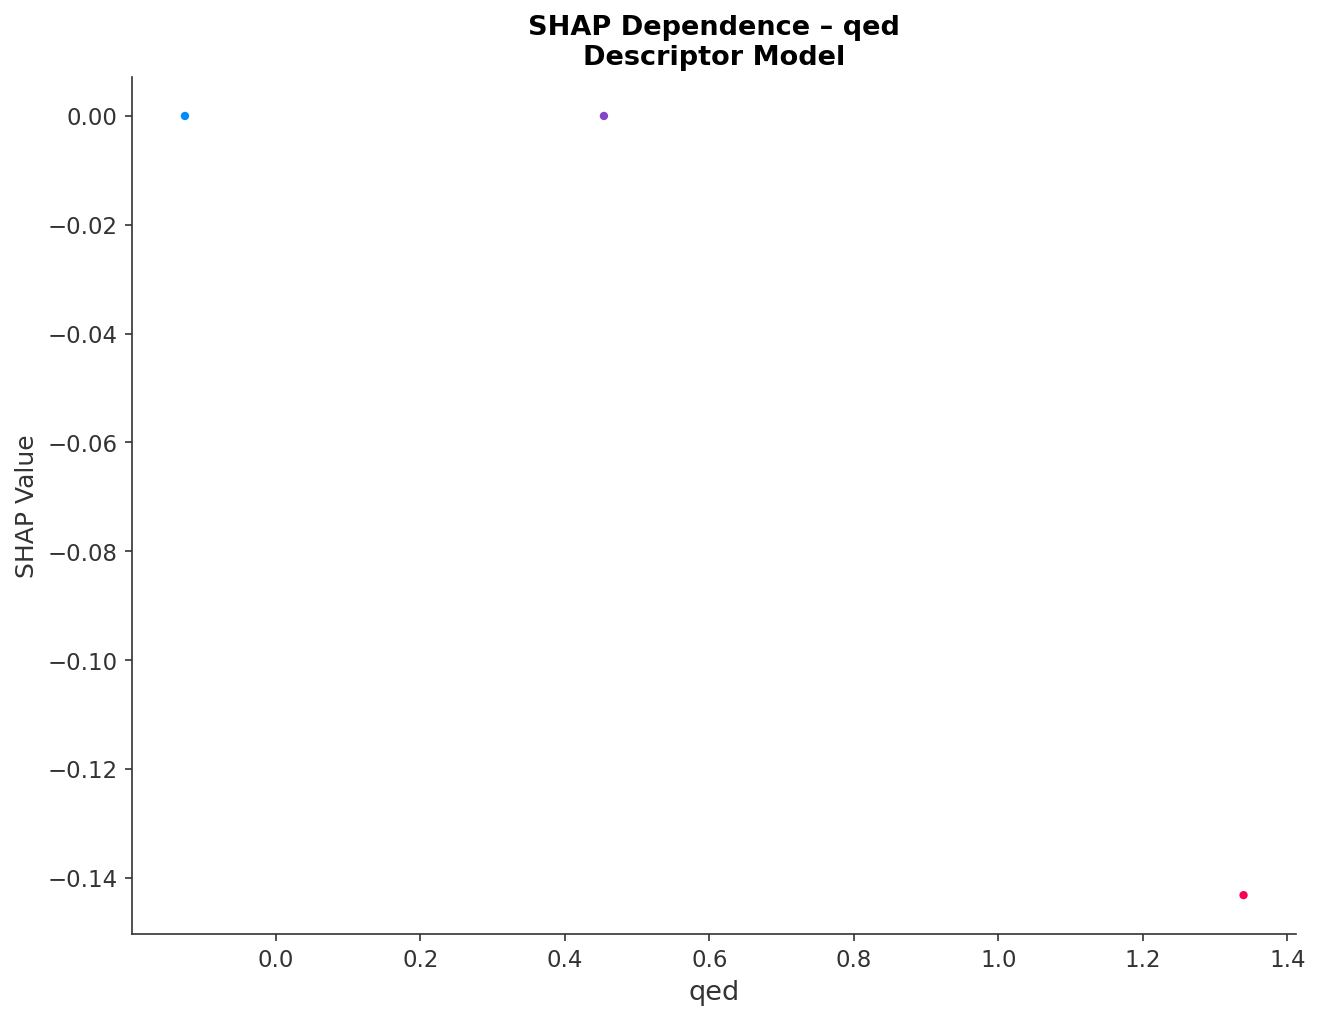

    Saved: /content/drive/MyDrive/models_new/shap_desc_ext_dependence.png


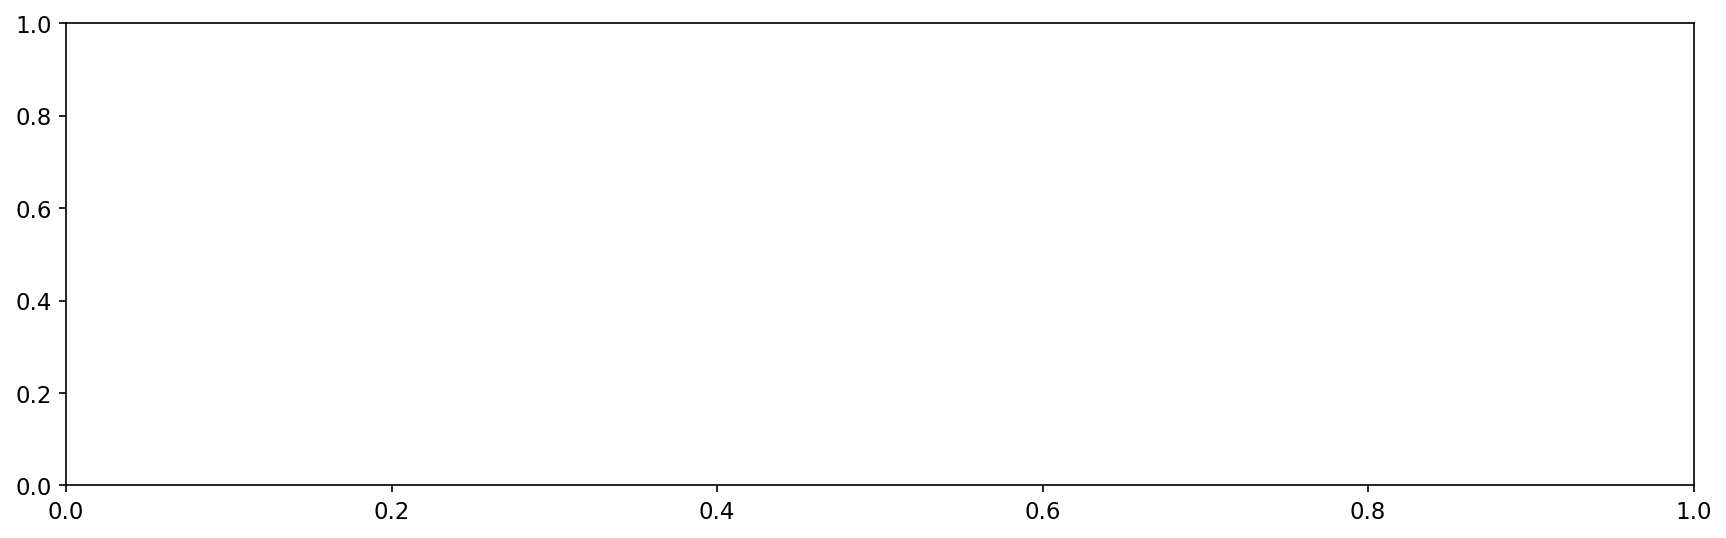

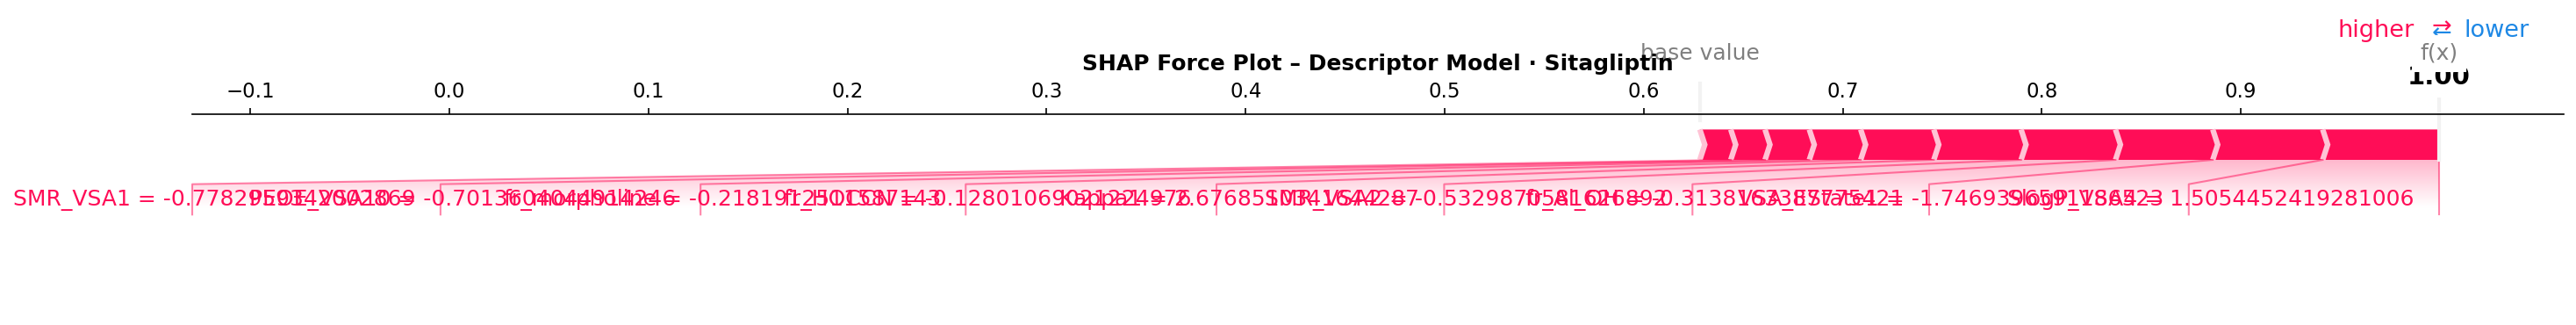

    Saved: /content/drive/MyDrive/models_new/shap_desc_ext_force.png
    Top features saved to: /content/drive/MyDrive/models_new/shap_desc_ext_importance.csv
             Feature  Mean_Abs_SHAP
                 qed       0.047737
         EState_VSA3       0.041022
              Kappa1       0.032082
         EState_VSA9       0.029953
           LabuteASA       0.028236
         VSA_EState3       0.025967
          SlogP_VSA4       0.022707
                 Ipc       0.022705
NumAtomStereoCenters       0.020630
         VSA_EState1       0.018410

[6/6] Fingerprint SHAP  (nsamples=100, n_class1_mols=3) …


  0%|          | 0/3 [00:00<?, ?it/s]

  Fingerprint Model: 27 active features / 2048


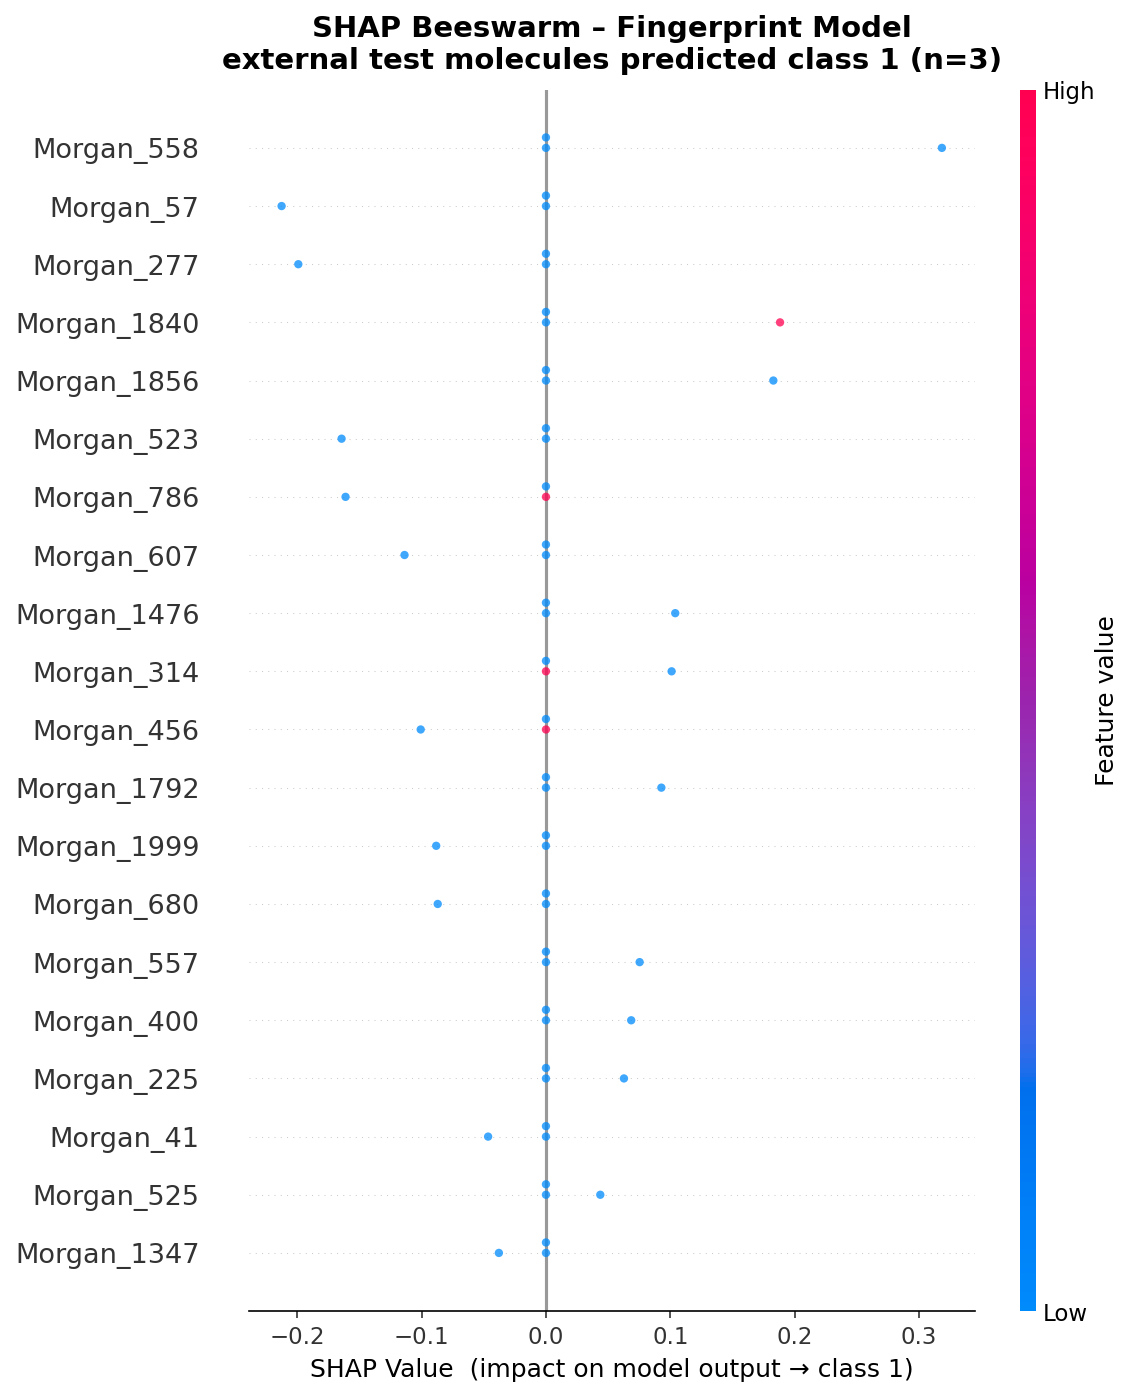

    Saved: /content/drive/MyDrive/models_new/shap_fp_ext_beeswarm.png


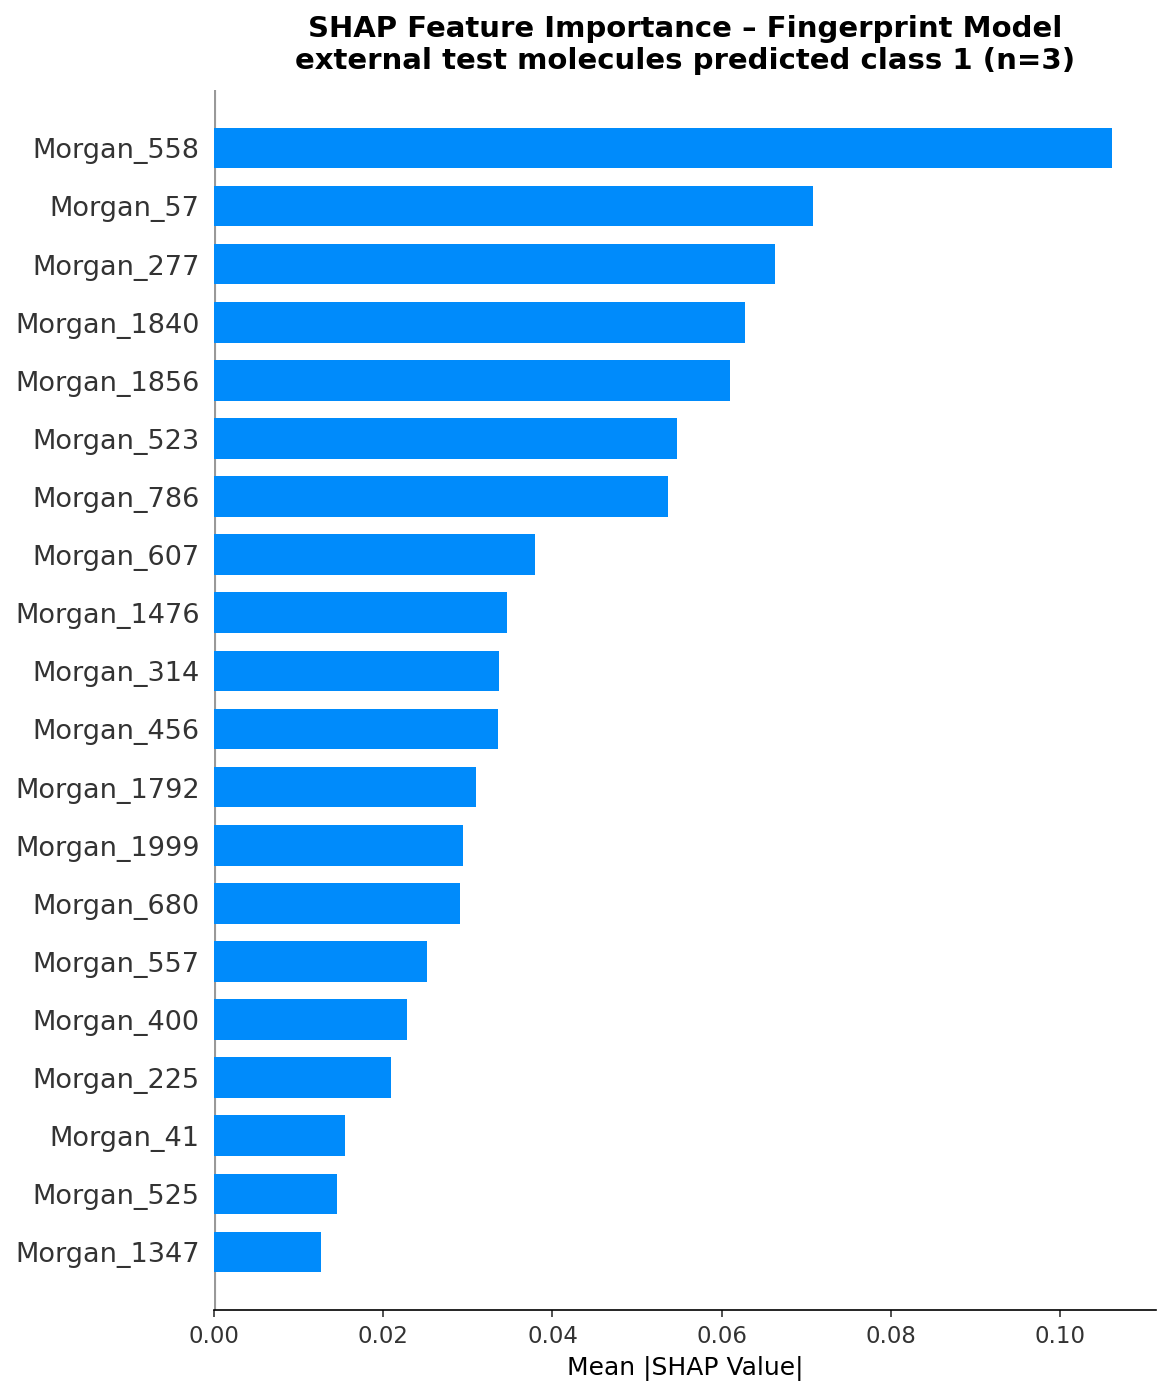

    Saved: /content/drive/MyDrive/models_new/shap_fp_ext_bar.png


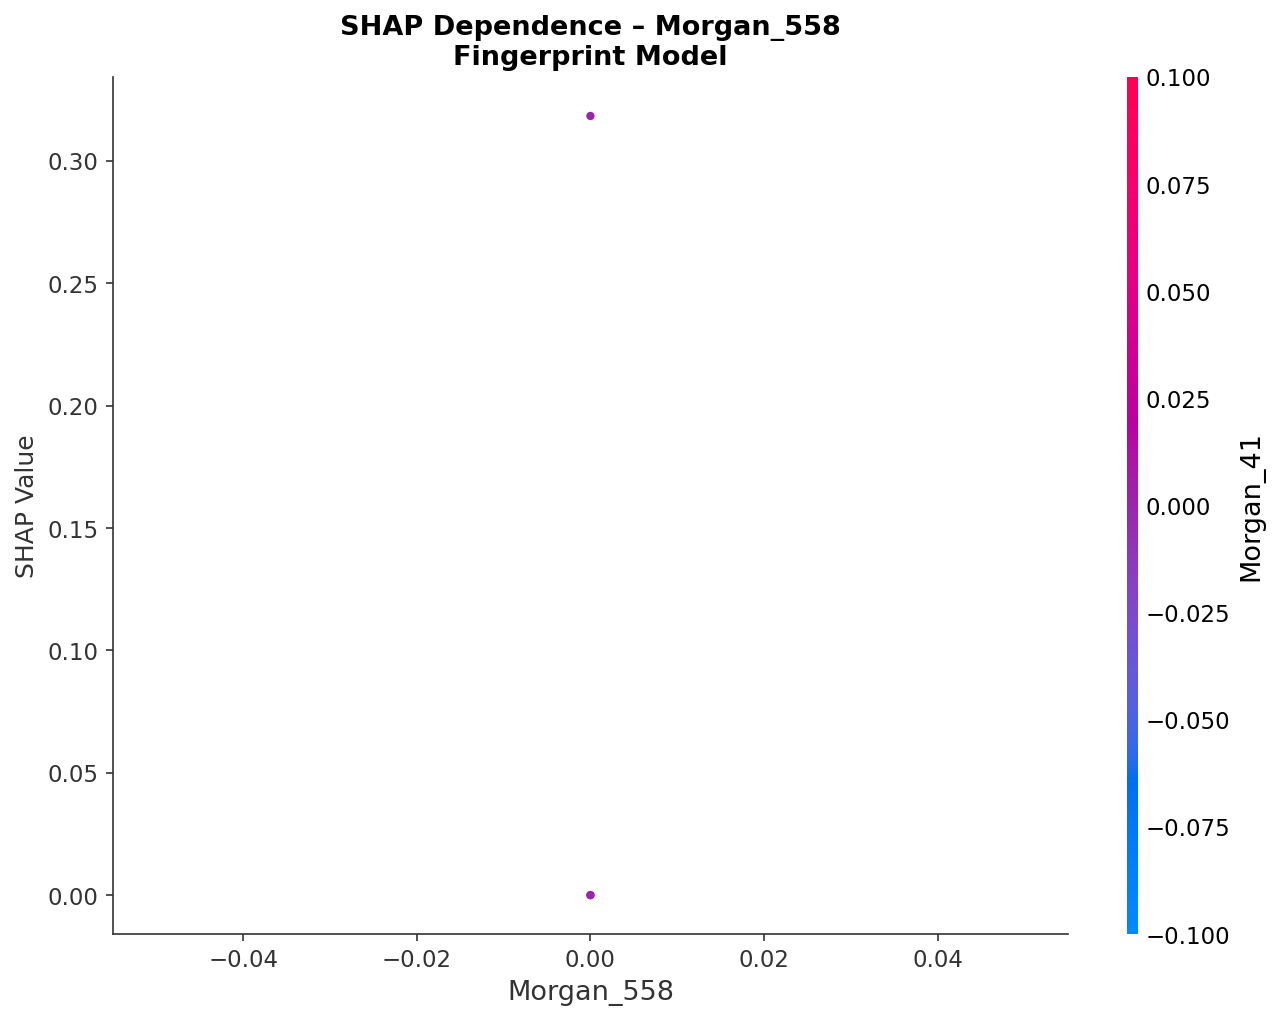

    Saved: /content/drive/MyDrive/models_new/shap_fp_ext_dependence.png


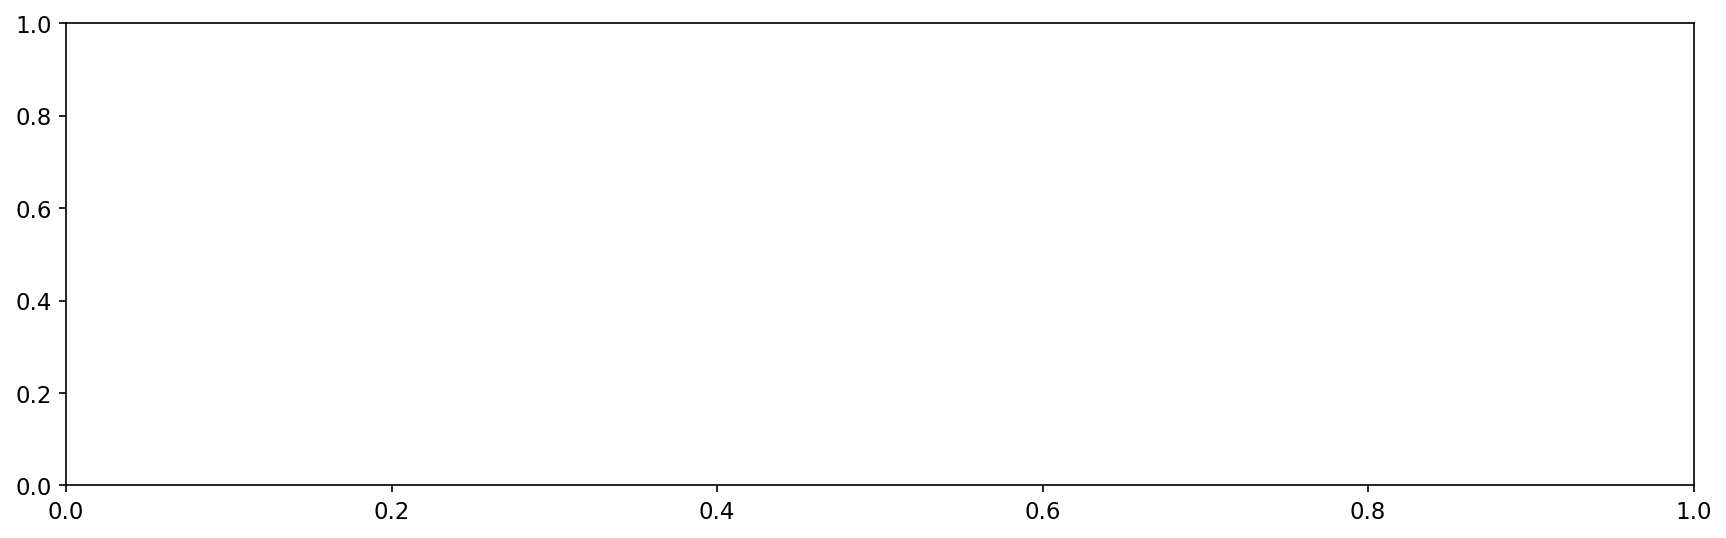

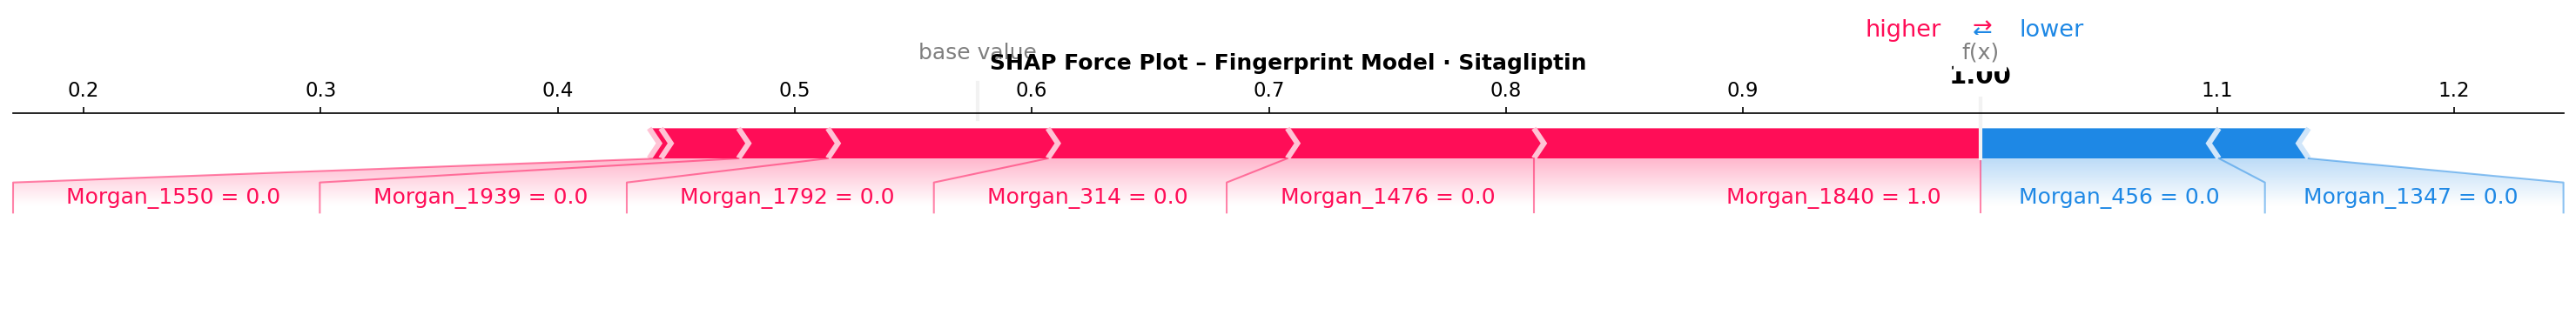

    Saved: /content/drive/MyDrive/models_new/shap_fp_ext_force.png
    Top features saved to: /content/drive/MyDrive/models_new/shap_fp_ext_importance.csv
    Feature  Mean_Abs_SHAP
 Morgan_558       0.106129
  Morgan_57       0.070858
 Morgan_277       0.066375
Morgan_1840       0.062745
Morgan_1856       0.060951
 Morgan_523       0.054779
 Morgan_786       0.053718
 Morgan_607       0.037910
Morgan_1476       0.034654
 Morgan_314       0.033682

Generating combined desc + fp importance overview …


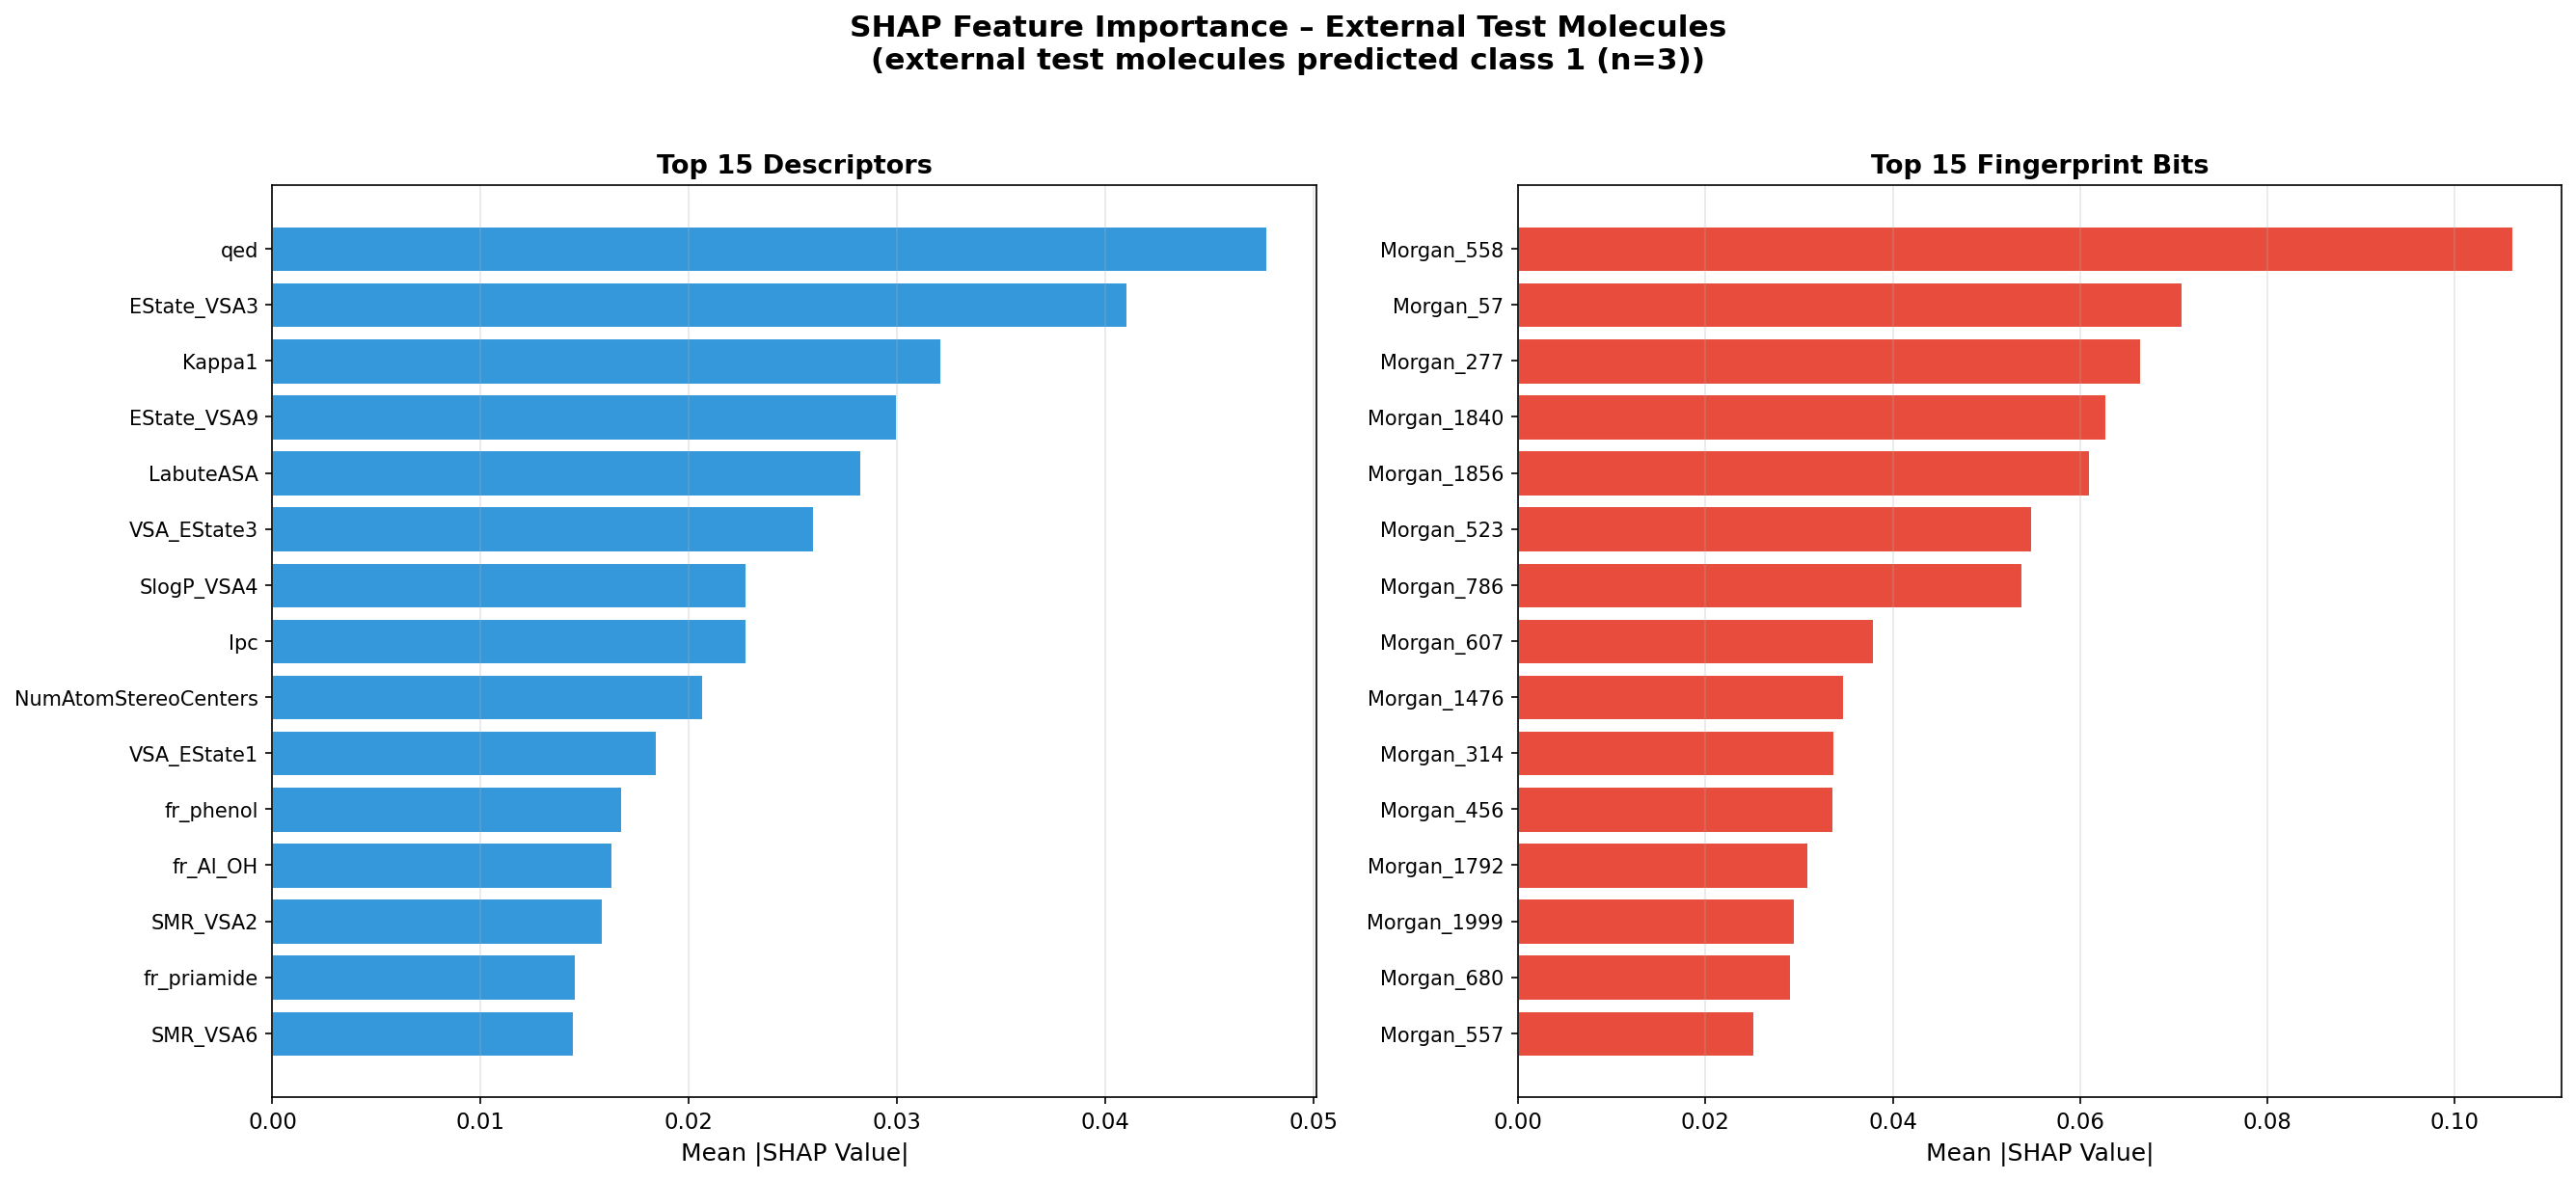

Saved: /content/drive/MyDrive/models_new/shap_ext_combined_overview.png

SECTION 11 COMPLETE – External test molecule SHAP plots saved.
  SHAP computed on 3 class-1 predicted molecules: ['Sitagliptin', 'Leucettinib-92', 'Silmitasertib']


In [ ]:
# ================================================================
# 11. SHAP ANALYSIS – EXTERNAL TEST MOLECULES
# ================================================================
import os, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import shap
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors
from rdkit.ML.Descriptors import MoleculeDescriptors

matplotlib.rcParams.update({
    'font.size': 13, 'axes.titlesize': 15, 'axes.labelsize': 13,
    'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'font.family': 'DejaVu Sans', 'figure.dpi': 150,
})
warnings.filterwarnings('ignore')

SHAP_NSAMPLES = 100
MAX_DISPLAY   = 20

np.random.seed(42)
print("\n" + "="*70)
print("SHAP – EXTERNAL TEST MOLECULES  (Hardcoded)")
print("="*70)

TEST_MOLECULES = {
    'Compound_name': [
        'Imatinib', 'Neratinib', 'Sitagliptin', 'Sunitinib',
        'Leucettinib-92', 'Silmitasertib'
    ],
    'ChEMBL_ID': [
        'CHEMBL941', 'CHEMBL180022', 'CHEMBL1422', 'CHEMBL535',
        'CHEMBL5091238', 'CHEMBL1230165'
    ],
    'Smiles': [
        'Cc1ccc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)cc1Nc1nccc(-c2cccnc2)n1',
        'CCOc1cc2ncc(C#N)c(Nc3ccc(OCc4ccccn4)c(Cl)c3)c2cc1NC(=O)/C=C/CN(C)C',
        'N[C@@H](CC(=O)N1CCn2c(nnc2C(F)(F)F)C1)Cc1cc(F)c(F)cc1F',
        'CCN(CC)CCNC(=O)c1c(C)[nH]c(/C=C2\\C(=O)Nc3ccc(F)cc32)c1C',
        r'O=C1NC(NC23CC4CC(CC(C4)C2)C3)=N/C1=C\c1ccc2ncsc2c1',
        'O=C(O)c1ccc2c(c1)nc(Nc1cccc(Cl)c1)c1ccncc12'
    ]
}

print("\n[1/6] Computing RDKit descriptors and Morgan fingerprints …")

desc_names = list(desc_feat_cols)
calc = MoleculeDescriptors.MolecularDescriptorCalculator(desc_names)

from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

fp_nbits   = len(fp_feat_cols)
fp_radius  = 2
morgan_gen = GetMorganGenerator(radius=fp_radius, fpSize=fp_nbits)

rows_desc, rows_fp, valid_names, valid_smiles = [], [], [], []

for name, smi in zip(TEST_MOLECULES['Compound_name'], TEST_MOLECULES['Smiles']):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        print(f"  ✗ {name}: invalid SMILES – skipped")
        continue
    try:
        desc_vals = np.array(calc.CalcDescriptors(mol), dtype=np.float64)
        fp_vals   = morgan_gen.GetFingerprintAsNumPy(mol).astype(np.float64)
        rows_desc.append(desc_vals)
        rows_fp.append(fp_vals)
        valid_names.append(name)
        valid_smiles.append(smi)
        print(f"  ✓ {name}")
    except Exception as e:
        print(f"  ✗ {name}: descriptor/FP error – {e}")

if len(rows_desc) == 0:
    raise RuntimeError("No valid molecules could be processed.")

X_ext_desc_raw = np.vstack(rows_desc)
X_ext_fp_raw   = np.vstack(rows_fp)

X_ext_desc_raw = np.nan_to_num(X_ext_desc_raw, nan=0.0, posinf=0.0, neginf=0.0)

print(f"\n  Processed {len(valid_names)} molecules | "
      f"desc shape: {X_ext_desc_raw.shape} | fp shape: {X_ext_fp_raw.shape}")

print("\n[2/6] Preprocessing with fold-0 scalers …")
p0              = preprocessing_params[0]
d_lo_0, d_hi_0 = p0['desc_clips']
f_lo_0, f_hi_0 = p0['fp_clips']
scaler_d0       = p0['scaler_desc']
scaler_f0       = p0['scaler_fp']

X_ext_desc_sc = scaler_d0.transform(
    np.clip(X_ext_desc_raw, d_lo_0, d_hi_0)).astype(np.float32)
X_ext_fp_sc   = scaler_f0.transform(
    np.clip(X_ext_fp_raw,   f_lo_0, f_hi_0)).astype(np.float32)

print("\n[3/6] Generating ensemble predictions …")
prob_ext_desc = ensemble_predict(best_models['desc'],
                                 X_ext_desc_raw, X_ext_fp_raw,
                                 preprocessing_params, 'desc',
                                 weights=np.maximum(fold_aucs['desc'], 0.5))
prob_ext_fp   = ensemble_predict(best_models['fp'],
                                 X_ext_desc_raw, X_ext_fp_raw,
                                 preprocessing_params, 'fp',
                                 weights=np.maximum(fold_aucs['fp'], 0.5))
prob_ext_comb = ensemble_predict(best_models['comb'],
                                 X_ext_desc_raw, X_ext_fp_raw,
                                 preprocessing_params, 'comb',
                                 weights=np.maximum(fold_aucs['comb'], 0.5))

pred_ext_desc = (prob_ext_desc > 0.5).astype(int)
pred_ext_fp   = (prob_ext_fp   > 0.5).astype(int)
pred_ext_comb = (prob_ext_comb > 0.5).astype(int)

pred_summary = pd.DataFrame({
    'Molecule'  : valid_names,
    'Desc_Prob' : np.round(prob_ext_desc, 4),
    'Desc_Pred' : pred_ext_desc,
    'FP_Prob'   : np.round(prob_ext_fp,   4),
    'FP_Pred'   : pred_ext_fp,
    'Comb_Prob' : np.round(prob_ext_comb, 4),
    'Comb_Pred' : pred_ext_comb,
})
print(pred_summary.to_string(index=False))
pred_summary.to_csv(os.path.join(SAVE_DIR, 'ext_test_predictions.csv'), index=False)

active_mask  = pred_ext_comb == 1
n_active     = active_mask.sum()
filter_desc  = f"external test molecules predicted class 1 (n={n_active})"

print(f"\n  Class-1 predictions: {n_active} / {len(valid_names)} molecules")

if n_active == 0:
    raise RuntimeError(
        "No molecules were predicted as class 1 by the combined model. "
        "Nothing to explain – exiting SHAP section."
    )

X_shap_desc      = X_ext_desc_sc[active_mask]
X_shap_fp        = X_ext_fp_sc[active_mask]
valid_names_shap = [n for n, m in zip(valid_names, active_mask) if m]

print(f"  Retained for SHAP: {valid_names_shap}")

print("\n[4/6] Building KernelExplainers with fold-0 background …")

Xd_bg_mean = scaler_d0.transform(
    np.clip(X_desc_trainval[:1000], d_lo_0, d_hi_0)).astype(np.float32).mean(axis=0, keepdims=True)
Xf_bg_mean = scaler_f0.transform(
    np.clip(X_fp_trainval[:1000],   f_lo_0, f_hi_0)).astype(np.float32).mean(axis=0, keepdims=True)

m_desc_ext = best_models['desc'][0]
m_fp_ext   = best_models['fp'][0]

explainer_desc_ext = shap.KernelExplainer(
    lambda x: m_desc_ext.predict(x, verbose=0).ravel(), Xd_bg_mean)
explainer_fp_ext   = shap.KernelExplainer(
    lambda x: m_fp_ext.predict(x, verbose=0).ravel(),   Xf_bg_mean)

def _filter_active(shap_vals, X_data, names):
    mask = np.abs(shap_vals).max(axis=0) > 1e-8
    return shap_vals[:, mask], X_data[:, mask], [names[i] for i, m in enumerate(mask) if m]


def _shap_suite(shap_vals, X_data, feat_names, model_label, save_prefix, ev,
                mol_names):
    sv, X_act, names = _filter_active(shap_vals, X_data, feat_names)
    print(f"  {model_label}: {sv.shape[1]} active features / {shap_vals.shape[1]}")
    mean_abs = np.abs(sv).mean(axis=0)

    #Beeswarm
    fig, _ = plt.subplots(figsize=(12, 9))
    shap.summary_plot(sv, X_act, feature_names=names,
                      max_display=MAX_DISPLAY, show=False, alpha=0.75)
    plt.gca().set_title(
        f"SHAP Beeswarm – {model_label}\n{filter_desc}",
        fontsize=14, fontweight='bold', pad=10)
    plt.gca().set_xlabel(
        "SHAP Value  (impact on model output → class 1)", fontsize=12)
    plt.tight_layout()
    fname = os.path.join(SAVE_DIR, f"{save_prefix}_ext_beeswarm.png")
    plt.savefig(fname, dpi=300, bbox_inches='tight'); plt.show()
    print(f"    Saved: {fname}")

    #Bar (mean |SHAP|)
    fig, _ = plt.subplots(figsize=(12, 9))
    shap.summary_plot(sv, X_act, feature_names=names, plot_type='bar',
                      max_display=MAX_DISPLAY, show=False)
    plt.gca().set_title(
        f"SHAP Feature Importance – {model_label}\n{filter_desc}",
        fontsize=14, fontweight='bold', pad=10)
    plt.gca().set_xlabel("Mean |SHAP Value|", fontsize=12)
    plt.tight_layout()
    fname = os.path.join(SAVE_DIR, f"{save_prefix}_ext_bar.png")
    plt.savefig(fname, dpi=300, bbox_inches='tight'); plt.show()
    print(f"    Saved: {fname}")

    #Dependence plot (top feature)
    top_idx = int(np.argmax(mean_abs))
    fig, ax = plt.subplots(figsize=(9, 7))
    shap.dependence_plot(top_idx, sv, X_act, feature_names=names,
                         show=False, ax=ax)
    ax.set_title(
        f"SHAP Dependence – {names[top_idx]}\n{model_label}",
        fontsize=13, fontweight='bold')
    ax.set_ylabel("SHAP Value", fontsize=12)
    plt.tight_layout()
    fname = os.path.join(SAVE_DIR, f"{save_prefix}_ext_dependence.png")
    plt.savefig(fname, dpi=300, bbox_inches='tight'); plt.show()
    print(f"    Saved: {fname}")

    #Force plot (first class-1 molecule)
    mol_label = mol_names[0]
    fig, _ = plt.subplots(figsize=(14, 4))
    shap.force_plot(ev, sv[0], X_act[0], feature_names=names,
                    matplotlib=True, show=False)
    plt.title(
        f"SHAP Force Plot – {model_label} · {mol_label}",
        fontsize=12, fontweight='bold')
    plt.tight_layout()
    fname = os.path.join(SAVE_DIR, f"{save_prefix}_ext_force.png")
    plt.savefig(fname, dpi=300, bbox_inches='tight'); plt.show()
    print(f"    Saved: {fname}")

    #Importance CSV
    imp_df = (pd.DataFrame({'Feature': names, 'Mean_Abs_SHAP': mean_abs})
                .sort_values('Mean_Abs_SHAP', ascending=False))
    csv_path = os.path.join(SAVE_DIR, f"{save_prefix}_ext_importance.csv")
    imp_df.to_csv(csv_path, index=False)
    print(f"    Top features saved to: {csv_path}")
    print(imp_df.head(10).to_string(index=False))

    return sv, X_act, names, mean_abs

print(f"\n[5/6] Descriptor SHAP  "
      f"(nsamples={SHAP_NSAMPLES}, n_class1_mols={n_active}) …")
shap_vals_desc_ext = explainer_desc_ext.shap_values(
    X_shap_desc, nsamples=SHAP_NSAMPLES)
sv_desc_ext, X_desc_act, names_desc_ext, mean_desc_ext = _shap_suite(
    shap_vals_desc_ext, X_shap_desc,
    feat_names=list(desc_feat_cols),
    model_label="Descriptor Model",
    save_prefix="shap_desc",
    ev=explainer_desc_ext.expected_value,
    mol_names=valid_names_shap)

print(f"\n[6/6] Fingerprint SHAP  "
      f"(nsamples={SHAP_NSAMPLES}, n_class1_mols={n_active}) …")
shap_vals_fp_ext = explainer_fp_ext.shap_values(
    X_shap_fp, nsamples=SHAP_NSAMPLES)
sv_fp_ext, X_fp_act, names_fp_ext, mean_fp_ext = _shap_suite(
    shap_vals_fp_ext, X_shap_fp,
    feat_names=[f'Morgan_{i}' for i in range(len(fp_feat_cols))],
    model_label="Fingerprint Model",
    save_prefix="shap_fp",
    ev=explainer_fp_ext.expected_value,
    mol_names=valid_names_shap)

print("\nGenerating combined desc + fp importance overview …")
top_k = 15
top_desc_idx = np.argsort(mean_desc_ext)[::-1][:top_k]
top_fp_idx   = np.argsort(mean_fp_ext)[::-1][:top_k]

fig, (ax_d, ax_f) = plt.subplots(1, 2, figsize=(18, 8))

ax_d.barh(range(top_k), mean_desc_ext[top_desc_idx][::-1],
          color='#3498db', edgecolor='white', lw=0.5)
ax_d.set_yticks(range(top_k))
ax_d.set_yticklabels([names_desc_ext[i] for i in top_desc_idx[::-1]], fontsize=10)
ax_d.set_xlabel("Mean |SHAP Value|", fontsize=12)
ax_d.set_title(f"Top {top_k} Descriptors", fontsize=13, fontweight='bold')
ax_d.grid(axis='x', alpha=0.3)

ax_f.barh(range(top_k), mean_fp_ext[top_fp_idx][::-1],
          color='#e74c3c', edgecolor='white', lw=0.5)
ax_f.set_yticks(range(top_k))
ax_f.set_yticklabels([names_fp_ext[i] for i in top_fp_idx[::-1]], fontsize=10)
ax_f.set_xlabel("Mean |SHAP Value|", fontsize=12)
ax_f.set_title(f"Top {top_k} Fingerprint Bits", fontsize=13, fontweight='bold')
ax_f.grid(axis='x', alpha=0.3)

plt.suptitle(
    f"SHAP Feature Importance – External Test Molecules\n({filter_desc})",
    fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
fname = os.path.join(SAVE_DIR, 'shap_ext_combined_overview.png')
plt.savefig(fname, dpi=300, bbox_inches='tight'); plt.show()
print(f"Saved: {fname}")

print("\n" + "="*70)
print("SECTION 11 COMPLETE – External test molecule SHAP plots saved.")
print(f"  SHAP computed on {n_active} class-1 predicted molecules: {valid_names_shap}")
print("="*70)
